# Task 2 Hybrid Spike Localization Model

This notebook predicts spike probability over electrode/time bins. Pattern labels are random stimulation-pattern IDs and are used only as categorical conditioning/baseline keys; they are **not** treated as adjacent classes on a pattern circle.

Final training is configured for the shared final dataset `N5_DIV40.h5` with `group_data=False` and `test_mode=False`. The corresponding `_test` file is loaded only as a separate inference/submission reference because the final-task Task 2 test file provides stimulation parameters but not supervised spike responses.

The final Task 2 ranking uses normalized 1 ms PSTH timing per electrode and pattern-frequency pair, scored with Wasserstein-1 distance. The active model therefore keeps BCE calibration but also tracks and regularizes temporal-distribution quality.

The excitatory-loop information is handled as an electrode topology/response prior only. The active default uses a gated hybrid graph: physical kNN is the anchor, while soft loop-contour and train-split response-correlation relations are added with learnable gates so topology can help without overriding local geometry.

Current active variant: `task2_hybrid_gated_topology`, with categorical pattern-baseline anchoring, pattern-specific residual gating, hybrid topology relations, hard-zero bins 0-5, PSTH/W1 diagnostics, and early stopping on the validation temporal-W1 proxy.


**W1-centered validation diagnostics.** Final Task 2 scoring is driven by normalized 1 ms PSTH Wasserstein distance, so this notebook now reports W1 as the primary model-selection and interpretation metric. After training, it can also fit a validation-only model/pattern-baseline blend by pattern-frequency condition, then writes ranked condition-level W1 tables and heatmaps to show exactly where the model helps or hurts.


In [1]:
# ===== notebook cell 2 =====
# ============================================================
# 1. Imports
# ============================================================
import os
import sys

PROJECT_ROOT = "/home/bnn_10fs26/pands_ibnnwml/Final_Task"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.data import load_data, save_data
try:
    from utils.plotting import map_colour_to_electrode
except Exception as e:
    map_colour_to_electrode = None
    print("WARNING: could not import map_colour_to_electrode:", repr(e))

try:
    from IPython.display import display
except Exception:
    display = print

import os, json, math, time, random, getpass, warnings, copy
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from queue import Queue
import threading
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
# ===== notebook cell 3 =====
# ============================================================
# Checkpoint compatibility helper
# ============================================================
def torch_load_checkpoint(path, map_location=None):
    """Load PyTorch checkpoints across versions.

    Newer PyTorch versions may default to weights_only=True, which can fail
    for our checkpoints because they store numpy arrays/config dictionaries.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print("Checkpoint loader ready.")


Checkpoint loader ready.


In [3]:
import time
import shutil
# ===== notebook cell 4 =====
# ============================================================
# 2. Configuration: loop-aware hybrid spike-localization model
# ============================================================
Network = 5
DIV = 40
group_data = False
TRAIN_TEST_MODE = False  # supervised training file: shared/N5_DIV40.h5
LOAD_FINAL_TEST_DATA = True
FINAL_TEST_MODE = True   # inference/submission file: shared/N5_DIV40_test.h5

# Split options: "random", "leave_frequency_out", "leave_pattern_out", "blocked_time".
# RANDOM_SEED=None draws a fresh random validation split each run.
SPLIT_MODE = "random"
VAL_FRAC = 0.25
RANDOM_SEED = 42

# Stop if physical coordinates cannot be recovered. The graph branch needs real coords.
REQUIRE_PHYSICAL_COORDS = True

# Single model, two GPUs when available. GPU availability is based on recent
# utilization plus a free-memory headroom check. Utilization catches active
# training; free memory prevents low-util paused/idle CUDA processes from
# causing immediate OOM.
USE_DATA_PARALLEL = True
REQUESTED_NUM_GPUS = 2
GPU_UTIL_FREE_THRESHOLD_PERCENT = 1
GPU_MIN_FREE_MEMORY_MIB = 6500
GPU_UTIL_SAMPLES = 5
GPU_UTIL_SAMPLE_INTERVAL_SEC = 1.0
FALLBACK_ALLOW_ANY_VISIBLE_GPU_IF_NVIDIA_SMI_FAILS = False


def query_visible_gpu_status_once():
    if not torch.cuda.is_available():
        return []
    n_visible = torch.cuda.device_count()
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=index,memory.used,memory.free,memory.total,utilization.gpu",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        rows = []
        for line in result.stdout.strip().splitlines():
            if not line.strip():
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 5:
                continue
            idx, mem_used, mem_free, mem_total, util = map(int, parts[:5])
            if idx < n_visible:
                rows.append(dict(index=idx, memory_used_mib=mem_used, memory_free_mib=mem_free, memory_total_mib=mem_total, util_percent=util))
        return rows
    except Exception as e:
        print("WARNING: could not query nvidia-smi for free GPU selection:", repr(e))
        if FALLBACK_ALLOW_ANY_VISIBLE_GPU_IF_NVIDIA_SMI_FAILS:
            return [dict(index=i, memory_used_mib=0, memory_free_mib=6500, memory_total_mib=0, util_percent=0) for i in range(n_visible)]
        return []


def query_visible_gpu_status():
    samples = []
    for sample_idx in range(int(GPU_UTIL_SAMPLES)):
        rows = query_visible_gpu_status_once()
        if rows:
            samples.append(rows)
        if sample_idx + 1 < int(GPU_UTIL_SAMPLES):
            time.sleep(float(GPU_UTIL_SAMPLE_INTERVAL_SEC))
    if not samples:
        return []

    by_idx = {}
    for rows in samples:
        for row in rows:
            idx = int(row["index"])
            rec = by_idx.setdefault(idx, dict(
                index=idx,
                memory_used_mib=int(row["memory_used_mib"]),
                memory_free_mib=int(row["memory_free_mib"]),
                memory_total_mib=int(row["memory_total_mib"]),
                util_samples=[],
            ))
            rec["memory_used_mib"] = int(row["memory_used_mib"])
            rec["memory_free_mib"] = int(row["memory_free_mib"])
            rec["memory_total_mib"] = int(row["memory_total_mib"])
            rec["util_samples"].append(int(row["util_percent"]))
    out = []
    for rec in sorted(by_idx.values(), key=lambda x: x["index"]):
        utils = rec["util_samples"]
        rec["util_percent"] = int(utils[-1]) if utils else 0
        rec["util_max_percent"] = int(max(utils)) if utils else 0
        rec["util_mean_percent"] = float(np.mean(utils)) if utils else 0.0
        out.append(rec)
    return out


def select_free_gpus(required=REQUESTED_NUM_GPUS):
    status = query_visible_gpu_status()
    free = [
        g for g in status
        if g["util_max_percent"] <= GPU_UTIL_FREE_THRESHOLD_PERCENT
        and g["memory_free_mib"] >= GPU_MIN_FREE_MEMORY_MIB
    ]
    print("Visible GPU status from utilization samples:")
    for g in status:
        tag = "free" if g in free else ("low-util-but-memory-full" if g["util_max_percent"] <= GPU_UTIL_FREE_THRESHOLD_PERCENT else "busy")
        print(
            f" - GPU {g['index']}: util_samples={g['util_samples']}, "
            f"max_util={g['util_max_percent']}%, "
            f"free_mem={g['memory_free_mib']}/{g['memory_total_mib']} MiB, "
            f"used_mem={g['memory_used_mib']} MiB -> {tag}"
        )
    if torch.cuda.is_available() and len(free) < int(required):
        raise RuntimeError(
            f"Need {required} GPUs with max utilization <= {GPU_UTIL_FREE_THRESHOLD_PERCENT}% "
            f"and at least {GPU_MIN_FREE_MEMORY_MIB} MiB free memory, but found {len(free)}. "
            "Wait for active/idle CUDA jobs to finish or lower REQUESTED_NUM_GPUS."
        )
    return [int(g["index"]) for g in free[:int(required)]]


DATA_PARALLEL_DEVICE_IDS = select_free_gpus(REQUESTED_NUM_GPUS) if torch.cuda.is_available() else []
PRIMARY_CUDA_DEVICE = DATA_PARALLEL_DEVICE_IDS[0] if DATA_PARALLEL_DEVICE_IDS else 0
PARALLEL_MODEL_TRAINING = False
REQUESTED_GPU_IDS = DATA_PARALLEL_DEVICE_IDS[:]
AVAILABLE_GPU_IDS = DATA_PARALLEL_DEVICE_IDS[:]
MAX_PARALLEL_MODELS = 1
BATCH_SIZE = 1024

N_EPOCHS = 180
PATIENCE = 10  # validation checks, not raw epochs
SCHEDULER_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 2e-5
CHECKPOINT_SELECTION_METRIC = "final_w1_proxy_weighted_w1_ms"
PRIMARY_TASK2_METRIC_NAME = "weighted_w1_ms"
# Final testing is W1-centered. The trained model remains the main predictor, but validation can
# choose a conservative model/pattern-baseline blend for pattern-frequency cells where the baseline is safer.
ENABLE_W1_VALIDATION_BLEND = True
W1_BLEND_GROUP = "pattern_frequency"
W1_BLEND_ALPHA_GRID = [i / 20 for i in range(21)]  # alpha=1.0 model, alpha=0.0 pattern baseline
W1_BLEND_MIN_TRIALS = 12
W1_BLEND_ELECTRODE_LEVEL = True
W1_BLEND_ELECTRODE_MIN_TRUE_MASS = 1e-6
VAL_EVERY = 2
LEARNING_RATE = 8e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
NUM_WORKERS = 0

# BCE remains the calibration anchor, but final Task 2 scoring is normalized 1 ms PSTH Wasserstein distance.
# Count/PSTH auxiliaries stay light; temporal-W1 now warms up so later epochs optimize timing more directly.
AUX_COUNT_WEIGHT = 0.03
AUX_PSTH_WEIGHT = 0.03
AUX_TEMPORAL_KL_WEIGHT = 0.0
AUX_SPATIAL_KL_WEIGHT = 0.0
AUX_EARLY_TEMPORAL_KL_WEIGHT = 0.0
AUX_FIRST_TIME_WEIGHT = 0.0
AUX_TEMPORAL_W1_WEIGHT = 0.12
USE_TEMPORAL_W1_WEIGHT_SCHEDULE = True
TEMPORAL_W1_WEIGHT_SCHEDULE = [(1, 0.04), (21, 0.08), (61, 0.12)]
VALIDATION_FINAL_W1_BINS_PER_MS = 4
AUX_JOINT_KL_WEIGHT = 0.0
AUX_FOCAL_WEIGHT = 0.0
AUX_RANKING_WEIGHT = 0.0
EARLY_TIME_WINDOW = (0, 20)

# Evaluation showed bins 0-5 are globally silent in the available data.
# Masking them prevents the model from wasting spike mass in impossible time bins.
HARD_ZERO_TIME_BINS = [0, 1, 2, 3, 4, 5]
HARD_ZERO_LOGIT = -20.0
FOCAL_ALPHA = 0.80
FOCAL_GAMMA = 2.0
RANK_NEG_K = 256
RANK_MARGIN = 0.60

# Best history configuration from the completed grid search.
Z_HISTORY_LEN = 24
MAX_Z_HISTORY_LEN = Z_HISTORY_LEN
Z_GRU_HIDDEN_DIM = 64
Z_GRU_LAYERS = 2

# Active default: pattern IDs are categorical stimulation IDs, not ordered classes.
# Topology is used on electrode/output structure only. kNN stays as the anchor,
# while soft loop-contour and response-correlation relations are gated and learned.
BEST_VARIANT_NAME = "task2_hybrid_gated_topology"
BASE_MODEL_CONFIG = dict(
    pattern_emb_dim=32,
    bit_emb_dim=16,
    freq_rbf_dim=16,
    cond_dim=96,
    electrode_emb_dim=24,
    hidden_dim=96,
    k_modes=80,
    n_graph_layers=2,
    graph_k=8,
    loop_graph_k=3,
    response_graph_k=8,
    use_circular_electrode_features=True,
    use_ring_graph_relations=False,
    use_hybrid_topology_relations=True,
    use_response_graph_relation=True,
    use_learned_relation_gates=True,
    relation_gate_init={"knn": 0.95, "soft_loop": 0.30, "response_corr": 0.35, "self": 0.80},
    dropout=0.12,
    pattern_baseline_alpha=25.0,
    pattern_frequency_baseline_alpha=5.0,

    baseline_mode="pattern_frequency",
    use_pattern_residual_gate=True,
    pattern_residual_gate_min=0.05,
    pattern_residual_gate_init_max=0.95,
    use_frequency_features=True,
    use_rbf_features=True,
    use_frequency_film=False,

    use_prev_z_context=True,
    use_pattern_embedding=True,
    use_bit_features=True,
    current_bit_feature_mode="single",
    current_bit_encoder="linear",
    use_prev_pattern_context=True,
    use_prev_pattern_bit_context=False,
    use_cont_context=True,
    use_coordinates=True,
    use_electrode_embedding=True,
    use_electrode_rate=True,
    use_graph=True,
    use_temporal_basis=True,
    use_cond_time_bias=True,

    use_z_gru_state=True,
    z_history_len=Z_HISTORY_LEN,
    z_gru_hidden_dim=Z_GRU_HIDDEN_DIM,
    z_gru_layers=Z_GRU_LAYERS,
    z_history_pattern_mode="embedding",

    deploy_context_mode="z_window_summary",
    aux_count_weight=AUX_COUNT_WEIGHT,
    aux_psth_weight=AUX_PSTH_WEIGHT,
    aux_temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    aux_spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    aux_early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    aux_first_time_weight=AUX_FIRST_TIME_WEIGHT,
    aux_temporal_w1_weight=AUX_TEMPORAL_W1_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
    weight_decay=WEIGHT_DECAY,
    context_dim=None,
)


def variant(name, group, question, description, changes=None, **meta):
    return dict(
        name=name,
        experiment_group=group,
        question=question,
        description=description,
        changes=changes or {},
        needs_base_predictions=False,
        **meta,
    )

VARIANTS = [
    variant(
        BEST_VARIANT_NAME,
        "hybrid_localization",
        "categorical_pattern_gated_hybrid_topology",
        "Exact output spike-localization model: pattern IDs are categorical conditioning/baseline keys, not adjacent class labels. Uses a smoothed pattern-frequency residual baseline plus gated hybrid electrode graph: physical kNN anchor, soft loop-contour, and train-split response-correlation relations, optimized with a W1/PSTH validation proxy matching the final Task 2 metric.",
        history_strategy="H24_D64_embedding_layers2_best_c4",
        freq_strategy="direct_rbf16_plus_full_z_window_context",
        topology_strategy="gated_knn_soft_loop_response_corr",
    )
]

RUN_NAME = f"{BEST_VARIANT_NAME}_N{Network}_DIV{DIV}_shared_final_{SPLIT_MODE}"
OUTPUT_ROOT = Path("task2_outputs") / "hybrid_spike_localization"
RUN_FAMILY_DIR = OUTPUT_ROOT / RUN_NAME
CURRENT_OUT_DIR = RUN_FAMILY_DIR / "current_run"
PREVIOUS_OUT_DIR = RUN_FAMILY_DIR / "previous_run"
BEST_OUT_DIR = RUN_FAMILY_DIR / "best_run"
OUT_DIR = CURRENT_OUT_DIR
RUN_FAMILY_DIR.mkdir(parents=True, exist_ok=True)


def _path_has_contents(path):
    path = Path(path)
    return path.exists() and any(path.iterdir())


def _remove_tree_if_exists(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)


def _rewrite_json_paths(obj, old_root, new_root):
    old_root = str(Path(old_root).resolve())
    new_root = str(Path(new_root).resolve())
    if isinstance(obj, str):
        return obj.replace(old_root, new_root)
    if isinstance(obj, list):
        return [_rewrite_json_paths(x, old_root, new_root) for x in obj]
    if isinstance(obj, dict):
        return {k: _rewrite_json_paths(v, old_root, new_root) for k, v in obj.items()}
    return obj


def rewrite_summary_paths_in_tree(tree_root, old_root, new_root):
    tree_root = Path(tree_root)
    for summary_path in tree_root.rglob("summary.json"):
        try:
            payload = json.loads(summary_path.read_text())
            payload = _rewrite_json_paths(payload, old_root, new_root)
            summary_path.write_text(json.dumps(payload, indent=2))
        except Exception as e:
            print("WARNING: could not rewrite paths in", summary_path, repr(e))


def prepare_task2_output_retention_for_training():
    """Keep only current, previous, and best snapshots for this Task 2 run family."""
    RUN_FAMILY_DIR.mkdir(parents=True, exist_ok=True)
    if _path_has_contents(CURRENT_OUT_DIR):
        _remove_tree_if_exists(PREVIOUS_OUT_DIR)
        shutil.move(str(CURRENT_OUT_DIR), str(PREVIOUS_OUT_DIR))
        rewrite_summary_paths_in_tree(PREVIOUS_OUT_DIR, CURRENT_OUT_DIR, PREVIOUS_OUT_DIR)
        print("Moved previous current run to:", PREVIOUS_OUT_DIR.resolve())
    CURRENT_OUT_DIR.mkdir(parents=True, exist_ok=True)
    for child in RUN_FAMILY_DIR.iterdir():
        if child.is_dir() and child.name not in {"current_run", "previous_run", "best_run"}:
            print("WARNING: unexpected output directory remains:", child.resolve())
    return CURRENT_OUT_DIR


def _retention_metric_from_summary(summary):
    value = summary.get("final_metric_proxy_weighted_w1_ms", np.nan)
    try:
        return float(value)
    except Exception:
        return np.nan


def update_task2_best_retention(summary):
    """Copy current_run to best_run if the current W1 metric is lower than the retained best."""
    current_metric = _retention_metric_from_summary(summary)
    best_summary_path = BEST_OUT_DIR / summary.get("variant", BEST_VARIANT_NAME) / "summary.json"
    best_metric = np.inf
    if best_summary_path.exists():
        try:
            best_metric = _retention_metric_from_summary(json.loads(best_summary_path.read_text()))
        except Exception as e:
            print("WARNING: could not read retained best summary:", repr(e))
    improved = np.isfinite(current_metric) and (not np.isfinite(best_metric) or current_metric < best_metric)
    if improved:
        _remove_tree_if_exists(BEST_OUT_DIR)
        shutil.copytree(CURRENT_OUT_DIR, BEST_OUT_DIR)
        rewrite_summary_paths_in_tree(BEST_OUT_DIR, CURRENT_OUT_DIR, BEST_OUT_DIR)
        print(f"Updated best_run: W1 {current_metric:.6f} beats previous best {best_metric:.6f}")
    else:
        print(f"Kept existing best_run: current W1 {current_metric:.6f}, best W1 {best_metric:.6f}")
    manifest = {
        "run_name": RUN_NAME,
        "metric": "final_metric_proxy_weighted_w1_ms",
        "lower_is_better": True,
        "current_run": str(CURRENT_OUT_DIR.resolve()),
        "previous_run": str(PREVIOUS_OUT_DIR.resolve()) if PREVIOUS_OUT_DIR.exists() else None,
        "best_run": str(BEST_OUT_DIR.resolve()) if BEST_OUT_DIR.exists() else None,
        "current_metric": current_metric,
        "best_metric": current_metric if improved else best_metric,
    }
    (RUN_FAMILY_DIR / "retention_manifest.json").write_text(json.dumps(manifest, indent=2))
    return manifest

if torch.cuda.is_available():
    device = torch.device(f"cuda:{PRIMARY_CUDA_DEVICE}")
else:
    device = torch.device("cpu")
DEVICE = device

print("Checkpoint loader ready.")
print("Default device:", device)
print("CUDA devices:", torch.cuda.device_count() if torch.cuda.is_available() else 0)
print("Selected data-parallel GPUs:", DATA_PARALLEL_DEVICE_IDS)
print("Max parallel model processes:", MAX_PARALLEL_MODELS)
print("Use DataParallel:", USE_DATA_PARALLEL and len(DATA_PARALLEL_DEVICE_IDS) >= 2)
print("Run family directory:", RUN_FAMILY_DIR.resolve())
print("Current output directory:", CURRENT_OUT_DIR.resolve())
print("Previous output directory:", PREVIOUS_OUT_DIR.resolve())
print("Best output directory:", BEST_OUT_DIR.resolve())
print("Active localization model:")
for v in VARIANTS:
    print(" -", v["name"], "|", v.get("experiment_group", ""), "|", v.get("question", ""))


Visible GPU status from utilization samples:
 - GPU 0: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 1: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 2: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 3: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
Checkpoint loader ready.
Default device: cuda:0
CUDA devices: 4
Selected data-parallel GPUs: [0, 1]
Max parallel model processes: 1
Use DataParallel: True
Run family directory: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random
Current output directory: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run
Previous output directory: /home/bnn_10fs26/pands_ibnn

In [4]:
# ===== notebook cell 5 =====
# ============================================================
# 3. Reproducibility and metrics helpers
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

if RANDOM_SEED is not None:
    seed_everything(RANDOM_SEED)


def clip_prob(p, eps=1e-5):
    return np.clip(p, eps, 1.0 - eps)


def np_logit(p, eps=1e-5):
    p = clip_prob(p, eps)
    return np.log(p / (1.0 - p))


def bce_from_prob_np(y, p):
    p = clip_prob(p)
    return float(-(y * np.log(p) + (1-y) * np.log(1-p)).mean())


def torch_bce_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets, reduction="mean")


def corr_safe(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if a.std() < 1e-12 or b.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


In [5]:
# ===== notebook cell 6 =====
# ============================================================
# 4. Load and standardize data
# ============================================================
def array_shape_or_none(x):
    return None if x is None else tuple(np.asarray(x).shape)

# Supervised training uses the shared final training file, not the `_test` file.
data = load_data(Network, DIV, group_data, test_mode=TRAIN_TEST_MODE)
stimulation_parameters, stimulation_patterns, binned_spike_train_responses, stimulation_times, impedance_map, electrodes = data
if stimulation_parameters is None or binned_spike_train_responses is None:
    raise ValueError(
        "Supervised Task 2 training requires stimulation parameters and spike responses. "
        "Use test_mode=False for the final shared training file."
    )

print("Raw training stimulation_parameters shape:", array_shape_or_none(stimulation_parameters))
print("Raw training stimulation_patterns shape:", array_shape_or_none(stimulation_patterns))
print("Raw training responses shape:", array_shape_or_none(binned_spike_train_responses))

final_task2_test_data = None
if LOAD_FINAL_TEST_DATA:
    try:
        final_task2_test_data = load_data(Network, DIV, group_data, test_mode=FINAL_TEST_MODE)
        test_stimulation_parameters, test_stimulation_patterns, test_responses, test_stimulation_times, test_impedance_map, test_electrodes = final_task2_test_data
        print("Loaded final Task 2 _test file for inference/submission reference only:")
        print("  stimulation_parameters:", array_shape_or_none(test_stimulation_parameters))
        print("  stimulation_patterns:", array_shape_or_none(test_stimulation_patterns))
        print("  responses:", array_shape_or_none(test_responses))
        print("  stimulation_times:", array_shape_or_none(test_stimulation_times))
    except Exception as e:
        print("WARNING: could not load final Task 2 _test file:", repr(e))


def standardize_response_array(X):
    X = np.asarray(X)
    if X.ndim == 4 and X.shape[1] == 1:
        X = X[:, 0]
    if X.ndim != 3:
        raise ValueError(f"Expected response array [trials, electrodes, time] or [trials,1,electrodes,time], got {X.shape}")
    return (X > 0).astype(np.float32)


def extract_freq_pattern(stim_params, stim_patterns=None):
    z = np.asarray(stim_params)
    if z.ndim == 1:
        raise ValueError("stimulation_parameters must have at least two columns: [frequency, pattern].")
    freq = z[:, 0].astype(np.float32)
    if z.shape[1] >= 2:
        pattern = z[:, 1].astype(np.int64)
    elif stim_patterns is not None:
        pattern = np.asarray(stim_patterns).astype(np.int64)
    else:
        raise ValueError("Could not infer pattern labels.")
    return freq, pattern

X = standardize_response_array(binned_spike_train_responses)
freqs, patterns = extract_freq_pattern(stimulation_parameters, stimulation_patterns)
patterns = patterns.astype(np.int64)

M, N, T = X.shape
n_patterns = int(max(16, patterns.max() + 1))

print(f"X shape: trials={M}, electrodes={N}, time_bins={T}")
print(f"patterns: {np.unique(patterns)[:20]}  n_patterns used by model={n_patterns}")
print(f"frequency range: {freqs.min():.3g} to {freqs.max():.3g}, n_unique={len(np.unique(freqs))}")
print(f"global spike probability: {X.mean():.5f}")
print(f"mean spikes/trial: {X.sum(axis=(1,2)).mean():.2f} ± {X.sum(axis=(1,2)).std():.2f}")


true_spikes_per_time = X.sum(axis=(0, 1))
actual_zero_bins = np.where(true_spikes_per_time == 0)[0].astype(int).tolist()
print("Globally zero-spike time bins:", actual_zero_bins)
missing_mask_bins = sorted(set(HARD_ZERO_TIME_BINS) - set(actual_zero_bins))
if missing_mask_bins:
    raise RuntimeError(f"Configured hard-zero bins are not actually silent: {missing_mask_bins}")


Raw training stimulation_parameters shape: (76665, 2)
Raw training stimulation_patterns shape: (76665,)
Raw training responses shape: (76665, 105, 80)
Loaded final Task 2 _test file for inference/submission reference only:
  stimulation_parameters: (9839, 2)
  stimulation_patterns: (9839,)
  responses: None
  stimulation_times: (9839, 1)
X shape: trials=76665, electrodes=105, time_bins=80
patterns: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]  n_patterns used by model=16
frequency range: 1 to 40, n_unique=34
global spike probability: 0.02475
mean spikes/trial: 207.89 ± 68.97
Globally zero-spike time bins: [0, 1, 2, 3, 4, 5]


Coordinate ranges: (10.0, 45.0) (10.0, 46.0)


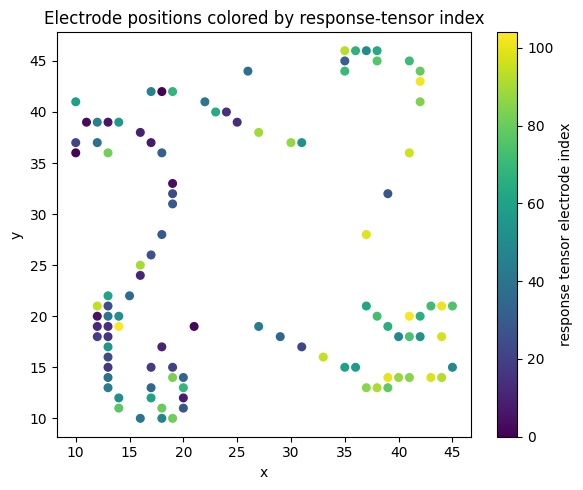

Adjacency shape: (105, 105) row sum range: 0.9999999 1.0000001
Hybrid relation adjacency shape: (4, 105, 105) row sum range: 0.9999999 1.0000001
Loop topology probe: ring smoother than shuffled fraction= 1.000 median propagation R2= 0.761


In [6]:
# ===== notebook cell 7 =====
# ============================================================
# 5. Electrode coordinates and kNN graph
# ============================================================
def try_extract_electrode_xy(impedance_map, electrodes):
    """
    Robust coordinate extraction for this course dataset.

    Why this is needed:
    - In this dataset `electrodes` is usually a vector of electrode IDs, not xy coordinates.
    - `impedance_map` is not guaranteed to be an ID image where `impedance_map[y,x] == electrode_id`.
    - The course plotting helper `map_colour_to_electrode(...)` can recover the actual plotted
      electrode locations. The previous model notebook did not use this fallback, so it silently
      fell back to a fake 1D index coordinate.

    Returns:
        coords: np.ndarray with shape [N,2], or None if all strategies fail.
    """
    el = np.asarray(electrodes)

    # Case A: electrodes already contains coordinates.
    # Try common column choices. The previous version used only the last two columns,
    # which is brittle if the array is [id, x, y] or [x, y, ...].
    if el.ndim == 2 and el.shape[0] == N and el.shape[1] >= 2:
        candidate_slices = [(0, 2)]
        if el.shape[1] >= 3:
            candidate_slices += [(1, 3), (el.shape[1] - 2, el.shape[1])]
        for a, b in candidate_slices:
            try:
                xy = el[:, a:b].astype(float)
                if (
                    np.all(np.isfinite(xy))
                    and np.unique(xy[:, 0]).size > 2
                    and np.unique(xy[:, 1]).size > 2
                    and np.unique(xy, axis=0).shape[0] > max(5, N // 4)
                ):
                    return xy
            except Exception:
                pass

    # Electrode IDs for lookup.
    if el.ndim == 1:
        ids = el.reshape(-1)
    elif el.ndim == 2 and el.shape[0] == N:
        ids = el[:, 0].reshape(-1)
    else:
        ids = np.arange(N)

    # Case B: dict-like mapping electrode id -> xy.
    # Try before array conversion; np.asarray(dict) produces a 0D object array.
    if isinstance(impedance_map, dict):
        coords = []
        ok = True
        for eid in ids:
            keys = [eid]
            try:
                keys.append(int(eid))
            except Exception:
                pass
            keys.append(str(eid))
            found = None
            for k in keys:
                if k in impedance_map:
                    found = impedance_map[k]
                    break
            if found is None:
                ok = False
                break
            arr = np.asarray(found).astype(float).ravel()
            if arr.size < 2:
                ok = False
                break
            coords.append(arr[:2])
        if ok and len(coords) == N:
            coords = np.asarray(coords, dtype=float)
            if np.unique(coords, axis=0).shape[0] > max(5, N // 4):
                return coords

    # Case C: impedance_map is a 2D grid containing electrode IDs.
    try:
        imp = np.squeeze(np.asarray(impedance_map))
        if imp.ndim > 2:
            imp = imp[..., 0]
        if imp.ndim == 2:
            coords = []
            ok = True
            for eid in ids:
                loc = np.argwhere(imp == eid)
                if loc.size == 0:
                    try:
                        loc = np.argwhere(imp == int(eid))
                    except Exception:
                        pass
                if loc.size == 0:
                    ok = False
                    break
                y, x = loc[0]
                coords.append([float(x), float(y)])
            if ok and len(coords) == N:
                coords = np.asarray(coords, dtype=float)
                if np.unique(coords, axis=0).shape[0] > max(5, N // 4):
                    return coords
    except Exception:
        pass

    # Case D: course plotting-helper fallback.
    # This was the missing piece. The audit notebook had it; this model notebook did not.
    if map_colour_to_electrode is None:
        print("map_colour_to_electrode is unavailable; cannot use plotting-helper coordinate extraction.")
        return None
    try:
        fig, ax = plt.subplots(figsize=(4, 4))
        map_colour_to_electrode(ax, impedance_map, electrodes)
        coords = None
        for collection in ax.collections:
            offsets = np.asarray(collection.get_offsets())
            if offsets.ndim == 2 and offsets.shape[0] == N and offsets.shape[1] >= 2:
                candidate = offsets[:, :2].astype(float)
                if (
                    np.all(np.isfinite(candidate))
                    and np.unique(candidate[:, 0]).size > 2
                    and np.unique(candidate[:, 1]).size > 2
                    and np.unique(candidate, axis=0).shape[0] > max(5, N // 4)
                ):
                    coords = candidate
                    break
        plt.close(fig)
        if coords is not None:
            return coords
    except Exception as e:
        try:
            plt.close(fig)
        except Exception:
            pass
        print("Plotting-helper coordinate extraction failed:", repr(e))

    return None

coords = try_extract_electrode_xy(impedance_map, electrodes)
if coords is None:
    msg = (
        "Could not extract physical electrode coordinates. "
        "Stopping instead of falling back to fake 1D coordinates, because that would make the graph ablation invalid."
    )
    if REQUIRE_PHYSICAL_COORDS:
        raise RuntimeError(msg)
    print("WARNING:", msg, "Using fake 1D coordinates only because REQUIRE_PHYSICAL_COORDS=False.")
    coords = np.stack([np.arange(N), np.zeros(N)], axis=1).astype(np.float32)
else:
    coords = coords.astype(np.float32)

# Fail fast if extraction returned a degenerate line or duplicate coordinates.
if REQUIRE_PHYSICAL_COORDS:
    if coords.ndim != 2 or coords.shape != (N, 2):
        raise RuntimeError(f"Invalid coordinate shape {coords.shape}; expected {(N, 2)}")
    if np.unique(coords, axis=0).shape[0] < max(5, N // 4):
        raise RuntimeError("Coordinate extraction produced too few unique positions; graph would be invalid.")
    if np.std(coords[:, 0]) < 1e-6 or np.std(coords[:, 1]) < 1e-6:
        raise RuntimeError("Coordinate extraction produced a degenerate 1D line; graph would be invalid.")

print("Coordinate ranges:", (float(coords[:,0].min()), float(coords[:,0].max())), (float(coords[:,1].min()), float(coords[:,1].max())))

coord_mean = coords.mean(axis=0, keepdims=True)
coord_std = coords.std(axis=0, keepdims=True) + 1e-6
coords_norm = (coords - coord_mean) / coord_std

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=np.arange(N), s=30)
plt.colorbar(label="response tensor electrode index")
plt.title("Electrode positions colored by response-tensor index")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


def build_knn_adjacency(coords_norm, k=8, self_weight=1.0):
    C = np.asarray(coords_norm, dtype=np.float32)
    d = ((C[:, None, :] - C[None, :, :]) ** 2).sum(axis=-1) ** 0.5
    A = np.zeros((len(C), len(C)), dtype=np.float32)
    for i in range(len(C)):
        nn_idx = np.argsort(d[i])[1:k+1]
        scale = np.median(d[i, nn_idx]) + 1e-6
        weights = np.exp(-d[i, nn_idx] / scale)
        A[i, nn_idx] = weights
    A = np.maximum(A, A.T)
    A += np.eye(len(C), dtype=np.float32) * self_weight
    A = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    return A

def row_normalize(A):
    A = np.asarray(A, dtype=np.float32)
    return A / (A.sum(axis=1, keepdims=True) + 1e-8)


def build_circular_electrode_features(coords_norm):
    C = np.asarray(coords_norm, dtype=np.float32)
    centered = C - C.mean(axis=0, keepdims=True)
    angles = np.arctan2(centered[:, 1], centered[:, 0]).astype(np.float32)
    radius = np.sqrt((centered ** 2).sum(axis=1)).astype(np.float32)
    radius = (radius - radius.mean()) / (radius.std() + 1e-6)
    features = np.stack([np.sin(angles), np.cos(angles), radius], axis=1).astype(np.float32)
    order = np.argsort(angles).astype(np.int64)
    return angles, features, order


def sparsify_topk(A, k):
    A = np.asarray(A, dtype=np.float32).copy()
    if k is None or int(k) <= 0 or A.shape[0] <= int(k):
        return A
    k = int(k)
    out = np.zeros_like(A, dtype=np.float32)
    for i in range(A.shape[0]):
        row = A[i].copy()
        row[i] = 0.0
        nz = np.flatnonzero(row > 0)
        if len(nz) == 0:
            continue
        keep = nz[np.argsort(row[nz])[-min(k, len(nz)):]]
        out[i, keep] = row[keep]
    return out


def build_soft_loop_adjacency(coords_norm, base_adjacency, loop_k=3, topk=6):
    """
    Distance-damped contour prior. It follows the coarse circular ordering but avoids
    treating that order as absolute by damping long jumps and keeping only local edges.
    """
    C = np.asarray(coords_norm, dtype=np.float32)
    angles, _, order = build_circular_electrode_features(C)
    n = len(order)
    d = ((C[:, None, :] - C[None, :, :]) ** 2).sum(axis=-1) ** 0.5
    base = np.asarray(base_adjacency, dtype=np.float32)
    local_d = d[base > 0]
    local_d = local_d[local_d > 1e-8]
    scale = float(np.median(local_d)) if local_d.size else float(np.median(d[d > 0]))
    scale = max(scale, 1e-6)
    A = np.zeros((n, n), dtype=np.float32)
    max_offset = max(1, int(loop_k))
    for pos, src in enumerate(order):
        for off in range(1, max_offset + 1):
            rank_weight = math.exp(-float(off - 1) / max(1.0, float(loop_k)))
            for sign in (-1, 1):
                dst = int(order[(pos + sign * off) % n])
                dist_weight = math.exp(-float(d[src, dst]) / scale)
                A[int(src), dst] = max(A[int(src), dst], rank_weight * dist_weight)
    A = np.maximum(A, A.T)
    A = sparsify_topk(A, topk)
    return row_normalize(A)


def build_response_correlation_adjacency(X_subset, k=8, min_corr=0.0):
    """Train-split-only functional relation between electrodes from average PSTH shape."""
    X_arr = np.asarray(X_subset, dtype=np.float32)
    if X_arr.ndim != 3 or X_arr.shape[1] == 0:
        return np.zeros((N, N), dtype=np.float32)
    profile = X_arr.mean(axis=0)
    if profile.shape[1] > 6:
        profile = profile[:, 6:]
    z = profile - profile.mean(axis=1, keepdims=True)
    z = z / (z.std(axis=1, keepdims=True) + 1e-6)
    corr = (z @ z.T) / max(1, z.shape[1])
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    np.fill_diagonal(corr, 0.0)
    corr = np.maximum(corr, float(min_corr))
    corr = np.clip(corr, 0.0, None)
    A = sparsify_topk(corr, int(k))
    A = np.maximum(A, A.T)
    return row_normalize(A)


def ensure_nonzero_rows(A, fallback):
    A = np.asarray(A, dtype=np.float32).copy()
    fallback = np.asarray(fallback, dtype=np.float32)
    zero = A.sum(axis=1) <= 1e-8
    if np.any(zero):
        A[zero] = fallback[zero]
    return A


def build_hybrid_relation_adjacency(base_adjacency, soft_loop_adjacency, response_adjacency=None):
    n = base_adjacency.shape[0]
    base = row_normalize(base_adjacency)
    soft_loop = ensure_nonzero_rows(soft_loop_adjacency, base)
    if response_adjacency is None:
        response_adjacency = np.zeros((n, n), dtype=np.float32)
    response = ensure_nonzero_rows(response_adjacency, base)
    self_rel = np.eye(n, dtype=np.float32)
    relations = np.stack([
        base,
        row_normalize(soft_loop),
        row_normalize(response),
        row_normalize(self_rel),
    ], axis=0).astype(np.float32)
    return relations


def build_ring_relation_adjacency(coords_norm, base_adjacency):
    # Backward-compatible diagnostic alias. The active model uses the richer
    # hybrid relation graph built by build_hybrid_relation_adjacency(...).
    soft_loop = build_soft_loop_adjacency(coords_norm, base_adjacency, loop_k=2, topk=4)
    return build_hybrid_relation_adjacency(base_adjacency, soft_loop), *build_circular_electrode_features(coords_norm)[::2]


def compute_loop_topology_metrics(X, angles, order, n_random=1000, seed=123):
    rng = np.random.default_rng(seed)
    mean_resp = np.asarray(X, dtype=np.float32).mean(axis=0)[:, 6:]
    def cycle_absdiff(o):
        vals = mean_resp[o]
        return float(np.mean(np.abs(vals - np.roll(vals, -1, axis=0))))
    ring_diff = cycle_absdiff(order)
    shuffled = np.asarray([cycle_absdiff(rng.permutation(len(order))) for _ in range(n_random)], dtype=np.float32)

    profile = np.asarray(X, dtype=np.float32).mean(axis=0)
    z = profile - profile.mean(axis=1, keepdims=True)
    z = z / (profile.std(axis=1, keepdims=True) + 1e-6)
    corr = (z @ z.T) / max(1, profile.shape[1])
    ring_pairs = [(int(e), int(order[(i + 1) % len(order)])) for i, e in enumerate(order)]
    ring_corr = np.asarray([corr[i, j] for i, j in ring_pairs], dtype=np.float32)
    random_corr = np.asarray([corr[tuple(rng.choice(len(order), 2, replace=False))] for _ in range(4000)], dtype=np.float32)

    active_bins = np.arange(6, min(40, X.shape[2]))
    propagation_rows = []
    for p in np.unique(patterns):
        proto = X[patterns == p].mean(axis=0)[:, active_bins]
        weights = np.clip(proto, 0, None)
        mass = weights.sum(axis=0)
        if float(mass.max()) < 1e-4:
            continue
        zc = (weights * np.exp(1j * angles[:, None])).sum(axis=0) / (mass + 1e-6)
        theta = np.unwrap(np.angle(zc))
        ok = mass > max(1e-4, np.percentile(mass, 50))
        if ok.sum() >= 5:
            t = active_bins[ok].astype(np.float32)
            y = theta[ok].astype(np.float32)
            slope, intercept = np.polyfit(t, y, 1)
            pred = slope * t + intercept
            ss_res = float(((y - pred) ** 2).sum())
            ss_tot = float(((y - y.mean()) ** 2).sum() + 1e-9)
            propagation_rows.append(dict(pattern=int(p), angular_slope_rad_per_bin=float(slope), r2=float(1.0 - ss_res / ss_tot), mean_active_mass=float(mass[ok].mean())))
    return dict(
        ring_order=[int(x) for x in order],
        ring_adjacent_corr_mean=float(ring_corr.mean()),
        random_pair_corr_mean=float(random_corr.mean()),
        ring_corr_percentile_vs_random=float((random_corr < ring_corr.mean()).mean()),
        angular_ring_absdiff=float(ring_diff),
        shuffled_absdiff_mean=float(shuffled.mean()),
        ring_smoother_than_shuffle_fraction=float((ring_diff < shuffled).mean()),
        median_abs_angular_slope=float(np.median([abs(r["angular_slope_rad_per_bin"]) for r in propagation_rows])) if propagation_rows else None,
        median_propagation_r2=float(np.median([r["r2"] for r in propagation_rows])) if propagation_rows else None,
        propagation_by_pattern=propagation_rows,
    )


adjacency = build_knn_adjacency(coords_norm, k=BASE_MODEL_CONFIG["graph_k"])
identity_adjacency = np.eye(N, dtype=np.float32)
electrode_angles, electrode_circular_features, electrode_ring_order = build_circular_electrode_features(coords_norm)
soft_loop_adjacency = build_soft_loop_adjacency(coords_norm, adjacency, loop_k=BASE_MODEL_CONFIG["loop_graph_k"], topk=6)
# Full-data response graph is diagnostic only; train_one_variant rebuilds it from train_indices to avoid validation leakage.
response_correlation_adjacency_diagnostic = build_response_correlation_adjacency(X, k=BASE_MODEL_CONFIG["response_graph_k"])
graph_relation_names = ["knn", "soft_loop", "response_corr", "self"]
hybrid_relation_adjacency = build_hybrid_relation_adjacency(adjacency, soft_loop_adjacency, response_correlation_adjacency_diagnostic)
ring_relation_adjacency = hybrid_relation_adjacency  # backward-compatible checkpoint key
loop_topology_metrics = compute_loop_topology_metrics(X, electrode_angles, electrode_ring_order)
print("Adjacency shape:", adjacency.shape, "row sum range:", adjacency.sum(axis=1).min(), adjacency.sum(axis=1).max())
print("Hybrid relation adjacency shape:", hybrid_relation_adjacency.shape, "row sum range:", hybrid_relation_adjacency.sum(axis=-1).min(), hybrid_relation_adjacency.sum(axis=-1).max())
smooth_frac = float(loop_topology_metrics["ring_smoother_than_shuffle_fraction"])
median_prop_r2 = float(loop_topology_metrics["median_propagation_r2"])
print("Loop topology probe: ring smoother than shuffled fraction=", f"{smooth_frac:.3f}", "median propagation R2=", f"{median_prop_r2:.3f}")


In [7]:
# ===== notebook cell 8 =====
# ============================================================
# 6. Train/validation split
# ============================================================
def make_split(mode="random", val_frac=0.1, seed=None):
    rng = np.random.default_rng(seed)
    idx = np.arange(M)
    if mode == "random":
        rng.shuffle(idx)
        n_val = int(round(M * val_frac))
        return idx[n_val:], idx[:n_val]

    if mode == "blocked_time":
        n_val = int(round(M * val_frac))
        return idx[:-n_val], idx[-n_val:]

    if mode == "leave_frequency_out":
        unique_f = np.sort(np.unique(freqs))
        rng.shuffle(unique_f)
        n_val_f = max(1, int(round(len(unique_f) * val_frac)))
        val_freqs = set(unique_f[:n_val_f].tolist())
        val_mask = np.array([f in val_freqs for f in freqs])
        return idx[~val_mask], idx[val_mask]

    if mode == "leave_pattern_out":
        unique_p = np.sort(np.unique(patterns))
        rng.shuffle(unique_p)
        n_val_p = max(1, int(round(len(unique_p) * val_frac)))
        val_patterns = set(unique_p[:n_val_p].tolist())
        val_mask = np.array([int(p) in val_patterns for p in patterns])
        return idx[~val_mask], idx[val_mask]

    raise ValueError(f"Unknown split mode: {mode}")


def set_active_split(seed=None):
    global train_idx, val_idx, CURRENT_SPLIT_SEED
    CURRENT_SPLIT_SEED = seed
    train_idx, val_idx = make_split(SPLIT_MODE, VAL_FRAC, seed)
    if seed is None:
        print("Random validation split: fresh unseeded draw")
    else:
        print("Random validation split seed:", seed)
    print("Train trials:", len(train_idx), "Val trials:", len(val_idx))
    print("Train unique freqs:", len(np.unique(freqs[train_idx])), "Val unique freqs:", len(np.unique(freqs[val_idx])))
    print("Train unique patterns:", np.unique(patterns[train_idx]).tolist())
    print("Val unique patterns:", np.unique(patterns[val_idx]).tolist())
    print("Train pattern counts:", np.bincount(patterns[train_idx], minlength=n_patterns)[:n_patterns])
    print("Val pattern counts:", np.bincount(patterns[val_idx], minlength=n_patterns)[:n_patterns])
    return train_idx, val_idx

train_idx, val_idx = set_active_split(RANDOM_SEED)


Random validation split seed: 42
Train trials: 57499 Val trials: 19166
Train unique freqs: 34 Val unique freqs: 34
Train unique patterns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Val unique patterns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Train pattern counts: [3625 3683 3661 3481 3562 3628 3620 3604 3560 3603 3555 3652 3570 3608
 3595 3492]
Val pattern counts: [1187 1206 1184 1194 1242 1251 1179 1206 1220 1203 1204 1173 1148 1213
 1153 1203]


In [8]:
# ===== notebook cell 9 =====
# ============================================================
# 7. Baseline logits
# ============================================================
def compute_baseline_logits(X_train, patterns_train, n_patterns, alpha=25.0, eps=1e-5):
    global_p = X_train.mean(axis=0).astype(np.float32)
    baseline_p = np.zeros((n_patterns, X_train.shape[1], X_train.shape[2]), dtype=np.float32)
    for p in range(n_patterns):
        mask = patterns_train == p
        if mask.sum() == 0:
            baseline_p[p] = global_p
        else:
            n = int(mask.sum())
            baseline_p[p] = (X_train[mask].sum(axis=0) + alpha * global_p) / (n + alpha)
    return np_logit(baseline_p, eps=eps).astype(np.float32), global_p.astype(np.float32)


def compute_pattern_frequency_baseline_logits(
    X_train,
    patterns_train,
    freqs_train,
    n_patterns,
    freq_values,
    pattern_baseline_logits,
    alpha=5.0,
    eps=1e-5,
):
    """Train-only smoothed pattern-frequency baseline, backed off to the pattern baseline."""
    pattern_p = 1.0 / (1.0 + np.exp(-pattern_baseline_logits))
    freq_values = np.asarray(freq_values, dtype=np.float32)
    baseline_p = np.zeros((n_patterns, len(freq_values), X_train.shape[1], X_train.shape[2]), dtype=np.float32)
    patterns_train = np.asarray(patterns_train).astype(int)
    freqs_train = np.asarray(freqs_train).astype(np.float32)
    for p in range(n_patterns):
        pattern_prior = pattern_p[p]
        for fi, f in enumerate(freq_values):
            mask = (patterns_train == p) & (freqs_train == f)
            n = int(mask.sum())
            if n == 0:
                baseline_p[p, fi] = pattern_prior
            else:
                baseline_p[p, fi] = (X_train[mask].sum(axis=0) + float(alpha) * pattern_prior) / (n + float(alpha))
    return np_logit(baseline_p, eps=eps).astype(np.float32), freq_values


def pattern_frequency_probs_from_logits(pf_logits, freq_values, pattern_ids, freq_arr):
    freq_values = np.asarray(freq_values, dtype=np.float32)
    pattern_ids = np.asarray(pattern_ids).astype(int)
    freq_arr = np.asarray(freq_arr, dtype=np.float32)
    freq_indices = np.abs(freq_arr[:, None] - freq_values[None, :]).argmin(axis=1)
    return 1.0 / (1.0 + np.exp(-pf_logits[pattern_ids, freq_indices]))

pattern_baseline_logits, global_p = compute_baseline_logits(
    X[train_idx], patterns[train_idx], n_patterns,
    alpha=BASE_MODEL_CONFIG["pattern_baseline_alpha"]
)
global_baseline_logits = np_logit(global_p)[None, :, :].repeat(n_patterns, axis=0).astype(np.float32)
baseline_freq_values = np.sort(np.unique(freqs[train_idx])).astype(np.float32)
pattern_frequency_baseline_logits, baseline_freq_values = compute_pattern_frequency_baseline_logits(
    X[train_idx], patterns[train_idx], freqs[train_idx], n_patterns, baseline_freq_values, pattern_baseline_logits,
    alpha=BASE_MODEL_CONFIG.get("pattern_frequency_baseline_alpha", 5.0),
)


def eval_pattern_baseline(idx, name):
    probs = 1 / (1 + np.exp(-pattern_baseline_logits[patterns[idx]]))
    pf_probs = pattern_frequency_probs_from_logits(pattern_frequency_baseline_logits, baseline_freq_values, patterns[idx], freqs[idx])
    bce = bce_from_prob_np(X[idx], probs)
    pf_bce = bce_from_prob_np(X[idx], pf_probs)
    global_bce = bce_from_prob_np(X[idx], np.broadcast_to(global_p, X[idx].shape))
    print(f"{name}: global BCE={global_bce:.6f}, pattern BCE={bce:.6f}, pattern-frequency BCE={pf_bce:.6f}, pattern improvement={(global_bce-bce)/global_bce*100:.2f}%")
    return global_bce, bce

train_global_bce, train_pattern_bce = eval_pattern_baseline(train_idx, "train")
val_global_bce, val_pattern_bce = eval_pattern_baseline(val_idx, "val")


train: global BCE=0.087016, pattern BCE=0.073265, pattern-frequency BCE=0.069162, pattern improvement=15.80%
val: global BCE=0.087221, pattern BCE=0.073727, pattern-frequency BCE=0.075290, pattern improvement=15.47%


In [9]:
# ===== notebook cell 10 =====
# ============================================================
# 8. Deployable context features: previous z, z-window summaries, predicted-history placeholders
# ============================================================
def build_prev_z_features(freqs_arr, patterns_arr, stim_times_arr=None):
    """Causal features using only previous stimulation parameters."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    prev_f = np.empty_like(f)
    prev_p = np.empty_like(p)
    prev_f[0] = f[0]
    prev_p[0] = p[0]
    prev_f[1:] = f[:-1]
    prev_p[1:] = p[:-1]

    if stim_times_arr is not None:
        st = np.asarray(stim_times_arr, dtype=np.float32).reshape(-1)
        if len(st) == len(f):
            dt = np.empty_like(f, dtype=np.float32)
            dt[0] = np.median(np.diff(st)) if len(st) > 1 else 0.0
            dt[1:] = np.diff(st)
        else:
            dt = np.ones_like(f, dtype=np.float32)
    else:
        dt = np.ones_like(f, dtype=np.float32)

    rolling_prev_f3 = np.zeros_like(f, dtype=np.float32)
    for i in range(len(f)):
        lo = max(0, i - 3)
        rolling_prev_f3[i] = f[lo:i].mean() if i > lo else f[i]
    freq_delta = f - prev_f
    feats = np.stack([prev_f, dt, rolling_prev_f3, freq_delta], axis=1).astype(np.float32)
    names = ["prev_freq", "delta_t", "rolling_prev_freq3", "freq_delta"]
    return prev_p.astype(np.int64), feats, names


def build_z_window_summary_features(freqs_arr, patterns_arr, n_patterns, windows=(3, 5, 10, 20)):
    """Causal hand-crafted features from previous stimulation schedule only."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    Mloc = len(f)
    rows = []
    names = []
    for i in range(Mloc):
        vals = []
        for w in windows:
            lo = max(0, i - w)
            pf = f[lo:i]
            pp = p[lo:i]
            if len(pf) == 0:
                pf = f[i:i+1]
                pp = p[i:i+1]
            vals.extend([
                float(pf.mean()),
                float(pf.std()) if len(pf) > 1 else 0.0,
                float(pf[-1]),
                float(f[i] - pf[-1]),
                float(len(np.unique(pp)) / max(1, min(w, n_patterns))),
                float(np.mean(pp == p[i])),
            ])
        rows.append(vals)
    for w in windows:
        names.extend([
            f"zwin{w}_freq_mean",
            f"zwin{w}_freq_std",
            f"zwin{w}_last_freq",
            f"zwin{w}_current_minus_last_freq",
            f"zwin{w}_pattern_diversity",
            f"zwin{w}_same_current_pattern_frac",
        ])
    return np.asarray(rows, dtype=np.float32), names


def build_z_history_sequences(freqs_arr, patterns_arr, stim_times_arr=None, history_len=24):
    """Return previous-z token sequence for each trial. No current trial included."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    Mloc = len(f)
    hist_p = np.zeros((Mloc, history_len), dtype=np.int64)
    hist_cont = np.zeros((Mloc, history_len, 3), dtype=np.float32)
    f_min = float(np.min(f)); f_max = float(np.max(f))
    denom = f_max - f_min + 1e-6

    if stim_times_arr is not None:
        st = np.asarray(stim_times_arr, dtype=np.float32).reshape(-1)
        if len(st) == len(f):
            dt_all = np.empty_like(f, dtype=np.float32)
            dt_all[0] = np.median(np.diff(st)) if len(st) > 1 else 0.0
            dt_all[1:] = np.diff(st)
        else:
            dt_all = np.ones_like(f, dtype=np.float32)
    else:
        dt_all = np.ones_like(f, dtype=np.float32)
    dt_scale = np.percentile(dt_all[1:], 95) if len(dt_all) > 1 else 1.0
    dt_scale = max(float(dt_scale), 1e-6)

    for i in range(Mloc):
        for k in range(history_len):
            j = i - history_len + k
            if j < 0:
                jj = 0
                valid = 0.0
            else:
                jj = j
                valid = 1.0
            hist_p[i, k] = int(p[jj])
            f_norm = (float(f[jj]) - f_min) / denom
            dt_norm = float(dt_all[jj]) / dt_scale
            age_norm = (history_len - k) / history_len
            hist_cont[i, k] = [f_norm, dt_norm, age_norm * valid]
    hist_cont = np.nan_to_num(hist_cont, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return hist_p, hist_cont


def standardize_context(train_context, full_context):
    train_context = np.asarray(train_context, dtype=np.float32)
    full_context = np.asarray(full_context, dtype=np.float32)
    mean = train_context.mean(axis=0, keepdims=True)
    std = train_context.std(axis=0, keepdims=True) + 1e-6
    norm = (full_context - mean) / std
    norm = np.nan_to_num(norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return norm, mean.astype(np.float32), std.astype(np.float32)


prev_patterns, prevz_raw, prevz_names = build_prev_z_features(freqs, patterns, stimulation_times)
zsummary_raw, zsummary_names = build_z_window_summary_features(freqs, patterns, n_patterns)
hist_patterns, hist_cont = build_z_history_sequences(freqs, patterns, stimulation_times, history_len=MAX_Z_HISTORY_LEN)

zsummary_full_raw = np.concatenate([prevz_raw, zsummary_raw], axis=1)
zsummary_all_names = prevz_names + zsummary_names
nonfreq_context_cols = [i for i, nm in enumerate(zsummary_all_names) if "freq" not in nm]
freq_context_cols = [i for i, nm in enumerate(zsummary_all_names) if "freq" in nm]
zsummary_nofreq_raw = zsummary_full_raw[:, nonfreq_context_cols]
zsummary_freq_raw = zsummary_full_raw[:, freq_context_cols]


def build_contexts_for_train(train_indices):
    train_indices = np.asarray(train_indices, dtype=int)
    contexts = {}
    prevz_norm, prevz_mean, prevz_std = standardize_context(prevz_raw[train_indices], prevz_raw)
    contexts["prevz_only"] = dict(raw=prevz_raw, norm=prevz_norm, mean=prevz_mean, std=prevz_std, names=prevz_names)

    zsummary_norm, zsummary_mean, zsummary_std = standardize_context(zsummary_full_raw[train_indices], zsummary_full_raw)
    contexts["z_window_summary"] = dict(
        raw=zsummary_full_raw, norm=zsummary_norm, mean=zsummary_mean, std=zsummary_std,
        names=prevz_names + zsummary_names,
    )

    zsummary_nofreq_norm, zsummary_nofreq_mean, zsummary_nofreq_std = standardize_context(zsummary_nofreq_raw[train_indices], zsummary_nofreq_raw)
    contexts["z_window_no_frequency_context"] = dict(
        raw=zsummary_nofreq_raw, norm=zsummary_nofreq_norm, mean=zsummary_nofreq_mean, std=zsummary_nofreq_std,
        names=[zsummary_all_names[i] for i in nonfreq_context_cols],
    )

    zsummary_freq_norm, zsummary_freq_mean, zsummary_freq_std = standardize_context(zsummary_freq_raw[train_indices], zsummary_freq_raw)
    contexts["z_window_frequency_context"] = dict(
        raw=zsummary_freq_raw, norm=zsummary_freq_norm, mean=zsummary_freq_mean, std=zsummary_freq_std,
        names=[zsummary_all_names[i] for i in freq_context_cols],
    )
    return contexts


CONTEXTS = build_contexts_for_train(train_idx)
print("Available initial contexts:")
for k, v in CONTEXTS.items():
    print(f"  {k}: dim={v['norm'].shape[1]}")
print("z-GRU history arrays:", hist_patterns.shape, hist_cont.shape)


Available initial contexts:
  prevz_only: dim=4
  z_window_summary: dim=28
  z_window_no_frequency_context: dim=9
  z_window_frequency_context: dim=19
z-GRU history arrays: (76665, 24) (76665, 24, 3)


In [10]:
# ===== notebook cell 11 =====
# ============================================================
# 9. Dataset and DataLoaders
# ============================================================
_BASE_TENSORS = {}


def get_base_tensors():
    """Cache immutable CPU tensors once per worker process."""
    if not _BASE_TENSORS:
        _BASE_TENSORS.update(
            X=torch.as_tensor(X, dtype=torch.float32),
            patterns=torch.as_tensor(patterns, dtype=torch.long),
            freqs=torch.as_tensor(freqs, dtype=torch.float32),
            prev_patterns=torch.as_tensor(prev_patterns, dtype=torch.long),
            hist_patterns=torch.as_tensor(hist_patterns, dtype=torch.long),
            hist_cont=torch.as_tensor(hist_cont, dtype=torch.float32),
        )
    return _BASE_TENSORS


class Task2Dataset(Dataset):
    def __init__(self, indices, cont_context, history_len=Z_HISTORY_LEN):
        base = get_base_tensors()
        self.indices = torch.as_tensor(np.asarray(indices), dtype=torch.long)
        self.X = base["X"]
        self.patterns = base["patterns"]
        self.freqs = base["freqs"]
        self.prev_patterns = base["prev_patterns"]
        self.cont_context = torch.as_tensor(cont_context, dtype=torch.float32)
        self.hist_patterns = base["hist_patterns"]
        self.hist_cont = base["hist_cont"]
        self.history_len = int(history_len)
        if self.history_len < 1 or self.history_len > self.hist_patterns.shape[1]:
            raise ValueError(f"history_len must be in [1, {self.hist_patterns.shape[1]}], got {self.history_len}")

    def __len__(self):
        return int(self.indices.numel())

    def __getitem__(self, j):
        i = self.indices[j]
        return {
            "trial_index": i,
            "pattern": self.patterns[i],
            "freq": self.freqs[i],
            "prev_pattern": self.prev_patterns[i],
            "context": self.cont_context[i],
            "hist_patterns": self.hist_patterns[i, -self.history_len:],
            "hist_cont": self.hist_cont[i, -self.history_len:, :],
            "x": self.X[i],
        }


def make_loader(indices, context_array, shuffle=False, batch_size=BATCH_SIZE, history_len=Z_HISTORY_LEN):
    ds = Task2Dataset(indices, context_array, history_len=history_len)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        persistent_workers=(NUM_WORKERS > 0),
    )

# Sanity check with prevz context and default history length.
batch = next(iter(make_loader(train_idx[:min(8, len(train_idx))], CONTEXTS["prevz_only"]["norm"], shuffle=False, batch_size=8, history_len=Z_HISTORY_LEN)))
for k, v in batch.items():
    print(k, tuple(v.shape), v.dtype)


trial_index (8,) torch.int64
pattern (8,) torch.int64
freq (8,) torch.float32
prev_pattern (8,) torch.int64
context (8, 4) torch.float32
hist_patterns (8, 24) torch.int64
hist_cont (8, 24, 3) torch.float32
x (8, 105, 80) torch.float32


In [11]:
# ===== notebook cell 12 =====
# ============================================================
# 10. Model: C2 residual decoder + deployable z-history mechanisms
# ============================================================
class FrequencyEncoder(nn.Module):
    def __init__(self, f_min, f_max, n_rbf=16, use_rbf=True):
        super().__init__()
        self.use_rbf = bool(use_rbf and n_rbf > 0)
        self.n_rbf = int(n_rbf) if self.use_rbf else 0
        self.register_buffer("f_min", torch.tensor(float(f_min)))
        self.register_buffer("f_max", torch.tensor(float(f_max)))
        if self.use_rbf:
            log_min = math.log(max(float(f_min), 1e-4))
            log_max = math.log(max(float(f_max), 1e-4))
            centers = torch.linspace(log_min, log_max, self.n_rbf)
            self.register_buffer("centers", centers)
            width = float((centers[1] - centers[0]).abs()) if self.n_rbf > 1 else 1.0
            self.log_width = nn.Parameter(torch.tensor(math.log(width + 1e-6)), requires_grad=False)
        else:
            self.register_buffer("centers", torch.zeros(0))
            self.log_width = nn.Parameter(torch.tensor(0.0), requires_grad=False)

    @property
    def out_dim(self):
        return 2 + 8 + self.n_rbf

    def forward(self, f):
        f = f.float().clamp_min(1e-4)
        f_norm = (f - self.f_min) / (self.f_max - self.f_min + 1e-6)
        lf = torch.log(f)
        lf_min = torch.log(self.f_min.clamp_min(1e-4))
        lf_max = torch.log(self.f_max.clamp_min(1e-4))
        lf_norm = (lf - lf_min) / (lf_max - lf_min + 1e-6)
        fourier = []
        for k in [1.0, 2.0, 4.0, 8.0]:
            fourier.append(torch.sin(2 * math.pi * k * lf_norm))
            fourier.append(torch.cos(2 * math.pi * k * lf_norm))
        fourier = torch.stack(fourier, dim=-1)
        pieces = [f_norm[:, None], lf_norm[:, None], fourier]
        if self.use_rbf:
            width = torch.exp(self.log_width)
            rbf = torch.exp(-0.5 * ((lf[:, None] - self.centers[None, :]) / (width + 1e-6)) ** 2)
            pieces.append(rbf)
        return torch.cat(pieces, dim=-1)


class ZHistoryEncoder(nn.Module):
    """GRU over previous stimulation tokens only. Fully deployable."""
    def __init__(self, n_patterns, pattern_dim=16, cont_dim=3, hidden_dim=48, layers=1, dropout=0.0, pattern_mode="embedding"):
        super().__init__()
        self.pattern_mode = str(pattern_mode)
        if self.pattern_mode == "embedding":
            self.pattern_emb = nn.Embedding(n_patterns, pattern_dim)
            pattern_in_dim = pattern_dim
        elif self.pattern_mode == "bits":
            self.pattern_emb = None
            pattern_in_dim = 4
        elif self.pattern_mode == "none":
            self.pattern_emb = None
            pattern_in_dim = 0
        else:
            raise ValueError(f"Unknown z-history pattern_mode: {pattern_mode}")
        self.step_mlp = nn.Sequential(
            nn.Linear(pattern_in_dim + cont_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.out_dim = hidden_dim

    @staticmethod
    def pattern_bits(pattern):
        return torch.stack([((pattern >> b) & 1).float() for b in range(4)], dim=-1)

    def forward(self, hist_patterns, hist_cont):
        # hist_patterns: [B,L], hist_cont: [B,L,C]
        if self.pattern_mode == "embedding":
            pat = self.pattern_emb(hist_patterns.clamp_min(0))
            x = torch.cat([pat, hist_cont.float()], dim=-1)
        elif self.pattern_mode == "bits":
            pat = self.pattern_bits(hist_patterns.clamp_min(0))
            x = torch.cat([pat, hist_cont.float()], dim=-1)
        else:
            x = hist_cont.float()
        x = self.step_mlp(x)
        _, h = self.gru(x)
        return h[-1]

class GraphBlock(nn.Module):
    def __init__(self, hidden_dim, cond_dim, n_relations=1, dropout=0.1):
        super().__init__()
        self.n_relations = int(n_relations)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * (1 + self.n_relations) + cond_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, cond, adj, relation_gates=None):
        if adj.ndim == 2:
            messages = torch.einsum("ij,bjh->bih", adj, h)
        elif adj.ndim == 3:
            if relation_gates is not None:
                adj = adj * relation_gates.view(-1, 1, 1)
            messages = torch.einsum("rij,bjh->brih", adj, h).permute(0, 2, 1, 3).reshape(h.shape[0], h.shape[1], -1)
        else:
            raise ValueError(f"Expected adjacency [N,N] or [R,N,N], got {tuple(adj.shape)}")
        c = cond[:, None, :].expand(-1, h.shape[1], -1)
        upd = self.mlp(torch.cat([h, messages, c], dim=-1))
        return self.norm(h + self.dropout(upd))


class CoordGraphTemporalResidualDecoder(nn.Module):
    def __init__(self, n_patterns, n_electrodes, n_time, coords_norm, adjacency, pattern_baseline_logits,
                 f_min, f_max, config, electrode_circular_features=None):
        super().__init__()
        self.n_patterns = n_patterns
        self.n_electrodes = n_electrodes
        self.n_time = n_time
        self.config = dict(config)

        self.register_buffer("coords", torch.as_tensor(coords_norm, dtype=torch.float32))
        self.register_buffer("adj", torch.as_tensor(adjacency, dtype=torch.float32))
        if electrode_circular_features is None:
            electrode_circular_features = np.zeros((n_electrodes, 3), dtype=np.float32)
        self.register_buffer("electrode_circular_features", torch.as_tensor(electrode_circular_features, dtype=torch.float32))
        baseline_tensor = torch.as_tensor(pattern_baseline_logits, dtype=torch.float32)
        self.register_buffer("pattern_baseline_logits", baseline_tensor)
        freq_values = config.get("baseline_freq_values", None)
        if baseline_tensor.ndim == 4:
            if freq_values is None:
                raise ValueError("pattern-frequency baseline logits require config['baseline_freq_values']")
            self.register_buffer("baseline_freq_values", torch.as_tensor(freq_values, dtype=torch.float32))
        else:
            self.register_buffer("baseline_freq_values", torch.empty(0, dtype=torch.float32))

        pattern_emb_dim = int(config["pattern_emb_dim"])
        bit_emb_dim = int(config["bit_emb_dim"])
        electrode_emb_dim = int(config["electrode_emb_dim"])
        cond_dim = int(config["cond_dim"])
        hidden_dim = int(config["hidden_dim"])
        k_modes = int(config["k_modes"])
        dropout = float(config["dropout"])

        self.use_pattern_embedding = bool(config.get("use_pattern_embedding", True))
        self.use_bit_features = bool(config.get("use_bit_features", True))
        self.current_bit_feature_mode = str(config.get("current_bit_feature_mode", "single"))
        self.current_bit_encoder = str(config.get("current_bit_encoder", "mlp"))
        self.use_frequency_features = bool(config.get("use_frequency_features", True))
        self.use_frequency_film = bool(config.get("use_frequency_film", False))
        self.use_prev_z_context = bool(config.get("use_prev_z_context", True))
        self.use_prev_pattern_context = bool(config.get("use_prev_pattern_context", True))
        self.use_prev_pattern_bit_context = bool(config.get("use_prev_pattern_bit_context", False))
        self.use_cont_context = bool(config.get("use_cont_context", True))
        self.use_z_gru_state = bool(config.get("use_z_gru_state", False))
        self.use_coordinates = bool(config.get("use_coordinates", True))
        self.use_electrode_embedding = bool(config.get("use_electrode_embedding", True))
        self.use_electrode_rate = bool(config.get("use_electrode_rate", True))
        self.use_graph = bool(config.get("use_graph", True))
        self.use_cond_time_bias = bool(config.get("use_cond_time_bias", True))
        self.use_circular_electrode_features = bool(config.get("use_circular_electrode_features", False))
        self.use_pattern_residual_gate = bool(config.get("use_pattern_residual_gate", False))
        self.pattern_residual_gate_min = float(config.get("pattern_residual_gate_min", 0.0))
        if self.use_pattern_embedding:
            self.pattern_emb = nn.Embedding(n_patterns, pattern_emb_dim)
            pattern_cond_dim = pattern_emb_dim
        else:
            self.pattern_emb = None
            pattern_cond_dim = 0

        if self.use_prev_z_context and self.use_prev_pattern_context:
            self.prev_pattern_emb = nn.Embedding(n_patterns, max(1, pattern_emb_dim // 2))
            self.prev_pattern_bit_mlp = None
            prev_pattern_dim = max(1, pattern_emb_dim // 2)
        elif self.use_prev_z_context and self.use_prev_pattern_bit_context:
            self.prev_pattern_emb = None
            self.prev_pattern_bit_mlp = nn.Sequential(nn.Linear(4, bit_emb_dim), nn.GELU(), nn.Linear(bit_emb_dim, bit_emb_dim))
            prev_pattern_dim = bit_emb_dim
        else:
            self.prev_pattern_emb = None
            self.prev_pattern_bit_mlp = None
            prev_pattern_dim = 0

        if self.use_bit_features:
            if self.current_bit_feature_mode != "single" or self.current_bit_encoder != "linear":
                raise ValueError("Cleaned C4 baseline only supports four raw current bits with a linear projection.")
            self.bit_mlp = nn.Linear(4, bit_emb_dim)
            bit_cond_dim = bit_emb_dim
        else:
            self.bit_mlp = None
            bit_cond_dim = 0

        if self.use_frequency_features:
            self.freq_enc = FrequencyEncoder(f_min, f_max, n_rbf=config["freq_rbf_dim"], use_rbf=config.get("use_rbf_features", True))
            freq_cond_dim = self.freq_enc.out_dim
        else:
            self.freq_enc = None
            freq_cond_dim = 0


        self.context_dim = int(config.get("context_dim", 4)) if (self.use_prev_z_context and self.use_cont_context) else 0
        context_dim = self.context_dim

        if self.use_z_gru_state:
            self.z_hist_enc = ZHistoryEncoder(
                n_patterns=n_patterns,
                pattern_dim=max(8, pattern_emb_dim // 2),
                cont_dim=3,
                hidden_dim=int(config.get("z_gru_hidden_dim", 48)),
                layers=int(config.get("z_gru_layers", 1)),
                dropout=dropout,
                pattern_mode=config.get("z_history_pattern_mode", "embedding"),
            )
            z_state_dim = self.z_hist_enc.out_dim
        else:
            self.z_hist_enc = None
            z_state_dim = 0

        cond_in = pattern_cond_dim + bit_cond_dim + freq_cond_dim + prev_pattern_dim + context_dim + z_state_dim
        if cond_in <= 0:
            cond_in = 1
            self.cond_dummy = True
        else:
            self.cond_dummy = False

        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_in, cond_dim * 2),
            nn.LayerNorm(cond_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(cond_dim * 2, cond_dim),
            nn.LayerNorm(cond_dim),
            nn.GELU(),
        )
        if self.use_frequency_film and self.use_frequency_features:
            self.freq_film = nn.Sequential(
                nn.Linear(freq_cond_dim, cond_dim * 2),
                nn.GELU(),
                nn.Linear(cond_dim * 2, cond_dim * 2),
            )
            nn.init.zeros_(self.freq_film[-1].weight)
            nn.init.zeros_(self.freq_film[-1].bias)
        else:
            self.freq_film = None

        if self.use_electrode_embedding:
            self.electrode_emb = nn.Embedding(n_electrodes, electrode_emb_dim)
            elec_emb_dim_used = electrode_emb_dim
        else:
            self.electrode_emb = None
            elec_emb_dim_used = 0

        coord_dim = 2 if self.use_coordinates else 0
        circular_dim = 3 if self.use_circular_electrode_features else 0
        erate_dim = 1 if self.use_electrode_rate else 0
        elec_feat_dim = coord_dim + circular_dim + 1 + erate_dim + elec_emb_dim_used + cond_dim
        self.electrode_in = nn.Sequential(
            nn.Linear(elec_feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        n_graph_layers = int(config["n_graph_layers"]) if self.use_graph else 0
        n_graph_relations = int(self.adj.shape[0]) if self.adj.ndim == 3 else 1
        self.graph_relation_names = list(config.get("graph_relation_names", [f"relation_{i}" for i in range(n_graph_relations)]))[:n_graph_relations]
        while len(self.graph_relation_names) < n_graph_relations:
            self.graph_relation_names.append(f"relation_{len(self.graph_relation_names)}")
        self.use_learned_relation_gates = bool(config.get("use_learned_relation_gates", False)) and self.adj.ndim == 3
        if self.use_learned_relation_gates:
            init_cfg = config.get("relation_gate_init", {})
            init_vals = []
            for nm in self.graph_relation_names:
                init_vals.append(float(init_cfg.get(nm, 0.5)))
            init = torch.tensor(init_vals, dtype=torch.float32).clamp(1e-4, 1.0 - 1e-4)
            self.relation_gate_logit = nn.Parameter(torch.logit(init))
        else:
            self.relation_gate_logit = None
        self.graph_blocks = nn.ModuleList([GraphBlock(hidden_dim, cond_dim, n_relations=n_graph_relations, dropout=dropout) for _ in range(n_graph_layers)])

        self.time_emb = nn.Embedding(n_time, max(4, hidden_dim // 2))
        self.time_mlp = nn.Sequential(
            nn.Linear(max(4, hidden_dim // 2) + 4, k_modes),
            nn.GELU(),
            nn.Linear(k_modes, k_modes),
        )
        self.coeff_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, k_modes),
        )
        self.spatial_bias = nn.Linear(hidden_dim, 1)
        self.cond_time_bias = nn.Sequential(nn.Linear(cond_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, n_time))

        nn.init.normal_(self.coeff_head[-1].weight, mean=0.0, std=1e-4)
        nn.init.zeros_(self.coeff_head[-1].bias)
        nn.init.zeros_(self.spatial_bias.weight)
        nn.init.zeros_(self.spatial_bias.bias)
        nn.init.zeros_(self.cond_time_bias[-1].weight)
        nn.init.zeros_(self.cond_time_bias[-1].bias)
        self.residual_scale = nn.Parameter(torch.tensor(0.2))
        if self.use_pattern_residual_gate:
            self.pattern_residual_gate_logit = nn.Embedding(n_patterns, 1)
        else:
            self.pattern_residual_gate_logit = None

        with torch.no_grad():
            p = torch.sigmoid(self.pattern_baseline_logits.float())
            if p.ndim == 4:
                electrode_rate = p.mean(dim=(0, 1, 3))
            else:
                electrode_rate = p.mean(dim=(0, 2))
            electrode_rate = (electrode_rate - electrode_rate.mean()) / (electrode_rate.std() + 1e-6)
            self.register_buffer("electrode_rate", electrode_rate.float())
            idx = torch.linspace(-1, 1, n_electrodes)
            self.register_buffer("electrode_index_norm", idx.float())
            if self.pattern_residual_gate_logit is not None:
                pattern_activity = p.mean(dim=(1, 2, 3)) if p.ndim == 4 else p.mean(dim=(1, 2))
                lo = float(pattern_activity.min())
                hi = float(pattern_activity.max())
                activity_norm = (pattern_activity - lo) / max(hi - lo, 1e-6)
                gate_min = float(self.pattern_residual_gate_min)
                gate_max = float(config.get("pattern_residual_gate_init_max", 0.95))
                init_gate = gate_min + (gate_max - gate_min) * activity_norm
                init_gate = init_gate.clamp(gate_min + 1e-4, 1.0 - 1e-4)
                sigmoid_arg = ((init_gate - gate_min) / max(1.0 - gate_min, 1e-6)).clamp(1e-4, 1.0 - 1e-4)
                self.pattern_residual_gate_logit.weight.copy_(torch.logit(sigmoid_arg)[:, None])
                self.register_buffer("initial_pattern_residual_gate", init_gate.float())

    def graph_relation_gates(self):
        if self.relation_gate_logit is None:
            if self.adj.ndim == 3:
                return torch.ones(self.adj.shape[0], device=self.adj.device, dtype=self.adj.dtype)
            return None
        return torch.sigmoid(self.relation_gate_logit)

    def graph_relation_gate_dict(self):
        gates = self.graph_relation_gates()
        if gates is None:
            return {}
        vals = gates.detach().cpu().numpy().astype(float)
        return {str(name): float(vals[i]) for i, name in enumerate(self.graph_relation_names)}

    def pattern_residual_gates(self):
        if self.pattern_residual_gate_logit is None:
            return torch.ones(self.n_patterns, device=self.pattern_baseline_logits.device)
        pattern = torch.arange(self.n_patterns, device=self.pattern_residual_gate_logit.weight.device)
        return self.residual_gate(pattern).view(-1)

    def residual_gate(self, pattern):
        if self.pattern_residual_gate_logit is None:
            return None
        gate = self.pattern_residual_gate_min + (1.0 - self.pattern_residual_gate_min) * torch.sigmoid(self.pattern_residual_gate_logit(pattern))
        return gate.view(-1, 1, 1)

    def pattern_bits(self, pattern):
        return torch.stack([((pattern >> b) & 1).float() for b in range(4)], dim=-1)

    def current_bit_features(self, pattern):
        return self.pattern_bits(pattern)

    def condition_vector(self, pattern, freq, prev_pattern=None, context=None, hist_patterns=None, hist_cont=None):
        pieces = []
        pattern_vec = self.pattern_emb(pattern) if self.use_pattern_embedding else None
        freq_vec = self.freq_enc(freq) if self.use_frequency_features else None
        if pattern_vec is not None:
            pieces.append(pattern_vec)
        if self.use_bit_features:
            pieces.append(self.bit_mlp(self.current_bit_features(pattern)))
        if freq_vec is not None:
            pieces.append(freq_vec)
        if self.use_prev_z_context and (self.use_prev_pattern_context or self.use_prev_pattern_bit_context):
            if prev_pattern is None:
                prev_pattern = pattern
            prev_pattern = prev_pattern.clamp(0, self.n_patterns - 1)
            if self.prev_pattern_emb is not None:
                pieces.append(self.prev_pattern_emb(prev_pattern))
            elif self.prev_pattern_bit_mlp is not None:
                pieces.append(self.prev_pattern_bit_mlp(self.pattern_bits(prev_pattern)))
        if self.use_prev_z_context and self.use_cont_context:
            if context is None:
                context = torch.zeros(pattern.shape[0], self.context_dim, device=pattern.device)
            pieces.append(context.float())
        if self.use_z_gru_state:
            if hist_patterns is None or hist_cont is None:
                raise ValueError("hist_patterns and hist_cont are required when use_z_gru_state=True")
            pieces.append(self.z_hist_enc(hist_patterns, hist_cont))
        if len(pieces) == 0:
            pieces = [torch.ones(pattern.shape[0], 1, device=pattern.device)]
        cond = self.cond_mlp(torch.cat(pieces, dim=-1))
        if self.freq_film is not None and freq_vec is not None:
            gamma, beta = self.freq_film(freq_vec).chunk(2, dim=-1)
            cond = cond * (1.0 + 0.1 * torch.tanh(gamma)) + 0.1 * beta
        return cond

    def forward(self, pattern, freq, prev_pattern=None, context=None, hist_patterns=None, hist_cont=None):
        B = pattern.shape[0]
        pattern = pattern.clamp(0, self.n_patterns - 1)
        cond = self.condition_vector(pattern, freq, prev_pattern, context, hist_patterns, hist_cont)

        ids = torch.arange(self.n_electrodes, device=pattern.device)
        parts = []
        if self.use_coordinates:
            parts.append(self.coords[None, :, :].expand(B, -1, -1))
        if self.use_circular_electrode_features:
            parts.append(self.electrode_circular_features[None, :, :].expand(B, -1, -1))
        parts.append(self.electrode_index_norm[None, :, None].expand(B, -1, -1))
        if self.use_electrode_rate:
            parts.append(self.electrode_rate[None, :, None].expand(B, -1, -1))
        if self.use_electrode_embedding:
            parts.append(self.electrode_emb(ids)[None, :, :].expand(B, -1, -1))
        parts.append(cond[:, None, :].expand(-1, self.n_electrodes, -1))

        h = self.electrode_in(torch.cat(parts, dim=-1))
        relation_gates = self.graph_relation_gates()
        for block in self.graph_blocks:
            h = block(h, cond, self.adj, relation_gates)

        coeff = self.coeff_head(h)
        t_ids = torch.arange(self.n_time, device=pattern.device)
        t_norm = t_ids.float() / max(self.n_time - 1, 1)
        t_feat = torch.stack([
            t_norm,
            torch.log1p(t_ids.float()) / math.log1p(max(self.n_time - 1, 1)),
            torch.exp(-0.5 * ((t_ids.float() - 7.0) / 4.0) ** 2),
            (t_ids.float() >= 20).float(),
        ], dim=-1)
        t_in = torch.cat([self.time_emb(t_ids), t_feat], dim=-1)
        basis = self.time_mlp(t_in)
        residual = torch.einsum("bnk,tk->bnt", coeff, basis) / math.sqrt(coeff.shape[-1])
        residual = residual + self.spatial_bias(h).squeeze(-1)[:, :, None]
        if self.use_cond_time_bias:
            residual = residual + self.cond_time_bias(cond)[:, None, :]

        if self.pattern_baseline_logits.ndim == 4:
            freq_idx = torch.argmin(torch.abs(freq[:, None].float() - self.baseline_freq_values[None, :].float()), dim=1)
            baseline = self.pattern_baseline_logits[pattern, freq_idx]
        else:
            baseline = self.pattern_baseline_logits[pattern]
        gate = self.residual_gate(pattern)
        if gate is not None:
            residual = residual * gate
        return baseline + self.residual_scale * residual


def build_model(config, baseline_logits, adjacency_override=None):
    cfg = dict(config)
    if not cfg.get("use_graph", True):
        adj = identity_adjacency
        cfg["graph_relation_names"] = ["self"]
    elif adjacency_override is not None:
        adj = adjacency_override
        cfg["graph_relation_names"] = list(graph_relation_names)
    elif cfg.get("use_hybrid_topology_relations", False):
        adj = hybrid_relation_adjacency
        cfg["graph_relation_names"] = list(graph_relation_names)
    elif cfg.get("use_ring_graph_relations", False):
        adj = ring_relation_adjacency
        cfg["graph_relation_names"] = list(graph_relation_names)
    else:
        adj = adjacency
        cfg["graph_relation_names"] = ["knn"]
    circular_features = electrode_circular_features if cfg.get("use_circular_electrode_features", False) else None
    return CoordGraphTemporalResidualDecoder(
        n_patterns=n_patterns,
        n_electrodes=N,
        n_time=T,
        coords_norm=coords_norm,
        adjacency=adj,
        pattern_baseline_logits=baseline_logits,
        f_min=float(config.get("freq_min", freqs[train_idx].min())),
        f_max=float(config.get("freq_max", freqs[train_idx].max())),
        config=cfg,
        electrode_circular_features=circular_features,
    )


In [12]:
# ===== notebook cell 13 =====
# ============================================================
# 11. Training, evaluation, and prediction utilities
# ============================================================
if "DEVICE" not in globals():
    DEVICE = device if "device" in globals() else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def move_batch(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def apply_prediction_constraints(logits):
    if HARD_ZERO_TIME_BINS:
        logits = logits.clone()
        logits[:, :, HARD_ZERO_TIME_BINS] = HARD_ZERO_LOGIT
    return logits


def model_forward(model, batch_dev):
    logits = model(
        batch_dev["pattern"],
        batch_dev["freq"],
        batch_dev["prev_pattern"],
        batch_dev["context"],
        batch_dev["hist_patterns"],
        batch_dev["hist_cont"],
    )
    return apply_prediction_constraints(logits)


def _masked_distribution_kl(pred_mass, true_mass, eps=1e-8):
    """Mean KL(true || pred) over rows with at least one true event."""
    true_sum = true_mass.sum(dim=-1, keepdim=True)
    mask = true_sum.squeeze(-1) > 0
    if not torch.any(mask):
        return pred_mass.new_tensor(0.0)
    pred_sum = pred_mass.sum(dim=-1, keepdim=True)
    true_dist = true_mass[mask] / (true_sum[mask] + eps)
    pred_dist = (pred_mass[mask] + eps) / (pred_sum[mask] + eps * pred_mass.shape[-1])
    kl = true_dist * ((true_dist + eps).log() - pred_dist.log())
    return kl.sum(dim=-1).mean() / math.log(max(2, pred_mass.shape[-1]))


def _first_time_loss(pred_time_mass, true_time_mass, eps=1e-8):
    active = true_time_mass.sum(dim=-1) > 0
    if not torch.any(active):
        return pred_time_mass.new_tensor(0.0)
    true_has_spike = true_time_mass[active] > 0
    true_first = true_has_spike.float().argmax(dim=-1).float()
    pred = pred_time_mass[active]
    pred_dist = (pred + eps) / (pred.sum(dim=-1, keepdim=True) + eps * pred.shape[-1])
    t = torch.arange(pred.shape[-1], device=pred.device, dtype=pred.dtype)
    pred_expected = (pred_dist * t[None, :]).sum(dim=-1)
    return F.smooth_l1_loss(pred_expected / max(1, T - 1), true_first / max(1, T - 1))



def _temporal_wasserstein_loss(pred_prob, true_prob, eps=1e-8):
    """Differentiable W1 proxy over time for active sample-electrode PSTHs."""
    pred = pred_prob.reshape(-1, pred_prob.shape[-1])
    true = true_prob.reshape(-1, true_prob.shape[-1])
    active = true.sum(dim=-1) > 0
    if not torch.any(active):
        return pred_prob.new_tensor(0.0)
    pred = pred[active]
    true = true[active]
    pred_dist = (pred + eps) / (pred.sum(dim=-1, keepdim=True) + eps * pred.shape[-1])
    true_dist = true / (true.sum(dim=-1, keepdim=True) + eps)
    w1_bins = torch.abs(torch.cumsum(pred_dist, dim=-1) - torch.cumsum(true_dist, dim=-1)).sum(dim=-1)
    return w1_bins.mean() / max(1, pred_prob.shape[-1] - 1)

def compute_loss(
    logits,
    x,
    count_weight=AUX_COUNT_WEIGHT,
    psth_weight=AUX_PSTH_WEIGHT,
    temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    first_time_weight=AUX_FIRST_TIME_WEIGHT,
    temporal_w1_weight=AUX_TEMPORAL_W1_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
):
    bce = torch_bce_from_logits(logits, x)
    pred_prob = torch.sigmoid(logits)

    # Match the strongest previous C4 objective: BCE is the anchor. Count/PSTH
    # are light regularizers; stronger focal/ranking terms harmed top-k capture.
    pred_count = pred_prob.sum(dim=(1, 2)) / (N * T)
    true_count = x.sum(dim=(1, 2)) / (N * T)
    count_loss = F.mse_loss(pred_count, true_count)

    pred_psth = pred_prob.mean(dim=1)
    true_psth = x.mean(dim=1)
    psth_loss = F.mse_loss(pred_psth, true_psth)

    pred_time_mass = pred_prob.sum(dim=1)
    true_time_mass = x.sum(dim=1)
    temporal_kl_loss = _masked_distribution_kl(pred_time_mass, true_time_mass)

    pred_spatial_mass = pred_prob.sum(dim=2)
    true_spatial_mass = x.sum(dim=2)
    spatial_kl_loss = _masked_distribution_kl(pred_spatial_mass, true_spatial_mass)

    a, b = tuple(early_time_window)
    a = max(0, int(a)); b = min(T, int(b))
    early_temporal_kl_loss = _masked_distribution_kl(pred_time_mass[:, a:b], true_time_mass[:, a:b]) if b > a else pred_prob.new_tensor(0.0)
    first_time_loss = _first_time_loss(pred_time_mass, true_time_mass)
    temporal_w1_loss = _temporal_wasserstein_loss(pred_prob, x)

    total = (
        bce
        + float(count_weight) * count_loss
        + float(psth_weight) * psth_loss
        + float(temporal_kl_weight) * temporal_kl_loss
        + float(spatial_kl_weight) * spatial_kl_loss
        + float(early_temporal_kl_weight) * early_temporal_kl_loss
        + float(first_time_weight) * first_time_loss
        + float(temporal_w1_weight) * temporal_w1_loss
    )
    return total, {
        "bce": bce.detach(),
        "count_loss": count_loss.detach(),
        "psth_loss": psth_loss.detach(),
        "temporal_kl_loss": temporal_kl_loss.detach(),
        "spatial_kl_loss": spatial_kl_loss.detach(),
        "early_temporal_kl_loss": early_temporal_kl_loss.detach(),
        "first_time_loss": first_time_loss.detach(),
        "temporal_w1_loss": temporal_w1_loss.detach(),
        "joint_kl_loss": pred_prob.new_tensor(0.0),
        "focal_loss": pred_prob.new_tensor(0.0),
        "ranking_loss": pred_prob.new_tensor(0.0),
    }


def temporal_w1_weight_for_epoch(epoch, default_weight=AUX_TEMPORAL_W1_WEIGHT, schedule=None, enabled=None):
    """Return the temporal-W1 loss weight for an epoch."""
    if enabled is None:
        enabled = USE_TEMPORAL_W1_WEIGHT_SCHEDULE
    if not enabled:
        return float(default_weight)
    schedule = TEMPORAL_W1_WEIGHT_SCHEDULE if schedule is None else schedule
    weight = float(default_weight)
    for start_epoch, scheduled_weight in sorted(schedule, key=lambda item: int(item[0])):
        if int(epoch) >= int(start_epoch):
            weight = float(scheduled_weight)
    return weight


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def maybe_wrap_model(model):
    if USE_DATA_PARALLEL and torch.cuda.is_available() and len(DATA_PARALLEL_DEVICE_IDS) >= 2:
        print("Wrapping model with DataParallel on GPUs:", DATA_PARALLEL_DEVICE_IDS)
        return nn.DataParallel(model, device_ids=DATA_PARALLEL_DEVICE_IDS, output_device=PRIMARY_CUDA_DEVICE)
    return model


def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def _update_final_w1_accumulator(
    accumulator,
    y_true,
    pred_prob,
    trial_indices,
    pattern_lookup,
    freq_lookup,
    bins_per_ms=4,
):
    """Accumulate condition-level 1 ms PSTHs without storing the whole validation set."""
    y_ms = aggregate_1ms_bins(y_true, bins_per_ms=bins_per_ms)
    p_ms = aggregate_1ms_bins(pred_prob, bins_per_ms=bins_per_ms)
    pattern_lookup = np.asarray(pattern_lookup)
    freq_lookup = np.asarray(freq_lookup)
    for local_i, trial_id in enumerate(np.asarray(trial_indices, dtype=int)):
        key = (int(pattern_lookup[trial_id]), float(freq_lookup[trial_id]))
        rec = accumulator.get(key)
        if rec is None:
            rec = dict(
                true_sum=np.zeros_like(y_ms[local_i], dtype=np.float64),
                pred_sum=np.zeros_like(p_ms[local_i], dtype=np.float64),
                n_trials=0,
            )
            accumulator[key] = rec
        rec["true_sum"] += y_ms[local_i].astype(np.float64)
        rec["pred_sum"] += p_ms[local_i].astype(np.float64)
        rec["n_trials"] += 1


def _finalize_final_w1_accumulator(accumulator, eps=1e-8):
    rows = []
    weighted_sum = 0.0
    weight_total = 0.0
    unweighted = []
    for (pattern_id, freq_value), rec in sorted(accumulator.items()):
        n_trials = max(1, int(rec["n_trials"]))
        true_psth = rec["true_sum"] / n_trials
        pred_psth = rec["pred_sum"] / n_trials
        true_mass = true_psth.sum(axis=-1)
        pred_mass = pred_psth.sum(axis=-1)
        active = true_mass > eps
        if not np.any(active):
            continue
        true_dist = true_psth[active] / (true_mass[active, None] + eps)
        pred_dist = (pred_psth[active] + eps) / (pred_mass[active, None] + eps * pred_psth.shape[-1])
        w1 = np.abs(np.cumsum(pred_dist, axis=-1) - np.cumsum(true_dist, axis=-1)).sum(axis=-1)
        weights = true_mass[active]
        weighted_sum += float((w1 * weights).sum())
        weight_total += float(weights.sum())
        unweighted.extend(w1.astype(float).tolist())
        rows.append(dict(
            pattern=int(pattern_id),
            frequency=float(freq_value),
            n_trials=n_trials,
            n_electrodes=int(active.sum()),
            weighted_w1_ms=float((w1 * weights).sum() / max(weights.sum(), eps)),
            mean_w1_ms=float(np.mean(w1)),
            true_mass=float(weights.sum()),
        ))
    return dict(
        weighted_w1_ms=float(weighted_sum / max(weight_total, eps)) if weight_total > 0 else np.nan,
        mean_w1_ms=float(np.mean(unweighted)) if unweighted else np.nan,
        n_pairs=int(len(rows)),
        rows=rows,
    )


def evaluate_loader(
    model,
    loader,
    device,
    store_predictions=False,
    count_weight=AUX_COUNT_WEIGHT,
    psth_weight=AUX_PSTH_WEIGHT,
    temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    first_time_weight=AUX_FIRST_TIME_WEIGHT,
    temporal_w1_weight=AUX_TEMPORAL_W1_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
    final_w1_patterns=None,
    final_w1_freqs=None,
    final_w1_bins_per_ms=VALIDATION_FINAL_W1_BINS_PER_MS,
):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    part_sums = defaultdict(float)
    total_count = 0
    preds = []
    trues = []
    trial_ids = []
    compute_final_w1_proxy = final_w1_patterns is not None and final_w1_freqs is not None
    final_w1_accumulator = {} if compute_final_w1_proxy else None
    with torch.no_grad():
        for batch_raw in loader:
            batch_dev = move_batch(batch_raw, device)
            logits = model_forward(model, batch_dev)
            loss, parts = compute_loss(
                logits,
                batch_dev["x"],
                count_weight=count_weight,
                psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight,
                spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight,
                first_time_weight=first_time_weight,
                temporal_w1_weight=temporal_w1_weight,
                early_time_window=early_time_window,
            )
            bs = batch_dev["x"].shape[0]
            total_loss += float(loss.item()) * bs
            total_bce += float(parts["bce"].item()) * bs
            for pk, pv in parts.items():
                part_sums[pk] += float(pv.item()) * bs
            total_count += bs
            if store_predictions or compute_final_w1_proxy:
                prob_cpu = torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32)
                true_cpu = batch_dev["x"].detach().cpu().numpy().astype(np.float32)
                ids_cpu = batch_dev["trial_index"].detach().cpu().numpy()
                if compute_final_w1_proxy:
                    _update_final_w1_accumulator(
                        final_w1_accumulator, true_cpu, prob_cpu, ids_cpu,
                        final_w1_patterns, final_w1_freqs, bins_per_ms=final_w1_bins_per_ms,
                    )
                if store_predictions:
                    preds.append(prob_cpu)
                    trues.append(true_cpu)
                    trial_ids.append(ids_cpu)
    out = {"loss": total_loss / max(1, total_count), "bce": total_bce / max(1, total_count), "n": int(total_count)}
    for pk, pv in part_sums.items():
        out[pk] = pv / max(1, total_count)
    if compute_final_w1_proxy:
        final_w1_metrics = _finalize_final_w1_accumulator(final_w1_accumulator)
        out["final_w1_proxy_weighted_w1_ms"] = final_w1_metrics["weighted_w1_ms"]
        out["final_w1_proxy_mean_w1_ms"] = final_w1_metrics["mean_w1_ms"]
        out["final_w1_proxy_n_pairs"] = final_w1_metrics["n_pairs"]
    if store_predictions:
        out["pred_prob"] = np.concatenate(preds, axis=0) if preds else np.zeros((0, N, T), dtype=np.float32)
        out["true"] = np.concatenate(trues, axis=0) if trues else np.zeros((0, N, T), dtype=np.float32)
        out["trial_indices"] = np.concatenate(trial_ids, axis=0) if trial_ids else np.zeros((0,), dtype=int)
    return out


def predict_all_trials(model, context_array, batch_size=BATCH_SIZE, device=DEVICE):
    loader = make_loader(np.arange(M), context_array, shuffle=False, batch_size=batch_size)
    ev = evaluate_loader(model, loader, device, store_predictions=True)
    # restore original order, since loader is sequential but be explicit
    order = np.argsort(ev["trial_indices"])
    return ev["pred_prob"][order]


def baseline_logits_for_config(config):
    mode = config.get("baseline_mode", "global")
    if mode == "pattern":
        return pattern_baseline_logits.astype(np.float32)
    if mode == "pattern_frequency":
        config["baseline_freq_values"] = baseline_freq_values.astype(np.float32)
        return pattern_frequency_baseline_logits.astype(np.float32)
    if mode == "global":
        return global_baseline_logits.astype(np.float32)
    raise ValueError(f"Unknown baseline_mode: {mode}")


def make_config(base, updates):
    cfg = dict(base)
    cfg.update(updates)
    return cfg


In [13]:
def _clone_batch(batch):
    return {k: (v.clone() if torch.is_tensor(v) else v) for k, v in batch.items()}


def _roll_batch_tensor(x):
    if x.shape[0] <= 1:
        return x
    return torch.roll(x, shifts=1, dims=0)


def _apply_input_ablation(batch, mode, context_feature_names, train_freq_mean):
    if mode in (None, "full_model"):
        return batch
    out = _clone_batch(batch)
    if mode == "current_pattern_zero":
        out["pattern"].zero_()
    elif mode == "current_pattern_shuffle_batch":
        out["pattern"] = _roll_batch_tensor(out["pattern"])
    elif mode == "frequency_train_mean":
        out["freq"].fill_(float(train_freq_mean))
    elif mode == "frequency_shuffle_batch":
        out["freq"] = _roll_batch_tensor(out["freq"])
    elif mode == "prev_pattern_zero":
        out["prev_pattern"].zero_()
    elif mode == "context_all_zero":
        out["context"].zero_()
    elif mode == "context_frequency_zero":
        cols = [i for i, nm in enumerate(context_feature_names) if "freq" in str(nm)]
        if cols:
            out["context"][:, cols] = 0.0
    elif mode == "context_nonfrequency_zero":
        cols = [i for i, nm in enumerate(context_feature_names) if "freq" not in str(nm)]
        if cols:
            out["context"][:, cols] = 0.0
    elif mode == "context_shuffle_batch":
        out["context"] = _roll_batch_tensor(out["context"])
    elif mode == "history_patterns_zero":
        out["hist_patterns"].zero_()
    elif mode == "history_continuous_zero":
        out["hist_cont"].zero_()
    elif mode == "history_frequency_zero":
        out["hist_cont"][:, :, 0] = 0.0
    elif mode == "history_timing_zero":
        out["hist_cont"][:, :, 1:] = 0.0
    elif mode == "history_all_zero":
        out["hist_patterns"].zero_()
        out["hist_cont"].zero_()
    elif mode == "history_shuffle_batch":
        out["hist_patterns"] = _roll_batch_tensor(out["hist_patterns"])
        out["hist_cont"] = _roll_batch_tensor(out["hist_cont"])
    else:
        raise ValueError(f"Unknown input ablation mode: {mode}")
    return out


def _apply_model_ablation(model, mode):
    core = unwrap_model(model)
    backups = []
    if mode in (None, "full_model"):
        return backups
    with torch.no_grad():
        if mode == "configured_baseline_only":
            backups.append((core.residual_scale, core.residual_scale.detach().clone()))
            core.residual_scale.zero_()
        elif mode == "graph_identity_adjacency":
            backups.append((core.adj, core.adj.detach().clone()))
            if core.adj.ndim == 3:
                eye = torch.eye(core.adj.shape[-1], device=core.adj.device, dtype=core.adj.dtype)
                core.adj.copy_(eye[None, :, :].expand_as(core.adj))
            else:
                core.adj.copy_(torch.eye(core.adj.shape[0], device=core.adj.device, dtype=core.adj.dtype))
        elif mode == "topology_relations_knn_only":
            if core.adj.ndim != 3:
                raise ValueError("topology_relations_knn_only requires relation adjacency [R,N,N].")
            backups.append((core.adj, core.adj.detach().clone()))
            kept = torch.zeros_like(core.adj)
            kept[0].copy_(core.adj[0])
            core.adj.copy_(kept)
        elif mode == "topology_relation_gates_initial":
            if not hasattr(core, "relation_gate_logit") or core.relation_gate_logit is None:
                raise ValueError("Model has no learned topology relation gates.")
            backups.append((core.relation_gate_logit, core.relation_gate_logit.detach().clone()))
            init_cfg = getattr(core, "config", {}).get("relation_gate_init", {})
            vals = [float(init_cfg.get(nm, 0.5)) for nm in getattr(core, "graph_relation_names", [])]
            core.relation_gate_logit.copy_(torch.logit(torch.tensor(vals, device=core.relation_gate_logit.device, dtype=core.relation_gate_logit.dtype).clamp(1e-4, 1.0 - 1e-4)))
        elif mode == "circular_features_zero":
            if not hasattr(core, "electrode_circular_features"):
                raise ValueError("Model has no circular electrode features.")
            backups.append((core.electrode_circular_features, core.electrode_circular_features.detach().clone()))
            core.electrode_circular_features.zero_()
        elif mode == "electrode_embedding_zero" and core.electrode_emb is not None:
            backups.append((core.electrode_emb.weight, core.electrode_emb.weight.detach().clone()))
            core.electrode_emb.weight.zero_()
        elif mode == "coordinates_zero":
            backups.append((core.coords, core.coords.detach().clone()))
            core.coords.zero_()
        elif mode == "time_embedding_zero":
            backups.append((core.time_emb.weight, core.time_emb.weight.detach().clone()))
            core.time_emb.weight.zero_()
        else:
            raise ValueError(f"Unknown or unavailable model ablation mode: {mode}")
    return backups


def _restore_model_ablation(backups):
    with torch.no_grad():
        for tensor, value in reversed(backups):
            tensor.copy_(value)


def evaluate_ablation_predictions(model, loader, device, input_mode=None, model_mode=None,
                                  context_feature_names=None, train_freq_mean=None):
    model.eval()
    preds = []
    trues = []
    trial_ids = []
    context_feature_names = list(context_feature_names or [])
    train_freq_mean = float(train_freq_mean if train_freq_mean is not None else np.mean(freqs[train_idx]))
    backups = _apply_model_ablation(model, model_mode)
    try:
        with torch.no_grad():
            for batch_raw in loader:
                batch_dev = move_batch(batch_raw, device)
                batch_dev = _apply_input_ablation(batch_dev, input_mode, context_feature_names, train_freq_mean)
                logits = model_forward(model, batch_dev)
                preds.append(torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32))
                trues.append(batch_dev["x"].detach().cpu().numpy().astype(np.float32))
                trial_ids.append(batch_dev["trial_index"].detach().cpu().numpy())
    finally:
        _restore_model_ablation(backups)
    pred_prob = np.concatenate(preds, axis=0) if preds else np.zeros((0, N, T), dtype=np.float32)
    y_true = np.concatenate(trues, axis=0) if trues else np.zeros((0, N, T), dtype=np.float32)
    ids = np.concatenate(trial_ids, axis=0) if trial_ids else np.zeros((0,), dtype=int)
    return pred_prob, y_true, ids


def summarize_prediction_quality(y_true, pred_prob):
    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    return {
        "bce": bce_from_prob_np(y_true, pred_prob),
        "early_bce_t0_19": bce_from_prob_np(y_true[:, :, :20], pred_prob[:, :, :20]),
        "peak_bce_t4_15": bce_from_prob_np(y_true[:, :, 4:16], pred_prob[:, :, 4:16]),
        "late_bce_t20_end": bce_from_prob_np(y_true[:, :, 20:], pred_prob[:, :, 20:]),
        "total_count_corr": corr_safe(true_counts, pred_counts),
        "total_count_mae": float(np.mean(np.abs(true_counts - pred_counts))),
    }


def evaluate_feature_importance_suite(model, val_indices, context_array, context_feature_names,
                                      device, history_len, train_indices, batch_size=BATCH_SIZE):
    loader = make_loader(val_indices, context_array, shuffle=False, batch_size=batch_size, history_len=history_len)
    train_freq_mean = float(np.mean(freqs[train_indices]))
    specs = [
        dict(name="full_model", family="reference", input_mode="full_model", model_mode="full_model",
             question="Reference validation performance.", interpretation_hint="Use deltas versus this row."),
        dict(name="configured_baseline_only", family="residual_decoder", model_mode="configured_baseline_only",
             question="How much does the learned residual decoder add beyond the configured global baseline?",
             interpretation_hint="Large BCE increase means the neural residual head is important."),
        dict(name="current_pattern_zero", family="current_pattern", input_mode="current_pattern_zero",
             question="How much does the exact current pattern identity/bit state matter?",
             interpretation_hint="Large BCE increase means current pattern information is essential."),
        dict(name="current_pattern_shuffle_batch", family="current_pattern", input_mode="current_pattern_shuffle_batch",
             question="Does swapping current patterns break predictions?",
             interpretation_hint="Large BCE increase means the model uses pattern-specific response structure."),
        dict(name="frequency_train_mean", family="frequency", input_mode="frequency_train_mean",
             question="How much direct frequency conditioning is needed at inference?",
             interpretation_hint="Small delta means frequency is weak, redundant, or mostly captured elsewhere."),
        dict(name="frequency_shuffle_batch", family="frequency", input_mode="frequency_shuffle_batch",
             question="Does mismatching frequency to trial hurt predictions?",
             interpretation_hint="Large delta means frequency-specific conditioning is meaningful."),
        dict(name="prev_pattern_zero", family="previous_pattern_context", input_mode="prev_pattern_zero",
             question="Does the immediate previous pattern embedding contribute separately from the longer GRU history?",
             interpretation_hint="Large delta means the one-step previous pattern signal is useful."),
        dict(name="context_all_zero", family="z_window_context", input_mode="context_all_zero",
             question="How much do non-GRU z-window summary features contribute?",
             interpretation_hint="Large delta means handcrafted previous-z summaries are useful."),
        dict(name="context_frequency_zero", family="z_window_context", input_mode="context_frequency_zero",
             question="Are frequency-derived z-window context fields useful or redundant?",
             interpretation_hint="Small delta means frequency context is not adding much beyond other features."),
        dict(name="context_nonfrequency_zero", family="z_window_context", input_mode="context_nonfrequency_zero",
             question="Are non-frequency z-window fields useful?",
             interpretation_hint="Large delta points to order/history/pattern context being important."),
        dict(name="context_shuffle_batch", family="z_window_context", input_mode="context_shuffle_batch",
             question="Does assigning another trial's z-window context hurt?",
             interpretation_hint="Large delta means trial-specific context matters."),
        dict(name="history_all_zero", family="z_history_gru", input_mode="history_all_zero",
             question="How much does the learned GRU history state contribute?",
             interpretation_hint="Large delta means the z-history GRU is important."),
        dict(name="history_patterns_zero", family="z_history_gru", input_mode="history_patterns_zero",
             question="Does the GRU mainly need previous pattern tokens?",
             interpretation_hint="Large delta means previous pattern sequence matters."),
        dict(name="history_continuous_zero", family="z_history_gru", input_mode="history_continuous_zero",
             question="Does the GRU mainly need previous frequency/timing/validity values?",
             interpretation_hint="Large delta means continuous history values matter."),
        dict(name="history_frequency_zero", family="z_history_gru", input_mode="history_frequency_zero",
             question="Does previous frequency inside the GRU history matter?",
             interpretation_hint="Small delta means previous-frequency information is weak or redundant."),
        dict(name="history_timing_zero", family="z_history_gru", input_mode="history_timing_zero",
             question="Does recency/timing inside the GRU history matter?",
             interpretation_hint="Large delta means the model uses temporal order/age information."),
        dict(name="history_shuffle_batch", family="z_history_gru", input_mode="history_shuffle_batch",
             question="Does assigning another trial's GRU history hurt?",
             interpretation_hint="Large delta means trial-specific history state matters."),
        dict(name="graph_identity_adjacency", family="electrode_graph", model_mode="graph_identity_adjacency",
             question="Does any neighbor message passing across electrodes matter after training?",
             interpretation_hint="Large delta means graph smoothing/neighborhood interaction is useful."),
        dict(name="topology_relations_knn_only", family="electrode_graph", model_mode="topology_relations_knn_only",
             question="Do the soft loop and response-correlation topology relations add beyond the kNN graph?",
             interpretation_hint="Large delta means gated topology relations are useful."),
        dict(name="topology_relation_gates_initial", family="electrode_graph", model_mode="topology_relation_gates_initial",
             question="Did learning the relation gates improve over their conservative initialization?",
             interpretation_hint="Large delta means fine-tuned relation gates matter."),
        dict(name="electrode_embedding_zero", family="electrode_features", model_mode="electrode_embedding_zero",
             question="How much does learned electrode identity contribute beyond coordinates/rate?",
             interpretation_hint="Large delta means electrode-specific learned offsets are important."),
        dict(name="coordinates_zero", family="electrode_features", model_mode="coordinates_zero",
             question="How much do physical xy coordinates contribute?",
             interpretation_hint="Large delta means spatial coordinate information is useful."),
        dict(name="circular_features_zero", family="electrode_features", model_mode="circular_features_zero",
             question="How much do explicit angle/radius loop features contribute?",
             interpretation_hint="Large delta means the circular topology features are useful."),
        dict(name="time_embedding_zero", family="temporal_decoder", model_mode="time_embedding_zero",
             question="How much does the learned time-bin embedding contribute?",
             interpretation_hint="Large delta means learned temporal shape matters beyond fixed time features."),
    ]
    rows = []
    full_metrics = None
    core = unwrap_model(model)
    for spec in specs:
        model_mode = spec.get("model_mode")
        if model_mode == "topology_relations_knn_only" and getattr(core, "adj", torch.empty(0)).ndim != 3:
            continue
        if model_mode == "topology_relation_gates_initial" and (not hasattr(core, "relation_gate_logit") or core.relation_gate_logit is None):
            continue
        if model_mode == "circular_features_zero" and not bool(getattr(core, "config", {}).get("use_circular_electrode_features", False)):
            continue
        pred_prob, y_true, trial_ids = evaluate_ablation_predictions(
            model, loader, device,
            input_mode=spec.get("input_mode"),
            model_mode=model_mode,
            context_feature_names=context_feature_names,
            train_freq_mean=train_freq_mean,
        )
        metrics = summarize_prediction_quality(y_true, pred_prob)
        if spec["name"] == "full_model":
            full_metrics = dict(metrics)
        row = {
            "ablation": spec["name"],
            "feature_family": spec["family"],
            "question": spec["question"],
            "interpretation_hint": spec["interpretation_hint"],
            "n_trials": int(len(trial_ids)),
        }
        row.update(metrics)
        rows.append(row)
    out = pd.DataFrame(rows)
    if full_metrics is None:
        raise RuntimeError("Feature-importance suite did not produce a full_model row.")
    for col in ["bce", "early_bce_t0_19", "peak_bce_t4_15", "late_bce_t20_end", "total_count_mae"]:
        out[f"delta_{col}"] = out[col] - float(full_metrics[col])
    out["delta_bce_percent"] = out["delta_bce"] / max(float(full_metrics["bce"]), 1e-12) * 100.0
    out["importance_rank"] = out["delta_bce"].rank(method="first", ascending=False).astype(int)
    out = out.sort_values(["importance_rank", "ablation"]).reset_index(drop=True)
    return out



def compute_per_axis_bce(y_true, pred_prob, global_prob, pattern_prob):
    rows_t = []
    for t in range(y_true.shape[2]):
        rows_t.append({
            "time_bin": int(t),
            "model_bce": bce_from_prob_np(y_true[:, :, t], pred_prob[:, :, t]),
            "global_bce": bce_from_prob_np(y_true[:, :, t], global_prob[:, :, t]),
            "pattern_bce": bce_from_prob_np(y_true[:, :, t], pattern_prob[:, :, t]),
        })
    per_time = pd.DataFrame(rows_t)
    per_time["improvement_vs_pattern"] = (per_time["pattern_bce"] - per_time["model_bce"]) / per_time["pattern_bce"]

    rows_e = []
    for n in range(y_true.shape[1]):
        rows_e.append({
            "electrode": int(n),
            "model_bce": bce_from_prob_np(y_true[:, n, :], pred_prob[:, n, :]),
            "global_bce": bce_from_prob_np(y_true[:, n, :], global_prob[:, n, :]),
            "pattern_bce": bce_from_prob_np(y_true[:, n, :], pattern_prob[:, n, :]),
        })
    per_electrode = pd.DataFrame(rows_e)
    per_electrode["improvement_vs_pattern"] = (per_electrode["pattern_bce"] - per_electrode["model_bce"]) / per_electrode["pattern_bce"]
    return per_time, per_electrode


def _distribution_kl_np(true_mass, pred_mass, eps=1e-8):
    true_mass = np.asarray(true_mass, dtype=np.float64)
    pred_mass = np.asarray(pred_mass, dtype=np.float64)
    true_sum = true_mass.sum(axis=-1, keepdims=True)
    mask = true_sum.squeeze(-1) > 0
    if not np.any(mask):
        return np.nan
    pred_sum = pred_mass.sum(axis=-1, keepdims=True)
    true_dist = true_mass[mask] / (true_sum[mask] + eps)
    pred_dist = (pred_mass[mask] + eps) / (pred_sum[mask] + eps * pred_mass.shape[-1])
    kl = true_dist * (np.log(true_dist + eps) - np.log(pred_dist))
    return float(kl.sum(axis=-1).mean() / math.log(max(2, pred_mass.shape[-1])))


def _first_spike_bins_np(y):
    time_mass = np.asarray(y).sum(axis=1)
    active = time_mass.sum(axis=1) > 0
    first = np.full(time_mass.shape[0], np.nan, dtype=np.float64)
    if np.any(active):
        first[active] = np.argmax(time_mass[active] > 0, axis=1)
    return first, active


def compute_distributional_metrics(y_true, pred_prob, prefix="model", early_window=EARLY_TIME_WINDOW, topks=(50, 100, 200, 500)):
    y_true = np.asarray(y_true, dtype=np.float32)
    pred_prob = np.asarray(pred_prob, dtype=np.float32)
    eps = 1e-8
    out = {}

    p_clip = np.clip(pred_prob, 1e-5, 1.0 - 1e-5)
    pos_mask = y_true > 0.5
    neg_mask = ~pos_mask
    out[f"{prefix}_positive_bin_bce"] = float(-np.log(p_clip[pos_mask]).mean()) if np.any(pos_mask) else np.nan
    out[f"{prefix}_negative_bin_bce"] = float(-np.log1p(-p_clip[neg_mask]).mean()) if np.any(neg_mask) else np.nan

    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    out[f"{prefix}_count_corr"] = corr_safe(true_counts, pred_counts)
    out[f"{prefix}_count_mae"] = float(np.mean(np.abs(true_counts - pred_counts)))
    out[f"{prefix}_count_rmse"] = float(np.sqrt(np.mean((true_counts - pred_counts) ** 2)))
    out[f"{prefix}_mean_true_count"] = float(true_counts.mean())
    out[f"{prefix}_mean_pred_count"] = float(pred_counts.mean())

    true_time = y_true.sum(axis=1)
    pred_time = pred_prob.sum(axis=1)
    true_spatial = y_true.sum(axis=2)
    pred_spatial = pred_prob.sum(axis=2)
    out[f"{prefix}_temporal_kl"] = _distribution_kl_np(true_time, pred_time)
    out[f"{prefix}_spatial_kl"] = _distribution_kl_np(true_spatial, pred_spatial)
    a, b = tuple(early_window)
    a = max(0, int(a)); b = min(y_true.shape[2], int(b))
    out[f"{prefix}_early_temporal_kl"] = _distribution_kl_np(true_time[:, a:b], pred_time[:, a:b]) if b > a else np.nan

    true_first, active = _first_spike_bins_np(y_true)
    if np.any(active):
        pred_peak = np.argmax(pred_time, axis=1).astype(np.float64)
        pred_dist = (pred_time + eps) / (pred_time.sum(axis=1, keepdims=True) + eps * pred_time.shape[1])
        t = np.arange(pred_time.shape[1], dtype=np.float64)
        pred_expected = (pred_dist * t[None, :]).sum(axis=1)
        out[f"{prefix}_first_spike_mae_peak_bin"] = float(np.nanmean(np.abs(pred_peak[active] - true_first[active])))
        out[f"{prefix}_first_spike_mae_expected_bin"] = float(np.nanmean(np.abs(pred_expected[active] - true_first[active])))
    else:
        out[f"{prefix}_first_spike_mae_peak_bin"] = np.nan
        out[f"{prefix}_first_spike_mae_expected_bin"] = np.nan

    flat_pred = pred_prob.reshape(pred_prob.shape[0], -1)
    flat_true = y_true.reshape(y_true.shape[0], -1)
    for k in topks:
        kk = min(int(k), flat_pred.shape[1])
        captures = []
        precisions = []
        for i in range(flat_pred.shape[0]):
            true_pos = flat_true[i].sum()
            if true_pos <= 0:
                continue
            top = np.argpartition(-flat_pred[i], kk - 1)[:kk]
            hits = flat_true[i, top].sum()
            captures.append(float(hits / true_pos))
            precisions.append(float(hits / kk))
        out[f"{prefix}_top{k}_true_spike_capture"] = float(np.mean(captures)) if captures else np.nan
        out[f"{prefix}_top{k}_precision"] = float(np.mean(precisions)) if precisions else np.nan
    return out


def aggregate_1ms_bins(arr, bins_per_ms=4):
    arr = np.asarray(arr, dtype=np.float32)
    bins_per_ms = max(1, int(bins_per_ms))
    usable = (arr.shape[-1] // bins_per_ms) * bins_per_ms
    if usable <= 0:
        return arr
    trimmed = arr[..., :usable]
    return trimmed.reshape(*trimmed.shape[:-1], usable // bins_per_ms, bins_per_ms).sum(axis=-1)


def psth_wasserstein_ms(y_true, pred_prob, group_patterns, group_freqs, bins_per_ms=4, eps=1e-8):
    """Approximate final metric: normalized 1 ms PSTH W1 per electrode and pattern-frequency pair."""
    y_ms = aggregate_1ms_bins(y_true, bins_per_ms=bins_per_ms)
    p_ms = aggregate_1ms_bins(pred_prob, bins_per_ms=bins_per_ms)
    pats = np.asarray(group_patterns).reshape(-1)
    fr = np.asarray(group_freqs).reshape(-1)
    rows = []
    weighted_sum = 0.0
    weight_total = 0.0
    unweighted = []
    for p in np.unique(pats):
        for f in np.unique(fr[pats == p]):
            mask = (pats == p) & (fr == f)
            if not np.any(mask):
                continue
            true_psth = y_ms[mask].mean(axis=0)
            pred_psth = p_ms[mask].mean(axis=0)
            true_mass = true_psth.sum(axis=-1)
            pred_mass = pred_psth.sum(axis=-1)
            active = true_mass > eps
            if not np.any(active):
                continue
            true_dist = true_psth[active] / (true_mass[active, None] + eps)
            pred_dist = (pred_psth[active] + eps) / (pred_mass[active, None] + eps * pred_psth.shape[-1])
            w1 = np.abs(np.cumsum(pred_dist, axis=-1) - np.cumsum(true_dist, axis=-1)).sum(axis=-1)
            weights = true_mass[active]
            weighted_sum += float((w1 * weights).sum())
            weight_total += float(weights.sum())
            unweighted.extend(w1.astype(float).tolist())
            rows.append(dict(pattern=int(p), frequency=float(f), n_trials=int(mask.sum()), n_electrodes=int(active.sum()),
                             weighted_w1_ms=float((w1 * weights).sum() / max(weights.sum(), eps)),
                             mean_w1_ms=float(np.mean(w1)), true_mass=float(weights.sum())))
    return dict(
        weighted_w1_ms=float(weighted_sum / max(weight_total, eps)) if weight_total > 0 else np.nan,
        mean_w1_ms=float(np.mean(unweighted)) if unweighted else np.nan,
        n_pairs=int(len(rows)),
        rows=rows,
    )



def blend_model_pattern_predictions(model_prob, pattern_prob, alpha):
    """Blend probabilities where alpha=1 keeps the model and alpha=0 uses the pattern baseline."""
    alpha_arr = np.asarray(alpha, dtype=np.float32)
    while alpha_arr.ndim < model_prob.ndim:
        alpha_arr = alpha_arr[..., None]
    blended = alpha_arr * model_prob + (1.0 - alpha_arr) * pattern_prob
    return np.clip(blended, 0.0, 1.0)


def _best_w1_alpha(y_true, model_prob, pattern_prob, pats, freqs, alpha_grid):
    records = []
    best = None
    for alpha in alpha_grid:
        probs = blend_model_pattern_predictions(model_prob, pattern_prob, float(alpha))
        metrics = psth_wasserstein_ms(y_true, probs, pats, freqs)
        score = float(metrics["weighted_w1_ms"])
        records.append({"alpha": float(alpha), "weighted_w1_ms": score, "mean_w1_ms": float(metrics["mean_w1_ms"])})
        comparable_score = score if np.isfinite(score) else np.inf
        best_score = best["weighted_w1_ms"] if best is not None and np.isfinite(best["weighted_w1_ms"]) else np.inf
        if best is None or comparable_score < best_score:
            best = records[-1]
    return best, records



def optimize_electrode_w1_alphas(
    y_true,
    model_prob,
    pattern_prob,
    val_patterns_ordered,
    val_freqs_ordered,
    base_alpha_by_trial,
    alpha_grid=None,
    min_trials=None,
    min_true_mass=None,
):
    """Refine scalar condition blending with electrode-level alpha choices for W1."""
    alpha_grid = np.asarray(alpha_grid if alpha_grid is not None else W1_BLEND_ALPHA_GRID, dtype=np.float32)
    min_trials = int(W1_BLEND_MIN_TRIALS if min_trials is None else min_trials)
    min_true_mass = float(W1_BLEND_ELECTRODE_MIN_TRUE_MASS if min_true_mass is None else min_true_mass)
    pats = np.asarray(val_patterns_ordered).reshape(-1)
    freqs_arr = np.asarray(val_freqs_ordered).reshape(-1)
    y_ms = aggregate_1ms_bins(y_true)
    model_ms = aggregate_1ms_bins(model_prob)
    pattern_ms = aggregate_1ms_bins(pattern_prob)
    alpha_by_trial_electrode = np.broadcast_to(np.asarray(base_alpha_by_trial, dtype=np.float32)[:, None], (len(pats), y_true.shape[1])).copy()
    rows = []
    eps = 1e-8
    for pattern_id in np.unique(pats):
        for freq_value in np.unique(freqs_arr[pats == pattern_id]):
            mask = (pats == pattern_id) & (freqs_arr == freq_value)
            n_trials = int(mask.sum())
            if n_trials < min_trials:
                continue
            true_psth = y_ms[mask].mean(axis=0)
            model_psth = model_ms[mask].mean(axis=0)
            pattern_psth = pattern_ms[mask].mean(axis=0)
            true_mass = true_psth.sum(axis=-1)
            active = true_mass > min_true_mass
            if not np.any(active):
                continue
            for electrode in np.where(active)[0]:
                t = true_psth[electrode]
                m = model_psth[electrode]
                b = pattern_psth[electrode]
                t_mass = float(true_mass[electrode])
                t_dist = t / (t_mass + eps)
                best_alpha = float(alpha_by_trial_electrode[mask, electrode][0])
                best_w1 = np.inf
                model_w1 = np.nan
                pattern_w1 = np.nan
                for alpha in alpha_grid:
                    pred = float(alpha) * m + (1.0 - float(alpha)) * b
                    pred_mass = float(pred.sum())
                    pred_dist = (pred + eps) / (pred_mass + eps * pred.shape[-1])
                    w1 = float(np.abs(np.cumsum(pred_dist) - np.cumsum(t_dist)).sum())
                    if float(alpha) >= 0.999:
                        model_w1 = w1
                    if float(alpha) <= 0.001:
                        pattern_w1 = w1
                    if w1 < best_w1:
                        best_w1 = w1
                        best_alpha = float(alpha)
                alpha_by_trial_electrode[mask, electrode] = best_alpha
                rows.append(dict(
                    pattern=int(pattern_id),
                    frequency=float(freq_value),
                    electrode=int(electrode),
                    n_trials=n_trials,
                    true_mass=t_mass,
                    alpha=best_alpha,
                    model_w1_ms=float(model_w1),
                    pattern_w1_ms=float(pattern_w1),
                    blend_w1_ms=float(best_w1),
                    blend_improvement_vs_model_percent=float((model_w1 - best_w1) / max(model_w1, 1e-12) * 100) if np.isfinite(model_w1) else np.nan,
                    blend_improvement_vs_pattern_percent=float((pattern_w1 - best_w1) / max(pattern_w1, 1e-12) * 100) if np.isfinite(pattern_w1) else np.nan,
                ))
    blend_prob = blend_model_pattern_predictions(model_prob, pattern_prob, alpha_by_trial_electrode)
    table = pd.DataFrame(rows)
    return blend_prob, alpha_by_trial_electrode, table


def optimize_validation_w1_blend(
    y_true,
    model_prob,
    pattern_prob,
    val_patterns_ordered,
    val_freqs_ordered,
    alpha_grid=None,
    min_trials=None,
    group_mode=None,
):
    """Validation-tune a conservative post-hoc blend for the final W1 metric."""
    alpha_grid = np.asarray(alpha_grid if alpha_grid is not None else W1_BLEND_ALPHA_GRID, dtype=np.float32)
    min_trials = int(W1_BLEND_MIN_TRIALS if min_trials is None else min_trials)
    group_mode = str(W1_BLEND_GROUP if group_mode is None else group_mode)
    pats = np.asarray(val_patterns_ordered).reshape(-1)
    freqs_arr = np.asarray(val_freqs_ordered).reshape(-1)

    model_metrics = psth_wasserstein_ms(y_true, model_prob, pats, freqs_arr)
    pattern_metrics = psth_wasserstein_ms(y_true, pattern_prob, pats, freqs_arr)
    global_best, global_records = _best_w1_alpha(y_true, model_prob, pattern_prob, pats, freqs_arr, alpha_grid)
    global_alpha = float(global_best["alpha"])

    pattern_rows = []
    pattern_alpha = {}
    for pattern_id in np.unique(pats):
        mask = pats == pattern_id
        best, _ = _best_w1_alpha(y_true[mask], model_prob[mask], pattern_prob[mask], pats[mask], freqs_arr[mask], alpha_grid)
        pattern_alpha[int(pattern_id)] = float(best["alpha"])
        pattern_rows.append(dict(
            pattern=int(pattern_id),
            n_trials=int(mask.sum()),
            alpha=float(best["alpha"]),
            weighted_w1_ms=float(best["weighted_w1_ms"]),
            mean_w1_ms=float(best["mean_w1_ms"]),
        ))

    condition_rows = []
    alpha_by_trial = np.full(len(pats), global_alpha, dtype=np.float32)
    for pattern_id in np.unique(pats):
        for freq_value in np.unique(freqs_arr[pats == pattern_id]):
            mask = (pats == pattern_id) & (freqs_arr == freq_value)
            n_trials = int(mask.sum())
            model_cell = psth_wasserstein_ms(y_true[mask], model_prob[mask], pats[mask], freqs_arr[mask])
            pattern_cell = psth_wasserstein_ms(y_true[mask], pattern_prob[mask], pats[mask], freqs_arr[mask])
            if group_mode == "pattern_frequency" and n_trials >= min_trials:
                best, _ = _best_w1_alpha(y_true[mask], model_prob[mask], pattern_prob[mask], pats[mask], freqs_arr[mask], alpha_grid)
                alpha = float(best["alpha"])
                selected_by = "pattern_frequency"
            elif group_mode in ("pattern_frequency", "pattern") and int(pattern_id) in pattern_alpha:
                alpha = float(pattern_alpha[int(pattern_id)])
                selected_by = "pattern_fallback"
                best = psth_wasserstein_ms(y_true[mask], blend_model_pattern_predictions(model_prob[mask], pattern_prob[mask], alpha), pats[mask], freqs_arr[mask])
            else:
                alpha = global_alpha
                selected_by = "global_fallback"
                best = psth_wasserstein_ms(y_true[mask], blend_model_pattern_predictions(model_prob[mask], pattern_prob[mask], alpha), pats[mask], freqs_arr[mask])
            alpha_by_trial[mask] = alpha
            blend_w1 = float(best["weighted_w1_ms"])
            model_w1 = float(model_cell["weighted_w1_ms"])
            pattern_w1 = float(pattern_cell["weighted_w1_ms"])
            condition_rows.append(dict(
                pattern=int(pattern_id),
                frequency=float(freq_value),
                n_trials=n_trials,
                selected_by=selected_by,
                alpha=float(alpha),
                model_w1_ms=model_w1,
                pattern_w1_ms=pattern_w1,
                blend_w1_ms=blend_w1,
                blend_improvement_vs_model_percent=float((model_w1 - blend_w1) / max(model_w1, 1e-12) * 100),
                blend_improvement_vs_pattern_percent=float((pattern_w1 - blend_w1) / max(pattern_w1, 1e-12) * 100),
            ))

    blend_prob = blend_model_pattern_predictions(model_prob, pattern_prob, alpha_by_trial)
    electrode_alpha_table = pd.DataFrame()
    mean_electrode_alpha = np.nan
    fraction_electrode_model_alpha = np.nan
    fraction_electrode_pattern_alpha = np.nan
    if W1_BLEND_ELECTRODE_LEVEL:
        blend_prob, alpha_by_trial_electrode, electrode_alpha_table = optimize_electrode_w1_alphas(
            y_true,
            model_prob,
            pattern_prob,
            pats,
            freqs_arr,
            alpha_by_trial,
            alpha_grid=alpha_grid,
            min_trials=min_trials,
            min_true_mass=W1_BLEND_ELECTRODE_MIN_TRUE_MASS,
        )
        mean_electrode_alpha = float(np.mean(alpha_by_trial_electrode))
        fraction_electrode_model_alpha = float(np.mean(alpha_by_trial_electrode >= 0.999))
        fraction_electrode_pattern_alpha = float(np.mean(alpha_by_trial_electrode <= 0.001))
    blend_metrics = psth_wasserstein_ms(y_true, blend_prob, pats, freqs_arr)
    condition_df = pd.DataFrame(condition_rows).sort_values(["blend_improvement_vs_model_percent", "pattern", "frequency"])
    pattern_df = pd.DataFrame(pattern_rows).sort_values("pattern")
    alpha_curve_df = pd.DataFrame(global_records)
    summary = dict(
        enabled=True,
        group_mode=group_mode,
        min_trials=min_trials,
        electrode_level=bool(W1_BLEND_ELECTRODE_LEVEL),
        global_alpha=global_alpha,
        model_weighted_w1_ms=float(model_metrics["weighted_w1_ms"]),
        pattern_weighted_w1_ms=float(pattern_metrics["weighted_w1_ms"]),
        blend_weighted_w1_ms=float(blend_metrics["weighted_w1_ms"]),
        blend_mean_w1_ms=float(blend_metrics["mean_w1_ms"]),
        blend_improvement_vs_model_percent=float((model_metrics["weighted_w1_ms"] - blend_metrics["weighted_w1_ms"]) / max(float(model_metrics["weighted_w1_ms"]), 1e-12) * 100),
        blend_improvement_vs_pattern_percent=float((pattern_metrics["weighted_w1_ms"] - blend_metrics["weighted_w1_ms"]) / max(float(pattern_metrics["weighted_w1_ms"]), 1e-12) * 100),
        mean_trial_alpha=float(np.mean(alpha_by_trial)),
        fraction_trials_model_alpha=float(np.mean(alpha_by_trial >= 0.999)),
        fraction_trials_pattern_alpha=float(np.mean(alpha_by_trial <= 0.001)),
        mean_electrode_alpha=mean_electrode_alpha,
        fraction_electrode_model_alpha=fraction_electrode_model_alpha,
        fraction_electrode_pattern_alpha=fraction_electrode_pattern_alpha,
        n_pattern_frequency_cells=int(len(condition_df)),
        n_pattern_frequency_electrode_alphas=int(len(electrode_alpha_table)),
    )
    return blend_prob, summary, condition_df, pattern_df, alpha_curve_df, electrode_alpha_table


def write_psth_wasserstein_diagnostics(
    var_dir,
    variant_name,
    y_true,
    pred_prob,
    global_prob,
    pattern_prob,
    val_patterns_ordered,
    val_freqs_ordered,
    extra_predictors=None,
):
    rows = []
    detail_frames = []
    predictors = [("model", pred_prob), ("global", global_prob), ("pattern", pattern_prob)]
    predictors.extend(list(extra_predictors or []))
    for label, probs in predictors:
        metrics = psth_wasserstein_ms(y_true, probs, val_patterns_ordered, val_freqs_ordered)
        rows.append(dict(variant=variant_name, predictor=label, group="all", value="all", n_pairs=metrics["n_pairs"],
                         weighted_w1_ms=metrics["weighted_w1_ms"], mean_w1_ms=metrics["mean_w1_ms"]))
        if metrics["rows"]:
            detail = pd.DataFrame(metrics["rows"])
            detail.insert(0, "predictor", label)
            detail.insert(0, "variant", variant_name)
            detail_frames.append(detail)
    detail_df = pd.concat(detail_frames, ignore_index=True) if detail_frames else pd.DataFrame()
    if len(detail_df):
        detail_df.to_csv(var_dir / "psth_wasserstein_by_condition.csv", index=False)
        for label in detail_df["predictor"].dropna().unique():
            d = detail_df[detail_df["predictor"] == label]
            if len(d):
                for p, g in d.groupby("pattern"):
                    rows.append(dict(variant=variant_name, predictor=label, group="pattern", value=int(p), n_pairs=int(len(g)),
                                     weighted_w1_ms=float(np.average(g["weighted_w1_ms"], weights=np.maximum(g["true_mass"], 1e-8))),
                                     mean_w1_ms=float(g["mean_w1_ms"].mean())))
                for f, g in d.groupby("frequency"):
                    rows.append(dict(variant=variant_name, predictor=label, group="frequency", value=float(f), n_pairs=int(len(g)),
                                     weighted_w1_ms=float(np.average(g["weighted_w1_ms"], weights=np.maximum(g["true_mass"], 1e-8))),
                                     mean_w1_ms=float(g["mean_w1_ms"].mean())))
    out = pd.DataFrame(rows)
    out.to_csv(var_dir / "psth_wasserstein_metrics.csv", index=False)
    return out, detail_df


def write_condition_w1_diagnostics(var_dir, variant_name, detail_df):
    if detail_df is None or not len(detail_df):
        return pd.DataFrame(), {}
    plot_dir = Path(var_dir) / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)
    d = detail_df.copy()
    d["predictor_key"] = d["predictor"].replace({"pattern": "pattern_baseline"})
    wide = d.pivot_table(
        index=["variant", "pattern", "frequency"],
        columns="predictor_key",
        values="weighted_w1_ms",
        aggfunc="first",
    ).reset_index()
    counts = d[d["predictor"] == "model"][["pattern", "frequency", "n_trials", "n_electrodes", "true_mass"]].drop_duplicates(["pattern", "frequency"])
    wide = wide.merge(counts, on=["pattern", "frequency"], how="left")
    for col in ["model", "pattern_baseline", "global", "blend"]:
        if col not in wide:
            wide[col] = np.nan
    wide = wide.rename(columns={
        "model": "model_w1_ms",
        "pattern_baseline": "pattern_w1_ms",
        "global": "global_w1_ms",
        "blend": "blend_w1_ms",
    })
    wide["model_minus_pattern_w1_ms"] = wide["model_w1_ms"] - wide["pattern_w1_ms"]
    wide["model_improvement_vs_pattern_percent"] = (wide["pattern_w1_ms"] - wide["model_w1_ms"]) / np.maximum(wide["pattern_w1_ms"], 1e-12) * 100
    if wide["blend_w1_ms"].notna().any():
        wide["blend_minus_model_w1_ms"] = wide["blend_w1_ms"] - wide["model_w1_ms"]
        wide["blend_improvement_vs_model_percent"] = (wide["model_w1_ms"] - wide["blend_w1_ms"]) / np.maximum(wide["model_w1_ms"], 1e-12) * 100
        wide["blend_improvement_vs_pattern_percent"] = (wide["pattern_w1_ms"] - wide["blend_w1_ms"]) / np.maximum(wide["pattern_w1_ms"], 1e-12) * 100
    wide = wide.sort_values(["model_improvement_vs_pattern_percent", "pattern", "frequency"])
    ranked_path = Path(var_dir) / "condition_w1_ranked.csv"
    worst_path = Path(var_dir) / "condition_w1_worst_model_vs_pattern.csv"
    best_path = Path(var_dir) / "condition_w1_best_model_vs_pattern.csv"
    wide.to_csv(ranked_path, index=False)
    wide.head(50).to_csv(worst_path, index=False)
    wide.sort_values("model_improvement_vs_pattern_percent", ascending=False).head(50).to_csv(best_path, index=False)

    paths = {
        "condition_w1_ranked_csv": str(ranked_path.resolve()),
        "condition_w1_worst_model_vs_pattern_csv": str(worst_path.resolve()),
        "condition_w1_best_model_vs_pattern_csv": str(best_path.resolve()),
    }

    def save_condition_heatmap(value_col, title, file_name, cmap="coolwarm", center_zero=True):
        if value_col not in wide or wide[value_col].isna().all():
            return
        patterns_sorted = np.sort(wide["pattern"].dropna().unique())
        freqs_sorted = np.sort(wide["frequency"].dropna().unique())
        matrix = wide.pivot_table(index="pattern", columns="frequency", values=value_col, aggfunc="first").reindex(index=patterns_sorted, columns=freqs_sorted)
        values = matrix.to_numpy(dtype=float)
        fig, ax = plt.subplots(figsize=(11, 5.8))
        finite = values[np.isfinite(values)]
        if finite.size == 0:
            plt.close(fig)
            return
        if center_zero:
            vmax = float(np.nanpercentile(np.abs(finite), 95))
            vmax = max(vmax, 1e-6)
            im = ax.imshow(values, aspect="auto", origin="lower", cmap=cmap, vmin=-vmax, vmax=vmax)
        else:
            im = ax.imshow(values, aspect="auto", origin="lower", cmap=cmap)
        xtick_step = max(1, int(np.ceil(len(freqs_sorted) / 14)))
        ax.set_xticks(np.arange(len(freqs_sorted))[::xtick_step])
        ax.set_xticklabels([f"{float(x):g}" for x in freqs_sorted[::xtick_step]], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(patterns_sorted)))
        ax.set_yticklabels([str(int(x)) for x in patterns_sorted])
        ax.set_xlabel("frequency")
        ax.set_ylabel("pattern ID")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046)
        path = plot_dir / file_name
        plt.tight_layout()
        plt.savefig(path, dpi=180, bbox_inches="tight")
        plt.close(fig)
        paths[file_name[:-4]] = str(path.resolve())

    def save_condition_performance_panel():
        panel_specs = [
            ("pattern_w1_ms", "Pattern baseline"),
            ("model_w1_ms", "Raw model"),
        ]
        if wide["blend_w1_ms"].notna().any():
            panel_specs.append(("blend_w1_ms", "Blend"))
        panel_specs = [(col, title) for col, title in panel_specs if col in wide and wide[col].notna().any()]
        if not panel_specs:
            return
        patterns_sorted = np.sort(wide["pattern"].dropna().unique())
        freqs_sorted = np.sort(wide["frequency"].dropna().unique())
        matrices = []
        finite_values = []
        for col, _ in panel_specs:
            matrix = wide.pivot_table(index="pattern", columns="frequency", values=col, aggfunc="first").reindex(index=patterns_sorted, columns=freqs_sorted)
            values = matrix.to_numpy(dtype=float)
            matrices.append(values)
            finite_values.append(values[np.isfinite(values)])
        finite_values = np.concatenate([v for v in finite_values if v.size]) if any(v.size for v in finite_values) else np.array([])
        if finite_values.size == 0:
            return
        vmax = float(np.nanpercentile(finite_values, 95))
        vmax = max(vmax, 1e-6)
        fig, axes = plt.subplots(1, len(panel_specs), figsize=(5.0 * len(panel_specs), 5.6), squeeze=False, sharey=True)
        im = None
        for ax, values, (_, title) in zip(axes[0], matrices, panel_specs):
            im = ax.imshow(values, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=vmax)
            ax.set_title(title)
            ax.set_xlabel("frequency")
            xtick_step = max(1, int(np.ceil(len(freqs_sorted) / 10)))
            ax.set_xticks(np.arange(len(freqs_sorted))[::xtick_step])
            ax.set_xticklabels([f"{float(x):g}" for x in freqs_sorted[::xtick_step]], rotation=45, ha="right")
        axes[0, 0].set_ylabel("pattern ID")
        axes[0, 0].set_yticks(np.arange(len(patterns_sorted)))
        axes[0, 0].set_yticklabels([str(int(x)) for x in patterns_sorted])
        fig.suptitle("Pattern-Frequency W1 Performance (lower is better)")
        fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label="weighted W1 distance (ms)")
        path = plot_dir / "w1_by_pattern_freq.png"
        plt.savefig(path, dpi=180, bbox_inches="tight")
        plt.close(fig)
        paths["w1_by_pattern_freq"] = str(path.resolve())

    save_condition_performance_panel()
    save_condition_heatmap(
        "pattern_w1_ms",
        "Pattern-Frequency W1: Pattern Baseline",
        "condition_w1_pattern_baseline_heatmap.png",
        cmap="magma",
        center_zero=False,
    )
    save_condition_heatmap(
        "model_w1_ms",
        "Pattern-Frequency W1: Raw Model",
        "condition_w1_raw_model_heatmap.png",
        cmap="magma",
        center_zero=False,
    )
    if wide["blend_w1_ms"].notna().any():
        save_condition_heatmap(
            "blend_w1_ms",
            "Pattern-Frequency W1: Blend",
            "condition_w1_blend_heatmap.png",
            cmap="magma",
            center_zero=False,
        )

    save_condition_heatmap(
        "model_minus_pattern_w1_ms",
        "Condition W1: Model minus Pattern Baseline",
        "condition_w1_model_minus_pattern_heatmap.png",
    )
    if wide["blend_w1_ms"].notna().any():
        save_condition_heatmap(
            "blend_minus_model_w1_ms",
            "Condition W1: Blend minus Raw Model",
            "condition_w1_blend_minus_model_heatmap.png",
        )
        save_condition_heatmap(
            "blend_improvement_vs_pattern_percent",
            "Condition W1: Blend Improvement vs Pattern Baseline (%)",
            "condition_w1_blend_improvement_heatmap.png",
            cmap="viridis",
            center_zero=False,
        )
    return wide, paths



def write_distributional_diagnostics(var_dir, variant_name, y_true, pred_prob, global_prob, pattern_prob, val_patterns_ordered, extra_predictors=None):
    rows = []
    predictors = [("model", pred_prob), ("global", global_prob), ("pattern", pattern_prob)]
    predictors.extend(list(extra_predictors or []))
    for label, probs in predictors:
        row = {"variant": variant_name, "predictor": label, "group": "all", "value": "all", "n_trials": int(y_true.shape[0])}
        row.update(compute_distributional_metrics(y_true, probs, prefix="metric"))
        rows.append(row)
    for p in np.unique(val_patterns_ordered):
        mask = val_patterns_ordered == p
        for label, probs in [("model", pred_prob)] + list(extra_predictors or []):
            row = {"variant": variant_name, "predictor": label, "group": "pattern", "value": int(p), "n_trials": int(mask.sum())}
            row.update(compute_distributional_metrics(y_true[mask], probs[mask], prefix="metric"))
            rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(var_dir / "distributional_evaluation_metrics.csv", index=False)
    return df


def write_interpretability_plots(
    var_dir,
    hist_df,
    group_df,
    per_time_df,
    per_electrode_df,
    feature_importance_df,
    gate_df,
    y_true,
    pred_prob,
    pattern_prob,
    global_prob,
    val_patterns_ordered,
    val_freqs_ordered,
    w1_df=None,
):
    plot_dir = Path(var_dir) / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    def savefig(name):
        path = plot_dir / name
        plt.tight_layout()
        plt.savefig(path, dpi=180, bbox_inches="tight")
        plt.close()
        paths[name[:-4] if name.endswith(".png") else name] = str(path.resolve())

    if len(hist_df):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(hist_df["epoch"], hist_df["train_bce"], label="train BCE", lw=2)
        if "val_bce" in hist_df:
            ax.plot(hist_df["epoch"], hist_df["val_bce"], label="val BCE", lw=2)
            valid = hist_df.dropna(subset=["val_bce"])
            if len(valid):
                best = valid.loc[valid["val_bce"].idxmin()]
                ax.scatter([best["epoch"]], [best["val_bce"]], s=55, zorder=3, label="best val")
        ax.set_xlabel("epoch")
        ax.set_ylabel("BCE")
        ax.set_title("Training Curve")
        ax.grid(alpha=0.25)
        ax.legend()
        savefig("training_curve.png")

        if "val_temporal_w1_loss" in hist_df:
            valid_w1 = hist_df.dropna(subset=["val_temporal_w1_loss"])
            if len(valid_w1):
                fig, ax = plt.subplots(figsize=(8, 4.5))
                ax.plot(valid_w1["epoch"], valid_w1["val_temporal_w1_loss"], marker="o", lw=2, label="val temporal W1 proxy")
                best = valid_w1.loc[valid_w1["val_temporal_w1_loss"].idxmin()]
                ax.scatter([best["epoch"]], [best["val_temporal_w1_loss"]], s=55, zorder=3, label="best W1 proxy")
                ax.set_xlabel("epoch")
                ax.set_ylabel("normalized W1 proxy")
                ax.set_title("Validation Temporal-W1 Proxy")
                ax.grid(alpha=0.25)
                ax.legend()
                savefig("training_w1_curve.png")

    pattern_rows = group_df[group_df["group"] == "pattern"].copy() if len(group_df) else pd.DataFrame()
    if len(pattern_rows):
        pattern_rows = pattern_rows.sort_values("value")
        x = np.arange(len(pattern_rows))
        width = 0.26
        fig, ax = plt.subplots(figsize=(10, 4.8))
        ax.bar(x - width, pattern_rows["global_bce"], width, label="global")
        ax.bar(x, pattern_rows["pattern_bce"], width, label="pattern baseline")
        ax.bar(x + width, pattern_rows["model_bce"], width, label="model")
        ax.set_xticks(x)
        ax.set_xticklabels(pattern_rows["value"].astype(int).astype(str))
        ax.set_xlabel("pattern ID")
        ax.set_ylabel("BCE")
        ax.set_title("Validation BCE by Pattern")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
        savefig("bce_by_pattern.png")

    freq_rows = group_df[group_df["group"] == "frequency"].copy() if len(group_df) else pd.DataFrame()
    if len(freq_rows):
        freq_rows = freq_rows.sort_values("value")
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(freq_rows["value"], freq_rows["global_bce"], label="global", alpha=0.75)
        ax.plot(freq_rows["value"], freq_rows["pattern_bce"], label="pattern baseline", alpha=0.85)
        ax.plot(freq_rows["value"], freq_rows["model_bce"], label="model", lw=2)
        ax.set_xlabel("frequency")
        ax.set_ylabel("BCE")
        ax.set_title("Validation BCE by Frequency")
        ax.grid(alpha=0.25)
        ax.legend()
        savefig("bce_by_frequency.png")


    if w1_df is not None and len(w1_df):
        for group_name, file_name, xlabel in [("pattern", "w1_by_pattern.png", "pattern ID"), ("frequency", "w1_by_frequency.png", "frequency")]:
            sub = w1_df[w1_df["group"] == group_name].copy()
            if len(sub):
                fig, ax = plt.subplots(figsize=(10, 4.5))
                for label, d in sub.groupby("predictor"):
                    d = d.sort_values("value")
                    ax.plot(d["value"], d["weighted_w1_ms"], marker="o", label=label)
                ax.set_xlabel(xlabel)
                ax.set_ylabel("weighted W1 distance (ms)")
                ax.set_title(f"Final-Metric Proxy by {group_name.title()}")
                ax.grid(alpha=0.25)
                ax.legend()
                savefig(file_name)

    if len(per_time_df):
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(per_time_df["time_bin"], per_time_df["global_bce"], label="global", alpha=0.75)
        ax.plot(per_time_df["time_bin"], per_time_df["pattern_bce"], label="pattern baseline", alpha=0.85)
        ax.plot(per_time_df["time_bin"], per_time_df["model_bce"], label="model", lw=2)
        ax.set_xlabel("time bin")
        ax.set_ylabel("BCE")
        ax.set_title("Validation BCE by Time Bin")
        ax.grid(alpha=0.25)
        ax.legend()
        savefig("bce_by_time.png")

    if len(per_electrode_df):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
        sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=per_electrode_df["model_bce"], s=35, cmap="magma")
        axes[0].set_title("Electrode Model BCE")
        axes[0].set_aspect("equal", adjustable="box")
        axes[0].axis("off")
        fig.colorbar(sc0, ax=axes[0], fraction=0.046)
        sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=per_electrode_df["improvement_vs_pattern"], s=35, cmap="coolwarm")
        axes[1].set_title("Improvement vs Pattern Baseline")
        axes[1].set_aspect("equal", adjustable="box")
        axes[1].axis("off")
        fig.colorbar(sc1, ax=axes[1], fraction=0.046)
        savefig("electrode_bce_topology.png")

    true_time = y_true.sum(axis=1).mean(axis=0)
    pred_time = pred_prob.sum(axis=1).mean(axis=0)
    pattern_time = pattern_prob.sum(axis=1).mean(axis=0)
    global_time = global_prob.sum(axis=1).mean(axis=0)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(true_time, label="true", lw=2, color="black")
    ax.plot(pred_time, label="model", lw=2)
    ax.plot(pattern_time, label="pattern baseline", alpha=0.85)
    ax.plot(global_time, label="global", alpha=0.65)
    ax.set_xlabel("time bin")
    ax.set_ylabel("mean spikes / trial")
    ax.set_title("Population PSTH: True vs Predicted")
    ax.grid(alpha=0.25)
    ax.legend()
    savefig("psth_true_vs_pred.png")

    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ax.hexbin(true_counts, pred_counts, gridsize=45, mincnt=1, cmap="viridis")
    lo = float(min(true_counts.min(), pred_counts.min()))
    hi = float(max(true_counts.max(), pred_counts.max()))
    ax.plot([lo, hi], [lo, hi], color="white", lw=1.5)
    ax.set_xlabel("true total spikes")
    ax.set_ylabel("predicted total spikes")
    ax.set_title("Count Calibration")
    ax.grid(alpha=0.2)
    savefig("count_calibration.png")

    mean_true_spatial = y_true.sum(axis=2).mean(axis=0)
    mean_pred_spatial = pred_prob.sum(axis=2).mean(axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=mean_true_spatial, s=35, cmap="viridis")
    axes[0].set_title("True Mean Spatial Activity")
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].axis("off")
    fig.colorbar(sc0, ax=axes[0], fraction=0.046)
    sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=mean_pred_spatial, s=35, cmap="viridis")
    axes[1].set_title("Predicted Mean Spatial Activity")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].axis("off")
    fig.colorbar(sc1, ax=axes[1], fraction=0.046)
    savefig("spatial_activity_true_vs_pred.png")

    if len(feature_importance_df):
        top = feature_importance_df.sort_values("delta_bce", ascending=False).head(14).iloc[::-1]
        fig, ax = plt.subplots(figsize=(8, 5.2))
        ax.barh(top["ablation"], top["delta_bce"])
        ax.set_xlabel("BCE increase when ablated")
        ax.set_title("Feature/Ablation Importance")
        ax.grid(axis="x", alpha=0.25)
        savefig("feature_importance_ablation.png")

    relation_gate_path = Path(var_dir) / "topology_relation_gates.csv"
    if relation_gate_path.exists():
        rel_gate_df = pd.read_csv(relation_gate_path)
        if len(rel_gate_df):
            fig, ax = plt.subplots(figsize=(6.8, 4.2))
            ax.bar(rel_gate_df["relation"], rel_gate_df["gate"], color="tab:green", alpha=0.8)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("learned relation gate")
            ax.set_title("Hybrid Graph Relation Gates")
            ax.grid(axis="y", alpha=0.25)
            savefig("topology_relation_gates.png")

    if gate_df is not None and len(gate_df):
        gate_plot = gate_df.sort_values("pattern")
        fig, ax1 = plt.subplots(figsize=(9, 4.5))
        ax1.bar(gate_plot["pattern"].astype(str), gate_plot["residual_gate"], color="tab:blue", alpha=0.75, label="residual gate")
        ax1.set_xlabel("pattern ID")
        ax1.set_ylabel("residual gate")
        ax1.set_ylim(0, 1.05)
        ax2 = ax1.twinx()
        ax2.plot(gate_plot["pattern"].astype(str), gate_plot["baseline_activity"], color="tab:red", marker="o", label="baseline activity")
        ax2.set_ylabel("baseline mean spike probability")
        ax1.set_title("Pattern-Specific Residual Gates")
        ax1.grid(axis="y", alpha=0.25)
        savefig("pattern_residual_gates.png")

    # Compact visual examples for the easiest-to-read validation patterns.
    example_patterns = list(np.unique(val_patterns_ordered)[:4])
    if example_patterns:
        fig, axes = plt.subplots(len(example_patterns), 3, figsize=(10, 2.6 * len(example_patterns)), squeeze=False)
        for r, p in enumerate(example_patterns):
            mask = val_patterns_ordered == p
            true_img = y_true[mask].mean(axis=0) if mask.any() else y_true.mean(axis=0)
            pred_img = pred_prob[mask].mean(axis=0) if mask.any() else pred_prob.mean(axis=0)
            diff_img = pred_img - true_img
            vmax = max(float(true_img.max()), float(pred_img.max()), 1e-6)
            for c, (img, title, cmap) in enumerate([(true_img, f"pattern {int(p)} true", "viridis"), (pred_img, "model", "viridis"), (diff_img, "model - true", "coolwarm")]):
                im = axes[r, c].imshow(img, aspect="auto", origin="lower", cmap=cmap, vmin=(-vmax if c == 2 else 0), vmax=vmax)
                axes[r, c].set_xlabel("time")
                axes[r, c].set_ylabel("electrode")
                axes[r, c].set_title(title)
                fig.colorbar(im, ax=axes[r, c], fraction=0.046)
        savefig("pattern_heatmap_examples.png")

    return paths


TRAIN_INIT_LOCK = threading.Lock()


def train_one_variant(variant):
    name = variant["name"]
    train_indices = np.asarray(variant.get("train_idx", train_idx), dtype=int)
    val_indices = np.asarray(variant.get("val_idx", val_idx), dtype=int)
    device = torch.device(variant.get("device", DEVICE))
    cfg = make_config(BASE_MODEL_CONFIG, variant.get("changes", {}))
    context_key = cfg.get("deploy_context_mode", "prevz_only")
    local_contexts = build_contexts_for_train(train_indices)
    if context_key not in local_contexts:
        raise ValueError(f"Context {context_key} is not available yet. Available={list(local_contexts)}")
    context_info = local_contexts[context_key]
    context_array = context_info["norm"]
    count_weight = float(cfg.get("aux_count_weight", AUX_COUNT_WEIGHT))
    psth_weight = float(cfg.get("aux_psth_weight", AUX_PSTH_WEIGHT))
    temporal_kl_weight = float(cfg.get("aux_temporal_kl_weight", AUX_TEMPORAL_KL_WEIGHT))
    spatial_kl_weight = float(cfg.get("aux_spatial_kl_weight", AUX_SPATIAL_KL_WEIGHT))
    early_temporal_kl_weight = float(cfg.get("aux_early_temporal_kl_weight", AUX_EARLY_TEMPORAL_KL_WEIGHT))
    first_time_weight = float(cfg.get("aux_first_time_weight", AUX_FIRST_TIME_WEIGHT))
    base_temporal_w1_weight = float(cfg.get("aux_temporal_w1_weight", AUX_TEMPORAL_W1_WEIGHT))
    temporal_w1_schedule = list(cfg.get("temporal_w1_weight_schedule", TEMPORAL_W1_WEIGHT_SCHEDULE))
    use_temporal_w1_schedule = bool(cfg.get("use_temporal_w1_weight_schedule", USE_TEMPORAL_W1_WEIGHT_SCHEDULE))
    early_time_window = tuple(cfg.get("early_time_window", EARLY_TIME_WINDOW))
    weight_decay = float(cfg.get("weight_decay", WEIGHT_DECAY))
    history_len = int(cfg.get("z_history_len", Z_HISTORY_LEN))
    cfg["context_dim"] = int(context_array.shape[1]) if cfg.get("use_cont_context", True) else 0
    cfg["context_feature_names"] = list(context_info["names"])
    cfg["freq_min"] = float(freqs[train_indices].min())
    cfg["freq_max"] = float(freqs[train_indices].max())

    local_pattern_baseline_logits, local_global_p = compute_baseline_logits(
        X[train_indices], patterns[train_indices], n_patterns,
        alpha=float(cfg.get("pattern_baseline_alpha", BASE_MODEL_CONFIG["pattern_baseline_alpha"]))
    )
    local_global_baseline_logits = np_logit(local_global_p)[None, :, :].repeat(n_patterns, axis=0).astype(np.float32)
    local_baseline_freq_values = np.sort(np.unique(freqs[train_indices])).astype(np.float32)
    local_pattern_frequency_baseline_logits, local_baseline_freq_values = compute_pattern_frequency_baseline_logits(
        X[train_indices], patterns[train_indices], freqs[train_indices], n_patterns, local_baseline_freq_values,
        local_pattern_baseline_logits,
        alpha=float(cfg.get("pattern_frequency_baseline_alpha", BASE_MODEL_CONFIG.get("pattern_frequency_baseline_alpha", 5.0))),
    )

    var_dir = OUT_DIR / name
    var_dir.mkdir(exist_ok=True)
    np.savez_compressed(
        var_dir / "split_indices.npz",
        train_idx=np.asarray(train_indices, dtype=np.int64),
        val_idx=np.asarray(val_indices, dtype=np.int64),
        random_seed=np.array([-1 if RANDOM_SEED is None else int(RANDOM_SEED)], dtype=np.int64),
    )
    with TRAIN_INIT_LOCK:
        if RANDOM_SEED is not None:
            seed_everything(int(RANDOM_SEED) + int(variant.get("variant_index", 0)))

    train_loader = make_loader(train_indices, context_array, shuffle=True, batch_size=BATCH_SIZE, history_len=history_len)
    val_loader = make_loader(val_indices, context_array, shuffle=False, batch_size=BATCH_SIZE, history_len=history_len)

    baseline_mode = cfg.get("baseline_mode", "pattern")
    cfg.pop("baseline_freq_values", None)
    if baseline_mode == "global":
        baseline_logits = local_global_baseline_logits.astype(np.float32)
    elif baseline_mode == "pattern":
        baseline_logits = local_pattern_baseline_logits.astype(np.float32)
    elif baseline_mode == "pattern_frequency":
        baseline_logits = local_pattern_frequency_baseline_logits.astype(np.float32)
        cfg["baseline_freq_values"] = local_baseline_freq_values.astype(np.float32)
    else:
        raise ValueError(f"Unknown baseline_mode: {baseline_mode}")
    local_response_adjacency = build_response_correlation_adjacency(
        X[train_indices], k=int(cfg.get("response_graph_k", BASE_MODEL_CONFIG["response_graph_k"]))
    ) if cfg.get("use_response_graph_relation", True) else None
    local_relation_adjacency = build_hybrid_relation_adjacency(adjacency, soft_loop_adjacency, local_response_adjacency)
    model_adjacency = local_relation_adjacency if cfg.get("use_hybrid_topology_relations", False) else None
    cfg["graph_relation_names"] = list(graph_relation_names) if cfg.get("use_hybrid_topology_relations", False) else ["knn"]
    core_model = build_model(cfg, baseline_logits, adjacency_override=model_adjacency).to(device)
    model = maybe_wrap_model(core_model)
    n_params = parameter_count(unwrap_model(model))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=SCHEDULER_PATIENCE)

    best_val_bce = float("inf")
    best_val_score = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    start = time.time()

    pbar = tqdm(range(1, N_EPOCHS + 1), desc=name)
    for epoch in pbar:
        current_temporal_w1_weight = temporal_w1_weight_for_epoch(
            epoch, base_temporal_w1_weight, temporal_w1_schedule, use_temporal_w1_schedule
        )
        model.train()
        running_loss = 0.0
        running_bce = 0.0
        seen = 0
        for batch_raw in train_loader:
            batch_dev = move_batch(batch_raw, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model_forward(model, batch_dev)
            loss, parts = compute_loss(
                logits, batch_dev["x"],
                count_weight=count_weight, psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
                temporal_w1_weight=current_temporal_w1_weight,
                early_time_window=early_time_window,
            )
            loss.backward()
            if GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            bs = batch_dev["x"].shape[0]
            running_loss += float(loss.item()) * bs
            running_bce += float(parts["bce"].item()) * bs
            seen += bs

        train_loss = running_loss / max(1, seen)
        train_bce = running_bce / max(1, seen)
        do_validate = (epoch == 1) or (epoch % VAL_EVERY == 0) or (epoch == N_EPOCHS)
        core = unwrap_model(model)
        if do_validate:
            val_metrics = evaluate_loader(
                model, val_loader, device, store_predictions=False,
                count_weight=count_weight, psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
                temporal_w1_weight=current_temporal_w1_weight,
                early_time_window=early_time_window,
                final_w1_patterns=patterns,
                final_w1_freqs=freqs,
            )
            val_bce = val_metrics["bce"]
            val_score = float(val_metrics.get(CHECKPOINT_SELECTION_METRIC, val_bce))
            scheduler.step(val_score)
        else:
            val_metrics = {"loss": np.nan, "bce": np.nan, CHECKPOINT_SELECTION_METRIC: np.nan, "n": len(val_indices)}
            val_bce = np.nan
            val_score = np.nan

        rec = dict(
            variant=name,
            base_variant=variant.get("base_variant", name),
            split_id=str(variant.get("split_id", "random")),
        random_seed=None if RANDOM_SEED is None else int(RANDOM_SEED),
            deploy_context_mode=context_key,
            use_z_gru_state=bool(cfg.get("use_z_gru_state", False)),
            epoch=int(epoch),
            train_loss=float(train_loss),
            train_bce=float(train_bce),
            val_loss=float(val_metrics["loss"]),
            val_bce=float(val_bce) if do_validate else np.nan,
            validation_performed=bool(do_validate),
            lr=float(optimizer.param_groups[0]["lr"]),
            residual_scale=float(core.residual_scale.detach().cpu()),
            context_dim=int(cfg["context_dim"]),
            batch_size=int(BATCH_SIZE),
            aux_count_weight=float(count_weight),
            aux_psth_weight=float(psth_weight),
            aux_temporal_kl_weight=float(temporal_kl_weight),
            aux_spatial_kl_weight=float(spatial_kl_weight),
            aux_early_temporal_kl_weight=float(early_temporal_kl_weight),
            aux_first_time_weight=float(first_time_weight),
            aux_temporal_w1_weight=float(current_temporal_w1_weight),
            aux_temporal_w1_weight_base=float(base_temporal_w1_weight),
            use_temporal_w1_weight_schedule=bool(use_temporal_w1_schedule),
            temporal_w1_weight_schedule=json.dumps([(int(a), float(b)) for a, b in temporal_w1_schedule]),
            early_time_window=list(early_time_window),
            val_temporal_kl_loss=float(val_metrics.get("temporal_kl_loss", np.nan)),
            val_spatial_kl_loss=float(val_metrics.get("spatial_kl_loss", np.nan)),
            val_early_temporal_kl_loss=float(val_metrics.get("early_temporal_kl_loss", np.nan)),
            val_first_time_loss=float(val_metrics.get("first_time_loss", np.nan)),
            val_temporal_w1_loss=float(val_metrics.get("temporal_w1_loss", np.nan)),
            val_final_w1_proxy_weighted_w1_ms=float(val_metrics.get("final_w1_proxy_weighted_w1_ms", np.nan)),
            val_final_w1_proxy_mean_w1_ms=float(val_metrics.get("final_w1_proxy_mean_w1_ms", np.nan)),
            val_final_w1_proxy_n_pairs=int(val_metrics.get("final_w1_proxy_n_pairs", 0)) if np.isfinite(val_metrics.get("final_w1_proxy_n_pairs", np.nan)) else 0,
            val_selection_score=float(val_score) if do_validate else np.nan,
            val_joint_kl_loss=float(val_metrics.get("joint_kl_loss", np.nan)),
            val_focal_loss=float(val_metrics.get("focal_loss", np.nan)),
            val_ranking_loss=float(val_metrics.get("ranking_loss", np.nan)),
            residual_gate_mean=float(core.pattern_residual_gates().detach().mean().cpu()) if hasattr(core, "pattern_residual_gates") else 1.0,
            residual_gate_min=float(core.pattern_residual_gates().detach().min().cpu()) if hasattr(core, "pattern_residual_gates") else 1.0,
            residual_gate_max=float(core.pattern_residual_gates().detach().max().cpu()) if hasattr(core, "pattern_residual_gates") else 1.0,
            dropout=float(cfg.get("dropout", np.nan)),
            weight_decay=float(weight_decay),
            use_pattern_embedding=bool(cfg.get("use_pattern_embedding", True)),
            use_bit_features=bool(cfg.get("use_bit_features", True)),
            current_bit_feature_mode=str(cfg.get("current_bit_feature_mode", "single")),
            current_bit_encoder=str(cfg.get("current_bit_encoder", "mlp")),
            use_prev_pattern_context=bool(cfg.get("use_prev_pattern_context", True)),
            use_prev_pattern_bit_context=bool(cfg.get("use_prev_pattern_bit_context", False)),
            z_history_len=int(history_len),
            z_gru_hidden_dim=int(cfg.get("z_gru_hidden_dim", Z_GRU_HIDDEN_DIM)),
            z_gru_layers=int(cfg.get("z_gru_layers", Z_GRU_LAYERS)),
            z_history_pattern_mode=str(cfg.get("z_history_pattern_mode", "embedding")),
            use_frequency_features=bool(cfg.get("use_frequency_features", True)),
            use_rbf_features=bool(cfg.get("use_rbf_features", True)),
            use_frequency_film=bool(cfg.get("use_frequency_film", False)),
            freq_rbf_dim=int(cfg.get("freq_rbf_dim", 0)),
            experiment_group=str(variant.get("experiment_group", "")),
            history_strategy=str(variant.get("history_strategy", "")),
            freq_strategy=str(variant.get("freq_strategy", "")),
        )
        history.append(rec)

        improved_any = bool(do_validate and val_score < best_val_score)
        improved_enough_for_patience = bool(do_validate and val_score < best_val_score - EARLY_STOP_MIN_DELTA)
        if improved_any:
            best_val_bce = float(val_bce)
            best_val_score = float(val_score)
            best_epoch = int(epoch)
            if improved_enough_for_patience:
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
            torch.save({
                "model_state_dict": core.state_dict(),
                "best_val_bce": best_val_bce,
                "best_val_score": best_val_score,
                "best_epoch": best_epoch,
                "best_temporal_w1_weight": float(current_temporal_w1_weight),
                "temporal_w1_weight_schedule": [(int(a), float(b)) for a, b in temporal_w1_schedule],
                "use_temporal_w1_weight_schedule": bool(use_temporal_w1_schedule),
                "history": history,
                "model_config": cfg,
                "variant": variant,
                "deploy_context_mode": context_key,
                "context_feature_names": list(context_info["names"]),
                "n_patterns": n_patterns,
                "N": N,
                "T": T,
                "coords_norm": coords_norm,
                "coord_mean": coord_mean,
                "coord_std": coord_std,
                "adjacency": adjacency,
                "soft_loop_adjacency": soft_loop_adjacency,
                "response_correlation_adjacency": local_response_adjacency,
                "hybrid_relation_adjacency": local_relation_adjacency,
                "ring_relation_adjacency": local_relation_adjacency,
                "graph_relation_names": graph_relation_names,
                "electrode_angles": electrode_angles,
                "electrode_circular_features": electrode_circular_features,
                "electrode_ring_order": electrode_ring_order,
                "loop_topology_metrics": loop_topology_metrics,
                "baseline_logits": baseline_logits,
                "pattern_baseline_logits": local_pattern_baseline_logits,
                "pattern_frequency_baseline_logits": local_pattern_frequency_baseline_logits,
                "baseline_freq_values": local_baseline_freq_values,
                "global_p": local_global_p,
                "freq_min": float(freqs[train_indices].min()),
                "freq_max": float(freqs[train_indices].max()),
                "context_mean": context_info["mean"],
                "context_std": context_info["std"],
                "hist_patterns": hist_patterns,
                "hist_cont": hist_cont,
                "history_len": history_len,
                "train_idx": train_indices,
                "val_idx": val_indices,
                "split_mode": SPLIT_MODE,
                "run_name": RUN_NAME,
            }, var_dir / "best_model_this_variant.pth")
        elif do_validate:
            epochs_without_improvement += 1

        val_display = f"{val_bce:.5f}" if do_validate else "skip"
        score_display = f"{val_score:.5f}" if do_validate else "skip"
        pbar.set_postfix(train_bce=f"{train_bce:.5f}", val_bce=val_display, val_score=score_display, best_score=f"{best_val_score:.5f}", w1w=f"{current_temporal_w1_weight:.2f}", lr=f"{optimizer.param_groups[0]['lr']:.1e}")
        if do_validate and epochs_without_improvement >= PATIENCE:
            print(f"Early stopping: no validation {CHECKPOINT_SELECTION_METRIC} improvement >= {EARLY_STOP_MIN_DELTA:g} for {PATIENCE} validation checks.", flush=True)
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(var_dir / "training_history.csv", index=False)

    ckpt = torch_load_checkpoint(var_dir / "best_model_this_variant.pth", map_location=device)
    local_response_adjacency = build_response_correlation_adjacency(
        X[train_indices], k=int(cfg.get("response_graph_k", BASE_MODEL_CONFIG["response_graph_k"]))
    ) if cfg.get("use_response_graph_relation", True) else None
    local_relation_adjacency = build_hybrid_relation_adjacency(adjacency, soft_loop_adjacency, local_response_adjacency)
    model_adjacency = local_relation_adjacency if cfg.get("use_hybrid_topology_relations", False) else None
    cfg["graph_relation_names"] = list(graph_relation_names) if cfg.get("use_hybrid_topology_relations", False) else ["knn"]
    core_model = build_model(cfg, baseline_logits, adjacency_override=model_adjacency).to(device)
    core_model.load_state_dict(ckpt["model_state_dict"])
    best_epoch_for_eval = int(ckpt.get("best_epoch", N_EPOCHS))
    temporal_w1_weight = float(ckpt.get(
        "best_temporal_w1_weight",
        temporal_w1_weight_for_epoch(best_epoch_for_eval, base_temporal_w1_weight, temporal_w1_schedule, use_temporal_w1_schedule),
    ))
    model = maybe_wrap_model(core_model)
    best_core_for_gates = unwrap_model(model)
    gate_df = None
    if hasattr(best_core_for_gates, "pattern_residual_gates"):
        gate_values = best_core_for_gates.pattern_residual_gates().detach().cpu().numpy()
        gate_df = pd.DataFrame({
            "pattern": np.arange(len(gate_values), dtype=int),
            "residual_gate": gate_values.astype(float),
            "baseline_activity": (1 / (1 + np.exp(-baseline_logits))).mean(axis=tuple(range(1, baseline_logits.ndim))).astype(float),
        })
        if hasattr(best_core_for_gates, "initial_pattern_residual_gate"):
            gate_df["initial_residual_gate"] = best_core_for_gates.initial_pattern_residual_gate.detach().cpu().numpy().astype(float)
        gate_df.to_csv(var_dir / "pattern_residual_gates.csv", index=False)

    relation_gate_df = pd.DataFrame([
        {"relation": str(name), "gate": float(value)}
        for name, value in best_core_for_gates.graph_relation_gate_dict().items()
    ]) if hasattr(best_core_for_gates, "graph_relation_gate_dict") else pd.DataFrame(columns=["relation", "gate"])
    relation_gate_df.to_csv(var_dir / "topology_relation_gates.csv", index=False)

    pd.DataFrame({
        "electrode_index": np.arange(N, dtype=int),
        "x": coords[:, 0],
        "y": coords[:, 1],
        "angle_rad": electrode_angles,
        "sin_angle": electrode_circular_features[:, 0],
        "cos_angle": electrode_circular_features[:, 1],
        "radius_norm": electrode_circular_features[:, 2],
        "ring_rank": np.argsort(np.argsort(electrode_angles)),
    }).to_csv(var_dir / "electrode_loop_topology.csv", index=False)
    with open(var_dir / "loop_topology_metrics.json", "w") as f:
        json.dump(loop_topology_metrics, f, indent=2)

    val_eval = evaluate_loader(
        model, val_loader, device, store_predictions=True,
        count_weight=count_weight, psth_weight=psth_weight,
        temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
        early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
        temporal_w1_weight=temporal_w1_weight,
        early_time_window=early_time_window,
        final_w1_patterns=patterns,
        final_w1_freqs=freqs,
    )
    pred_prob = val_eval["pred_prob"]
    y_true = val_eval["true"]
    trial_indices = val_eval["trial_indices"]
    val_patterns_ordered = patterns[trial_indices]
    val_freqs_ordered = freqs[trial_indices]

    pattern_prob = 1 / (1 + np.exp(-local_pattern_baseline_logits[val_patterns_ordered]))
    pattern_frequency_prob = pattern_frequency_probs_from_logits(
        local_pattern_frequency_baseline_logits, local_baseline_freq_values, val_patterns_ordered, val_freqs_ordered
    )
    global_prob = np.broadcast_to(local_global_p, y_true.shape)
    blend_anchor_prob = pattern_frequency_prob if cfg.get("baseline_mode", "pattern") == "pattern_frequency" else pattern_prob

    blend_prob = None
    blend_summary = {"enabled": False}
    blend_condition_df = pd.DataFrame()
    blend_pattern_df = pd.DataFrame()
    blend_alpha_curve_df = pd.DataFrame()
    blend_electrode_df = pd.DataFrame()
    extra_predictors = []
    if ENABLE_W1_VALIDATION_BLEND:
        blend_prob, blend_summary, blend_condition_df, blend_pattern_df, blend_alpha_curve_df, blend_electrode_df = optimize_validation_w1_blend(
            y_true,
            pred_prob,
            blend_anchor_prob,
            val_patterns_ordered,
            val_freqs_ordered,
            alpha_grid=W1_BLEND_ALPHA_GRID,
            min_trials=W1_BLEND_MIN_TRIALS,
            group_mode=W1_BLEND_GROUP,
        )
        if cfg.get("baseline_mode", "pattern") == "pattern_frequency":
            extra_predictors.append(("pattern_frequency", pattern_frequency_prob))
        extra_predictors.append(("blend", blend_prob))
        pd.DataFrame([blend_summary]).to_csv(var_dir / "w1_blend_summary.csv", index=False)
        blend_condition_df.to_csv(var_dir / "w1_blend_by_condition.csv", index=False)
        blend_pattern_df.to_csv(var_dir / "w1_blend_by_pattern.csv", index=False)
        blend_alpha_curve_df.to_csv(var_dir / "w1_blend_global_alpha_curve.csv", index=False)
        blend_electrode_df.to_csv(var_dir / "w1_blend_by_condition_electrode.csv", index=False)

    model_bce = bce_from_prob_np(y_true, pred_prob)
    global_bce = bce_from_prob_np(y_true, global_prob)
    pattern_bce = bce_from_prob_np(y_true, pattern_prob)
    blend_bce = bce_from_prob_np(y_true, blend_prob) if blend_prob is not None else np.nan

    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    pattern_counts = pattern_prob.sum(axis=(1, 2))
    blend_counts = blend_prob.sum(axis=(1, 2)) if blend_prob is not None else None
    distributional_df = write_distributional_diagnostics(
        var_dir, name, y_true, pred_prob, global_prob, pattern_prob, val_patterns_ordered, extra_predictors=extra_predictors
    )
    w1_df, w1_detail_df = write_psth_wasserstein_diagnostics(
        var_dir, name, y_true, pred_prob, global_prob, pattern_prob, val_patterns_ordered, val_freqs_ordered,
        extra_predictors=extra_predictors,
    )
    condition_w1_df, condition_w1_paths = write_condition_w1_diagnostics(var_dir, name, w1_detail_df)
    model_w1_row = w1_df[(w1_df["predictor"] == "model") & (w1_df["group"] == "all")].iloc[0].to_dict()
    pattern_w1_row = w1_df[(w1_df["predictor"] == "pattern") & (w1_df["group"] == "all")].iloc[0].to_dict()
    blend_w1_rows = w1_df[(w1_df["predictor"] == "blend") & (w1_df["group"] == "all")]
    blend_w1_row = blend_w1_rows.iloc[0].to_dict() if len(blend_w1_rows) else {}
    primary_w1_row = blend_w1_row if blend_w1_row else model_w1_row
    primary_predictor = "blend" if blend_w1_row else "model"
    model_distributional_metrics = distributional_df[(distributional_df["predictor"] == "model") & (distributional_df["group"] == "all")].iloc[0].to_dict()
    blend_distributional_rows = distributional_df[(distributional_df["predictor"] == "blend") & (distributional_df["group"] == "all")]
    blend_distributional_metrics = blend_distributional_rows.iloc[0].to_dict() if len(blend_distributional_rows) else {}
    count_corr_model = corr_safe(true_counts, pred_counts)
    count_corr_pattern = corr_safe(true_counts, pattern_counts)
    count_corr_blend = corr_safe(true_counts, blend_counts) if blend_counts is not None else np.nan
    count_mae_model = float(np.mean(np.abs(true_counts - pred_counts)))
    count_mae_pattern = float(np.mean(np.abs(true_counts - pattern_counts)))
    count_mae_blend = float(np.mean(np.abs(true_counts - blend_counts))) if blend_counts is not None else np.nan

    rows = []
    for p in np.unique(val_patterns_ordered):
        mask = val_patterns_ordered == p
        rows.append({
            "variant": name, "deploy_context_mode": context_key, "group": "pattern", "value": int(p), "n_trials": int(mask.sum()),
            "global_bce": bce_from_prob_np(y_true[mask], global_prob[mask]),
            "pattern_bce": bce_from_prob_np(y_true[mask], pattern_prob[mask]),
            "model_bce": bce_from_prob_np(y_true[mask], pred_prob[mask]),
            "blend_bce": bce_from_prob_np(y_true[mask], blend_prob[mask]) if blend_prob is not None else np.nan,
        })
    for f in np.unique(val_freqs_ordered):
        mask = val_freqs_ordered == f
        rows.append({
            "variant": name, "deploy_context_mode": context_key, "group": "frequency", "value": float(f), "n_trials": int(mask.sum()),
            "global_bce": bce_from_prob_np(y_true[mask], global_prob[mask]),
            "pattern_bce": bce_from_prob_np(y_true[mask], pattern_prob[mask]),
            "model_bce": bce_from_prob_np(y_true[mask], pred_prob[mask]),
            "blend_bce": bce_from_prob_np(y_true[mask], blend_prob[mask]) if blend_prob is not None else np.nan,
        })
    group_df = pd.DataFrame(rows)
    group_df.insert(1, "base_variant", variant.get("base_variant", name))
    group_df.insert(2, "split_id", str(variant.get("split_id", "random")))
    group_df.insert(3, "experiment_group", str(variant.get("experiment_group", "")))
    group_df.insert(4, "history_strategy", str(variant.get("history_strategy", "")))
    group_df.insert(5, "freq_strategy", str(variant.get("freq_strategy", "")))
    group_df["improvement_vs_pattern"] = (group_df["pattern_bce"] - group_df["model_bce"]) / group_df["pattern_bce"]
    if len(w1_df):
        w1_wide = w1_df[w1_df["group"].isin(["pattern", "frequency"])].pivot_table(index=["group", "value"], columns="predictor", values="weighted_w1_ms", aggfunc="first").reset_index()
        w1_wide = w1_wide.rename(columns={"model": "model_w1_ms", "pattern": "pattern_w1_ms", "global": "global_w1_ms", "blend": "blend_w1_ms"})
        group_df = group_df.merge(w1_wide, on=["group", "value"], how="left")
        if "pattern_w1_ms" in group_df and "model_w1_ms" in group_df:
            group_df["w1_improvement_vs_pattern"] = (group_df["pattern_w1_ms"] - group_df["model_w1_ms"]) / group_df["pattern_w1_ms"]
        if "blend_w1_ms" in group_df and "model_w1_ms" in group_df:
            group_df["blend_w1_improvement_vs_model"] = (group_df["model_w1_ms"] - group_df["blend_w1_ms"]) / group_df["model_w1_ms"]
        if "blend_w1_ms" in group_df and "pattern_w1_ms" in group_df:
            group_df["blend_w1_improvement_vs_pattern"] = (group_df["pattern_w1_ms"] - group_df["blend_w1_ms"]) / group_df["pattern_w1_ms"]
    group_df.to_csv(var_dir / "metrics_by_group.csv", index=False)

    per_time_df, per_electrode_df = compute_per_axis_bce(y_true, pred_prob, global_prob, pattern_prob)
    per_time_df.insert(0, "deploy_context_mode", context_key)
    per_time_df.insert(0, "freq_strategy", str(variant.get("freq_strategy", "")))
    per_time_df.insert(0, "history_strategy", str(variant.get("history_strategy", "")))
    per_time_df.insert(0, "experiment_group", str(variant.get("experiment_group", "")))
    per_time_df.insert(0, "split_id", str(variant.get("split_id", "random")))
    per_time_df.insert(0, "base_variant", variant.get("base_variant", name))
    per_time_df.insert(0, "variant", name)
    per_electrode_df.insert(0, "deploy_context_mode", context_key)
    per_electrode_df.insert(0, "freq_strategy", str(variant.get("freq_strategy", "")))
    per_electrode_df.insert(0, "history_strategy", str(variant.get("history_strategy", "")))
    per_electrode_df.insert(0, "experiment_group", str(variant.get("experiment_group", "")))
    per_electrode_df.insert(0, "split_id", str(variant.get("split_id", "random")))
    per_electrode_df.insert(0, "base_variant", variant.get("base_variant", name))
    per_electrode_df.insert(0, "variant", name)
    per_time_df.to_csv(var_dir / "per_time_bce.csv", index=False)
    per_electrode_df.to_csv(var_dir / "per_electrode_bce.csv", index=False)

    print("Running post-training feature/component ablation diagnostics...", flush=True)
    feature_importance_df = evaluate_feature_importance_suite(
        model,
        val_indices,
        context_array,
        context_info["names"],
        device,
        history_len,
        train_indices,
        batch_size=BATCH_SIZE,
    )
    feature_importance_df.insert(0, "deploy_context_mode", context_key)
    feature_importance_df.insert(0, "variant", name)
    feature_importance_df.to_csv(var_dir / "feature_importance_ablation.csv", index=False)

    plot_prob = blend_prob if blend_prob is not None else pred_prob
    plot_paths = write_interpretability_plots(
        var_dir, hist_df, group_df, per_time_df, per_electrode_df,
        feature_importance_df, gate_df, y_true, plot_prob, pattern_prob, global_prob,
        val_patterns_ordered, val_freqs_ordered,
        w1_df=w1_df,
    )
    plot_paths.update(condition_w1_paths)

    # No extra seeded diagnostic splits in the random-validation baseline.
    extra_rows = []
    extra_df = pd.DataFrame(extra_rows, columns=["variant", "base_variant", "split_id", "deploy_context_mode", "subset", "n", "model_bce", "global_bce", "pattern_bce", "improvement_vs_pattern"])
    extra_df.to_csv(var_dir / "extra_subset_evaluation.csv", index=False)

    summary = dict(
        variant=name,
        base_variant=variant.get("base_variant", name),
        split_id=str(variant.get("split_id", "random")),
        random_seed=None if RANDOM_SEED is None else int(RANDOM_SEED),
        description=variant.get("description", ""),
        changes=variant.get("changes", {}),
        deploy_context_mode=context_key,
        use_z_gru_state=bool(cfg.get("use_z_gru_state", False)),
        question=variant.get("question", ""),
        needs_base_predictions=bool(variant.get("needs_base_predictions", False)),
        context_feature_names=list(context_info["names"]),
        context_dim=int(cfg["context_dim"]),
        context_has_frequency_fields=bool(any("freq" in nm for nm in context_info["names"])),
        experiment_group=str(variant.get("experiment_group", "")),
        history_strategy=str(variant.get("history_strategy", "")),
        freq_strategy=str(variant.get("freq_strategy", "")),
        z_history_len=int(history_len),
        z_gru_hidden_dim=int(cfg.get("z_gru_hidden_dim", Z_GRU_HIDDEN_DIM)),
        z_gru_layers=int(cfg.get("z_gru_layers", Z_GRU_LAYERS)),
        dropout=float(cfg.get("dropout", np.nan)),
        weight_decay=float(weight_decay),
        aux_count_weight=float(count_weight),
        aux_psth_weight=float(psth_weight),
        aux_temporal_kl_weight=float(temporal_kl_weight),
        aux_spatial_kl_weight=float(spatial_kl_weight),
        aux_early_temporal_kl_weight=float(early_temporal_kl_weight),
        aux_first_time_weight=float(first_time_weight),
        aux_temporal_w1_weight=float(temporal_w1_weight),
        aux_temporal_w1_weight_base=float(base_temporal_w1_weight),
        use_temporal_w1_weight_schedule=bool(use_temporal_w1_schedule),
        temporal_w1_weight_schedule=[(int(a), float(b)) for a, b in temporal_w1_schedule],
        early_time_window=list(early_time_window),
        dist_temporal_kl=float(model_distributional_metrics.get("metric_temporal_kl", np.nan)),
        dist_spatial_kl=float(model_distributional_metrics.get("metric_spatial_kl", np.nan)),
        dist_early_temporal_kl=float(model_distributional_metrics.get("metric_early_temporal_kl", np.nan)),
        first_spike_mae_peak_bin=float(model_distributional_metrics.get("metric_first_spike_mae_peak_bin", np.nan)),
        first_spike_mae_expected_bin=float(model_distributional_metrics.get("metric_first_spike_mae_expected_bin", np.nan)),
        primary_task2_metric=PRIMARY_TASK2_METRIC_NAME,
        val_final_w1_proxy_weighted_w1_ms=float(val_eval.get("final_w1_proxy_weighted_w1_ms", np.nan)),
        val_final_w1_proxy_mean_w1_ms=float(val_eval.get("final_w1_proxy_mean_w1_ms", np.nan)),
        val_final_w1_proxy_n_pairs=int(val_eval.get("final_w1_proxy_n_pairs", 0)) if np.isfinite(val_eval.get("final_w1_proxy_n_pairs", np.nan)) else 0,
        final_metric_proxy_predictor=primary_predictor,
        final_metric_proxy_weighted_w1_ms=float(primary_w1_row.get("weighted_w1_ms", np.nan)),
        final_metric_proxy_mean_w1_ms=float(primary_w1_row.get("mean_w1_ms", np.nan)),
        raw_model_final_metric_proxy_weighted_w1_ms=float(model_w1_row.get("weighted_w1_ms", np.nan)),
        raw_model_final_metric_proxy_mean_w1_ms=float(model_w1_row.get("mean_w1_ms", np.nan)),
        pattern_baseline_weighted_w1_ms=float(pattern_w1_row.get("weighted_w1_ms", np.nan)),
        pattern_frequency_baseline_weighted_w1_ms=float(w1_df[(w1_df["predictor"] == "pattern_frequency") & (w1_df["group"] == "all")]["weighted_w1_ms"].iloc[0]) if len(w1_df[(w1_df["predictor"] == "pattern_frequency") & (w1_df["group"] == "all")]) else np.nan,
        w1_blend_anchor=str("pattern_frequency" if cfg.get("baseline_mode", "pattern") == "pattern_frequency" else "pattern"),
        blended_weighted_w1_ms=float(blend_w1_row.get("weighted_w1_ms", np.nan)) if blend_w1_row else np.nan,
        blended_mean_w1_ms=float(blend_w1_row.get("mean_w1_ms", np.nan)) if blend_w1_row else np.nan,
        blend_bce=float(blend_bce),
        w1_improvement_vs_pattern_percent=float((pattern_w1_row.get("weighted_w1_ms", np.nan) - primary_w1_row.get("weighted_w1_ms", np.nan)) / max(float(pattern_w1_row.get("weighted_w1_ms", np.nan)), 1e-12) * 100),
        raw_model_w1_improvement_vs_pattern_percent=float((pattern_w1_row.get("weighted_w1_ms", np.nan) - model_w1_row.get("weighted_w1_ms", np.nan)) / max(float(pattern_w1_row.get("weighted_w1_ms", np.nan)), 1e-12) * 100),
        blend_improvement_vs_model_percent=float(blend_summary.get("blend_improvement_vs_model_percent", np.nan)),
        blend_improvement_vs_pattern_percent=float(blend_summary.get("blend_improvement_vs_pattern_percent", np.nan)),
        positive_bin_bce=float(model_distributional_metrics.get("metric_positive_bin_bce", np.nan)),
        negative_bin_bce=float(model_distributional_metrics.get("metric_negative_bin_bce", np.nan)),
        top50_true_spike_capture=float(model_distributional_metrics.get("metric_top50_true_spike_capture", np.nan)),
        top100_true_spike_capture=float(model_distributional_metrics.get("metric_top100_true_spike_capture", np.nan)),
        top200_true_spike_capture=float(model_distributional_metrics.get("metric_top200_true_spike_capture", np.nan)),
        top500_true_spike_capture=float(model_distributional_metrics.get("metric_top500_true_spike_capture", np.nan)),
        use_pattern_embedding=bool(cfg.get("use_pattern_embedding", True)),
        use_bit_features=bool(cfg.get("use_bit_features", True)),
        current_bit_feature_mode=str(cfg.get("current_bit_feature_mode", "single")),
        current_bit_encoder=str(cfg.get("current_bit_encoder", "mlp")),
        use_prev_pattern_context=bool(cfg.get("use_prev_pattern_context", True)),
        use_prev_pattern_bit_context=bool(cfg.get("use_prev_pattern_bit_context", False)),
        z_history_pattern_mode=str(cfg.get("z_history_pattern_mode", "embedding")),
        use_frequency_features=bool(cfg.get("use_frequency_features", True)),
        use_rbf_features=bool(cfg.get("use_rbf_features", True)),
        use_frequency_film=bool(cfg.get("use_frequency_film", False)),
        freq_rbf_dim=int(cfg.get("freq_rbf_dim", 0)),
        train_patterns=np.unique(patterns[train_indices]).astype(int).tolist(),
        val_patterns=np.unique(patterns[val_indices]).astype(int).tolist(),
        best_val_bce=float(best_val_bce),
        best_val_score=float(best_val_score),
        checkpoint_selection=f"best_{CHECKPOINT_SELECTION_METRIC}_categorical_gated_hybrid_topology",
        pattern_ids_are_categorical=True,
        uses_pattern_circle_loss=False,
        hybrid_topology_relations=True,
        explicit_loop_relations_are_optional=True,
        patience_val_checks=int(PATIENCE),
        early_stop_min_delta=float(EARLY_STOP_MIN_DELTA),
        w1_validation_blend_enabled=bool(ENABLE_W1_VALIDATION_BLEND),
        w1_validation_blend_group=str(W1_BLEND_GROUP),
        w1_validation_blend_min_trials=int(W1_BLEND_MIN_TRIALS),
        w1_validation_blend_global_alpha=float(blend_summary.get("global_alpha", np.nan)),
        w1_validation_blend_mean_trial_alpha=float(blend_summary.get("mean_trial_alpha", np.nan)),
        w1_validation_blend_fraction_model_alpha=float(blend_summary.get("fraction_trials_model_alpha", np.nan)),
        w1_validation_blend_fraction_pattern_alpha=float(blend_summary.get("fraction_trials_pattern_alpha", np.nan)),
        w1_validation_blend_electrode_level=bool(blend_summary.get("electrode_level", False)),
        w1_validation_blend_mean_electrode_alpha=float(blend_summary.get("mean_electrode_alpha", np.nan)),
        w1_validation_blend_fraction_electrode_model_alpha=float(blend_summary.get("fraction_electrode_model_alpha", np.nan)),
        w1_validation_blend_fraction_electrode_pattern_alpha=float(blend_summary.get("fraction_electrode_pattern_alpha", np.nan)),
        baseline_mode=str(cfg.get("baseline_mode", "pattern")),
        pattern_frequency_baseline_alpha=float(cfg.get("pattern_frequency_baseline_alpha", np.nan)),
        use_pattern_residual_gate=bool(cfg.get("use_pattern_residual_gate", False)),
        pattern_residual_gate_min=float(cfg.get("pattern_residual_gate_min", 0.0)),
        residual_gate_mean=float(gate_df["residual_gate"].mean()) if gate_df is not None else 1.0,
        residual_gate_min=float(gate_df["residual_gate"].min()) if gate_df is not None else 1.0,
        residual_gate_max=float(gate_df["residual_gate"].max()) if gate_df is not None else 1.0,
        use_circular_electrode_features=bool(cfg.get("use_circular_electrode_features", False)),
        use_ring_graph_relations=bool(cfg.get("use_ring_graph_relations", False)),
        use_hybrid_topology_relations=bool(cfg.get("use_hybrid_topology_relations", False)),
        graph_relation_names=list(graph_relation_names),
        graph_relation_gates=best_core_for_gates.graph_relation_gate_dict() if hasattr(best_core_for_gates, "graph_relation_gate_dict") else {},
        ring_adjacent_corr_mean=float(loop_topology_metrics.get("ring_adjacent_corr_mean", np.nan)),
        ring_smoother_than_shuffle_fraction=float(loop_topology_metrics.get("ring_smoother_than_shuffle_fraction", np.nan)),
        median_propagation_r2=float(loop_topology_metrics.get("median_propagation_r2", np.nan)),
        hard_zero_time_bins=list(HARD_ZERO_TIME_BINS),
        aux_joint_kl_weight=float(AUX_JOINT_KL_WEIGHT),
        aux_focal_weight=float(AUX_FOCAL_WEIGHT),
        aux_ranking_weight=float(AUX_RANKING_WEIGHT),
        best_epoch=int(best_epoch),
        val_global_bce=float(global_bce),
        val_pattern_bce=float(pattern_bce),
        improvement_vs_global_percent=float((global_bce - model_bce) / global_bce * 100),
        improvement_vs_pattern_percent=float((pattern_bce - model_bce) / pattern_bce * 100),
        total_count_corr_model=float(count_corr_model),
        total_count_corr_pattern=float(count_corr_pattern),
        total_count_corr_blend=float(count_corr_blend),
        total_count_mae_model=float(count_mae_model),
        total_count_mae_pattern=float(count_mae_pattern),
        total_count_mae_blend=float(count_mae_blend),
        n_params=int(n_params),
        epochs_run=int(len(hist_df)),
        final_train_bce=float(hist_df["train_bce"].iloc[-1]) if len(hist_df) else np.nan,
        final_val_bce=float(hist_df["val_bce"].iloc[-1]) if len(hist_df) else np.nan,
        final_val_train_gap=float(hist_df["val_bce"].iloc[-1] - hist_df["train_bce"].iloc[-1]) if len(hist_df) else np.nan,
        device=str(device),
        gpu_id=variant.get("gpu_id", None),
        elapsed_min=float((time.time() - start) / 60.0),
        best_model_path=str((var_dir / "best_model_this_variant.pth").resolve()),
        split_indices_npz=str((var_dir / "split_indices.npz").resolve()),
        feature_importance_csv=str((var_dir / "feature_importance_ablation.csv").resolve()),
        distributional_metrics_csv=str((var_dir / "distributional_evaluation_metrics.csv").resolve()),
        psth_wasserstein_metrics_csv=str((var_dir / "psth_wasserstein_metrics.csv").resolve()),
        psth_wasserstein_by_condition_csv=str((var_dir / "psth_wasserstein_by_condition.csv").resolve()),
        condition_w1_ranked_csv=str((var_dir / "condition_w1_ranked.csv").resolve()),
        condition_w1_worst_model_vs_pattern_csv=str((var_dir / "condition_w1_worst_model_vs_pattern.csv").resolve()),
        condition_w1_best_model_vs_pattern_csv=str((var_dir / "condition_w1_best_model_vs_pattern.csv").resolve()),
        w1_blend_summary_csv=str((var_dir / "w1_blend_summary.csv").resolve()),
        w1_blend_by_condition_csv=str((var_dir / "w1_blend_by_condition.csv").resolve()),
        w1_blend_by_pattern_csv=str((var_dir / "w1_blend_by_pattern.csv").resolve()),
        w1_blend_global_alpha_curve_csv=str((var_dir / "w1_blend_global_alpha_curve.csv").resolve()),
        w1_blend_by_condition_electrode_csv=str((var_dir / "w1_blend_by_condition_electrode.csv").resolve()),
        pattern_residual_gates_csv=str((var_dir / "pattern_residual_gates.csv").resolve()),
        topology_relation_gates_csv=str((var_dir / "topology_relation_gates.csv").resolve()),
        loop_topology_metrics_json=str((var_dir / "loop_topology_metrics.json").resolve()),
        electrode_loop_topology_csv=str((var_dir / "electrode_loop_topology.csv").resolve()),
        plots=plot_paths,
    )
    with open(var_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    model_cpu = unwrap_model(model).to("cpu")
    del model, core_model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return summary, hist_df, group_df, extra_df, per_time_df, per_electrode_df, model_cpu, context_array


In [14]:
# Worker CLI entrypoint disabled in notebook mode.
# Use the training cell below instead.


In [15]:
# Train the single active hybrid spike-localization model.
# Retention policy: keep only current_run, previous_run, and best_run for this run family.
prepare_task2_output_retention_for_training()
summary, hist_df, group_df, extra_df, per_time_df, per_electrode_df, model, context_array = train_one_variant(VARIANTS[0])
retention_manifest = update_task2_best_retention(summary)
display(pd.DataFrame([summary]))
print("Retention manifest:", RUN_FAMILY_DIR / "retention_manifest.json")
print("Distributional metrics:", summary.get("distributional_metrics_csv"))
print("Interpretability plots:")
for label, path in summary.get("plots", {}).items():
    print(f" - {label}: {path}")


Moved previous current run to: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/previous_run
Wrapping model with DataParallel on GPUs: [0, 1]


task2_hybrid_gated_topology:  21%|██        | 37/180 [06:03<21:06,  8.85s/it, best_score=0.44054, lr=2.0e-04, train_bce=0.06316, val_bce=0.06894, val_score=0.45437, w1w=0.08]

Early stopping: no validation final_w1_proxy_weighted_w1_ms improvement >= 2e-05 for 10 validation checks.


task2_hybrid_gated_topology:  21%|██        | 37/180 [06:03<23:26,  9.84s/it, best_score=0.44054, lr=2.0e-04, train_bce=0.06316, val_bce=0.06894, val_score=0.45437, w1w=0.08]


Wrapping model with DataParallel on GPUs: [0, 1]
Running post-training feature/component ablation diagnostics...
Kept existing best_run: current W1 0.403412, best W1 0.401794


,variant,base_variant,split_id,random_seed,description,changes,deploy_context_mode,use_z_gru_state,question,needs_base_predictions,...,w1_blend_summary_csv,w1_blend_by_condition_csv,w1_blend_by_pattern_csv,w1_blend_global_alpha_curve_csv,w1_blend_by_condition_electrode_csv,pattern_residual_gates_csv,topology_relation_gates_csv,loop_topology_metrics_json,electrode_loop_topology_csv,plots
0,task2_hybrid_gated_topology,task2_hybrid_gated_topology,random,42,Exact output spike-localization model: pattern...,{},z_window_summary,True,categorical_pattern_gated_hybrid_topology,False,...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,/home/bnn_10fs26/pands_ibnnwml/Final_Task/task...,{'training_curve': '/home/bnn_10fs26/pands_ibn...


Retention manifest: task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/retention_manifest.json
Distributional metrics: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/distributional_evaluation_metrics.csv
Interpretability plots:
 - training_curve: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/training_curve.png
 - training_w1_curve: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/training_w1_curve.png
 - bce_by_pattern: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shar

In [16]:
# Inspect distribution-focused metrics and generated plots after training.
dist_path = Path(summary["distributional_metrics_csv"])
dist_df = pd.read_csv(dist_path)
display(dist_df)

plot_paths = summary.get("plots", {})
for label, path in plot_paths.items():
    print(f"{label}: {path}")


condition_ranked_path = Path(summary.get("condition_w1_ranked_csv", ""))
if condition_ranked_path.exists():
    print("Worst pattern-frequency W1 cells, sorted by raw model vs pattern-baseline improvement:")
    display(pd.read_csv(condition_ranked_path).head(20))

blend_summary_path = Path(summary.get("w1_blend_summary_csv", ""))
if blend_summary_path.exists():
    print("Validation W1 model/pattern blend summary:")
    display(pd.read_csv(blend_summary_path))

blend_condition_path = Path(summary.get("w1_blend_by_condition_csv", ""))
if blend_condition_path.exists():
    print("Validation blend cells where blending helps most over the raw model:")
    display(pd.read_csv(blend_condition_path).sort_values("blend_improvement_vs_model_percent", ascending=False).head(20))


,variant,predictor,group,value,n_trials,metric_positive_bin_bce,metric_negative_bin_bce,metric_count_corr,metric_count_mae,metric_count_rmse,...,metric_first_spike_mae_peak_bin,metric_first_spike_mae_expected_bin,metric_top50_true_spike_capture,metric_top50_precision,metric_top100_true_spike_capture,metric_top100_precision,metric_top200_true_spike_capture,metric_top200_precision,metric_top500_true_spike_capture,metric_top500_precision
0,task2_hybrid_gated_topology,model,all,all,19166,2.068111,0.021655,0.913271,21.150223,28.156790,...,4.127697,15.446884,0.156384,0.657112,0.256348,0.538442,0.388821,0.409291,0.612625,0.259104
1,task2_hybrid_gated_topology,global,all,all,19166,2.587089,0.023687,NaN,48.210327,68.795761,...,3.281237,15.864884,0.089054,0.393441,0.149614,0.328273,0.240307,0.261534,0.424219,0.183417
2,task2_hybrid_gated_topology,pattern,all,all,19166,2.110261,0.021969,0.868601,25.745216,34.092709,...,3.999568,15.801171,0.146292,0.612703,0.237565,0.496897,0.360636,0.377166,0.580320,0.242959
3,task2_hybrid_gated_topology,pattern_frequency,all,all,19166,2.179659,0.021807,0.885477,24.115322,31.971754,...,4.089933,15.802941,0.149312,0.625702,0.242583,0.508364,0.368577,0.386418,0.585544,0.246525
4,task2_hybrid_gated_topology,blend,all,all,19166,2.118230,0.021705,0.908367,21.764885,28.773083,...,4.111135,15.655519,0.153190,0.642853,0.250010,0.524681,0.379829,0.398951,0.599935,0.253239
5,task2_hybrid_gated_topology,model,pattern,0,1187,8.223986,0.000644,0.014309,6.502789,9.950041,...,26.929982,19.598944,0.039312,0.006679,0.081951,0.007935,0.141095,0.006984,0.320703,0.006704
6,task2_hybrid_gated_topology,pattern_frequency,pattern,0,1187,8.218232,0.000654,0.002524,6.531814,9.960174,...,26.396768,19.614441,0.048903,0.008402,0.087212,0.008205,0.164158,0.008061,0.360008,0.007530
7,task2_hybrid_gated_topology,blend,pattern,0,1187,8.219818,0.000649,0.007935,6.518555,9.956367,...,26.569120,19.603679,0.044542,0.007720,0.080418,0.007702,0.153088,0.007513,0.336247,0.007081
8,task2_hybrid_gated_topology,model,pattern,1,1206,1.915911,0.021346,0.636486,14.888277,19.325228,...,2.802653,11.794267,0.164692,0.687363,0.271345,0.566277,0.420376,0.439308,0.677480,0.284128
9,task2_hybrid_gated_topology,pattern_frequency,pattern,1,1206,2.019769,0.021796,0.375887,17.372856,23.167812,...,2.844942,12.121352,0.159006,0.662371,0.258361,0.537985,0.396497,0.413076,0.643242,0.269328


training_curve: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/training_curve.png
training_w1_curve: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/training_w1_curve.png
bce_by_pattern: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/bce_by_pattern.png
bce_by_frequency: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_gated_topology_N5_DIV40_shared_final_random/current_run/task2_hybrid_gated_topology/plots/bce_by_frequency.png
w1_by_pattern: /home/bnn_10fs26/pands_ibnnwml/Final_Task/task2_outputs/hybrid_spike_localization/task2_hybrid_

,variant,pattern,frequency,blend_w1_ms,global_w1_ms,model_w1_ms,pattern_w1_ms,pattern_frequency,n_trials,n_electrodes,true_mass,model_minus_pattern_w1_ms,model_improvement_vs_pattern_percent,blend_minus_model_w1_ms,blend_improvement_vs_model_percent,blend_improvement_vs_pattern_percent
0,task2_hybrid_gated_topology,11,27.0,0.289396,0.642014,0.338309,0.182305,0.307697,44,98,236.590912,0.156004,-85.573122,-0.048913,14.458064,-58.742842
1,task2_hybrid_gated_topology,10,30.0,0.435293,0.708390,0.513704,0.289065,0.446384,51,102,227.745132,0.224639,-77.712259,-0.078411,15.263868,-50.586494
2,task2_hybrid_gated_topology,13,33.0,0.282965,0.772868,0.367976,0.212518,0.290038,66,99,264.287872,0.155458,-73.150668,-0.085012,23.102464,-33.148598
3,task2_hybrid_gated_topology,10,31.0,0.427093,0.751062,0.529834,0.312065,0.437507,46,101,225.826080,0.217769,-69.783355,-0.102741,19.391133,-36.860438
4,task2_hybrid_gated_topology,9,30.0,0.373525,0.945766,0.413688,0.244455,0.397002,54,99,230.129623,0.169234,-69.228920,-0.040163,9.708503,-52.799326
5,task2_hybrid_gated_topology,9,14.0,0.618211,0.970605,0.637795,0.380263,0.648051,26,99,254.500000,0.257531,-67.724562,-0.019583,3.070497,-62.574585
6,task2_hybrid_gated_topology,9,31.0,0.239474,0.888725,0.305530,0.184048,0.249121,65,99,233.323090,0.121483,-66.006136,-0.066056,21.620146,-30.115367
7,task2_hybrid_gated_topology,2,10.0,0.809415,1.471792,0.843745,0.512617,0.806458,9,101,208.111115,0.331128,-64.595680,-0.034330,4.068717,-57.898748
8,task2_hybrid_gated_topology,12,29.0,0.294051,0.988321,0.427542,0.263022,0.301542,49,102,242.714294,0.164520,-62.549946,-0.133492,31.222988,-11.796996
9,task2_hybrid_gated_topology,2,28.0,0.196702,1.312580,0.356669,0.225712,0.225086,47,102,174.255325,0.130958,-58.020060,-0.159967,44.850312,12.852430


Validation W1 model/pattern blend summary:


,enabled,group_mode,min_trials,electrode_level,global_alpha,model_weighted_w1_ms,pattern_weighted_w1_ms,blend_weighted_w1_ms,blend_mean_w1_ms,blend_improvement_vs_model_percent,blend_improvement_vs_pattern_percent,mean_trial_alpha,fraction_trials_model_alpha,fraction_trials_pattern_alpha,mean_electrode_alpha,fraction_electrode_model_alpha,fraction_electrode_pattern_alpha,n_pattern_frequency_cells,n_pattern_frequency_electrode_alphas
0,True,pattern_frequency,12,True,0.6,0.440539,0.446555,0.403412,0.530073,8.427622,9.661206,0.43873,0.164197,0.268914,0.491412,0.361642,0.380538,541,43584


Validation blend cells where blending helps most over the raw model:


,pattern,frequency,n_trials,selected_by,alpha,model_w1_ms,pattern_w1_ms,blend_w1_ms,blend_improvement_vs_model_percent,blend_improvement_vs_pattern_percent
539,2,28.0,47,pattern_frequency,0.00,0.356669,0.225086,0.225086,36.892372,0.000000
538,2,39.0,62,pattern_frequency,0.00,0.470686,0.304622,0.304622,35.281203,0.000000
537,2,25.0,46,pattern_frequency,0.00,0.369440,0.242309,0.242309,34.411670,0.000000
536,2,11.0,13,pattern_frequency,0.00,0.830370,0.546145,0.546145,34.228717,0.000000
535,2,29.0,51,pattern_frequency,0.00,0.510044,0.342963,0.342963,32.758050,0.000000
534,6,21.0,35,pattern_frequency,0.00,0.381656,0.266524,0.266524,30.166618,0.000000
533,12,29.0,49,pattern_frequency,0.00,0.427542,0.301542,0.301542,29.470908,0.000000
532,8,21.0,32,pattern_frequency,0.00,0.683106,0.488806,0.488806,28.443593,0.000000
531,13,17.0,30,pattern_frequency,0.20,0.356411,0.261385,0.255406,28.339523,2.287409
530,6,31.0,43,pattern_frequency,0.00,0.365911,0.262434,0.262434,28.279129,0.000000
